# Part A — Analytic and Identity-Randomized Rotation Controls

**Scientific question.** Does the magnitude-only reconstruction result depend on the common image coordinate frame?

This section applies exact second-harmonic coordinate transformations without rerasterizing the source images. It includes the global analytic rotation control and the garment-identity-randomized rotation control.

These analyses test **coordinate-frame dependence of the reconstruction experiment**; they are not image-domain robustness tests.

In [ ]:
# =============================================================================
# CLO-SKET ROTATION CONTROL
# CELL 1 — LOAD FROZEN FINAL OBJECTS
# =============================================================================

import pickle
import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 92)
print("CLO-SKET — ROTATION CONTROL")
print("CELL 1 — LOAD FROZEN FINAL OBJECTS")
print("=" * 92)

# -------------------------------------------------------------------------
# Path to the frozen final figure / identity objects
# -------------------------------------------------------------------------

OUT_DIR = Path("/content/drive/MyDrive/FashionAI")
PKL_PATH = OUT_DIR / "CLO_SKET_FINAL_IDENTITY_FIGURES.pkl"

if not PKL_PATH.exists():
    raise FileNotFoundError(
        f"Frozen final object file not found:\n{PKL_PATH}"
    )

with open(PKL_PATH, "rb") as f:
    frozen = pickle.load(f)

print(f"\nLoaded: {PKL_PATH}")
print(f"Objects available: {len(frozen)}")

# -------------------------------------------------------------------------
# Objects required for the rotation control
# -------------------------------------------------------------------------

required = [
    "garment_identity_ids",
    "cell30m_fold_assignment",
    "C2_obs",
    "S2_obs",
    "R2_obs",
    "mu2_obs_deg",
]

missing = [name for name in required if name not in frozen]
if missing:
    raise RuntimeError(
        "Frozen file is missing required objects: " + ", ".join(missing)
    )

garment_identity_ids = np.asarray(frozen["garment_identity_ids"]).copy()
cell30m_fold_assignment = np.asarray(
    frozen["cell30m_fold_assignment"]
).copy()

C2_obs = np.asarray(frozen["C2_obs"], dtype=float).copy()
S2_obs = np.asarray(frozen["S2_obs"], dtype=float).copy()
R2_obs = np.asarray(frozen["R2_obs"], dtype=float).copy()
mu2_obs_deg = np.asarray(frozen["mu2_obs_deg"], dtype=float).copy()

# -------------------------------------------------------------------------
# Structural audit
# -------------------------------------------------------------------------

assert garment_identity_ids.shape == (2300,)
assert cell30m_fold_assignment.shape == (2300,)

assert C2_obs.shape == (2300, 25)
assert S2_obs.shape == (2300, 25)
assert R2_obs.shape == (2300, 25)
assert mu2_obs_deg.shape == (2300, 25)

assert np.isfinite(C2_obs).all()
assert np.isfinite(S2_obs).all()
assert np.isfinite(R2_obs).all()
assert np.isfinite(mu2_obs_deg).all()

# Fundamental harmonic identity
R2_check = np.sqrt(C2_obs**2 + S2_obs**2)

max_R2_identity_error = float(
    np.max(np.abs(R2_check - R2_obs))
)

print("\nFROZEN OBJECT AUDIT")
print("-" * 92)
print(f"Sketches                         : {len(garment_identity_ids)}")
print(f"Garment identities               : {len(np.unique(garment_identity_ids))}")
print(f"Locked folds                     : {len(np.unique(cell30m_fold_assignment))}")
print(f"C2_obs shape                     : {C2_obs.shape}")
print(f"S2_obs shape                     : {S2_obs.shape}")
print(f"R2_obs shape                     : {R2_obs.shape}")
print(f"mu2_obs_deg shape                : {mu2_obs_deg.shape}")
print(f"max |R2 - sqrt(C2²+S2²)|         : {max_R2_identity_error:.3e}")

if max_R2_identity_error > 1e-10:
    raise AssertionError(
        "Frozen observed harmonic identity failed."
    )

print("\nPASS — frozen final observed harmonic field loaded.")
print("No primary-analysis objects have been modified.")

CLO-SKET — ROTATION CONTROL
CELL 1 — LOAD FROZEN FINAL OBJECTS

Loaded: /content/drive/MyDrive/FashionAI/CLO_SKET_FINAL_IDENTITY_FIGURES.pkl
Objects available: 35

FROZEN OBJECT AUDIT
--------------------------------------------------------------------------------------------
Sketches                         : 2300
Garment identities               : 230
Locked folds                     : 5
C2_obs shape                     : (2300, 25)
S2_obs shape                     : (2300, 25)
R2_obs shape                     : (2300, 25)
mu2_obs_deg shape                : (2300, 25)
max |R2 - sqrt(C2²+S2²)|         : 0.000e+00

PASS — frozen final observed harmonic field loaded.
No primary-analysis objects have been modified.


In [ ]:
# =============================================================================
# CLO-SKET ROTATION CONTROL
# CELL 2 — EXACT HARMONIC ROTATION TRANSFORM + INVARIANCE AUDIT
# =============================================================================

import numpy as np

print("=" * 92)
print("CLO-SKET — ROTATION CONTROL")
print("CELL 2 — EXACT HARMONIC ROTATION TRANSFORM + INVARIANCE AUDIT")
print("=" * 92)

# -------------------------------------------------------------------------
# Exact rotation transform for the audited convention:
#
#     F2 = C2 - i S2
#
# Under image rotation theta -> theta + phi:
#
#     F2' = exp(-i 2 phi) F2
#
# therefore
#
#     C2' = C2 cos(2phi) - S2 sin(2phi)
#     S2' = S2 cos(2phi) + C2 sin(2phi)
#
# -------------------------------------------------------------------------

def rotate_second_harmonic(C, S, phi_deg):
    """
    Rotate an observed second-harmonic Cartesian field by phi_deg.

    Parameters
    ----------
    C, S : array-like
        Cartesian second-harmonic components under F2 = C - iS.

    phi_deg : scalar or array-like
        Counter-clockwise physical rotation angle in degrees.

        If an array is supplied for a sketch x shell field,
        one value per sketch is expected.

    Returns
    -------
    C_rot, S_rot
        Exactly rotated second-harmonic Cartesian components.
    """

    C = np.asarray(C, dtype=float)
    S = np.asarray(S, dtype=float)

    phi = np.deg2rad(np.asarray(phi_deg, dtype=float))

    # If one rotation angle is provided per sketch,
    # broadcast it across the shell dimension.
    if phi.ndim == 1 and C.ndim == 2:
        if phi.shape[0] != C.shape[0]:
            raise ValueError(
                "For a 2-D sketch x shell field, phi_deg must be "
                "scalar or have one value per sketch."
            )
        phi = phi[:, None]

    cos2 = np.cos(2.0 * phi)
    sin2 = np.sin(2.0 * phi)

    C_rot = C * cos2 - S * sin2
    S_rot = S * cos2 + C * sin2

    return C_rot, S_rot


def axial_angle_deg_from_components(C, S):
    """
    Recover axial orientation in degrees on [0, 180)
    using the audited convention.
    """

    angle = 0.5 * np.degrees(np.arctan2(S, C))
    return np.mod(angle, 180.0)


def axial_distance_deg(a, b):
    """
    Folded axial angular distance on [0, 90] degrees.
    """

    d = np.mod(np.abs(np.asarray(a) - np.asarray(b)), 180.0)
    return np.minimum(d, 180.0 - d)


# -------------------------------------------------------------------------
# A. Identity rotation: phi = 0 degrees
# -------------------------------------------------------------------------

C0, S0 = rotate_second_harmonic(C2_obs, S2_obs, 0.0)

err_C0 = float(np.max(np.abs(C0 - C2_obs)))
err_S0 = float(np.max(np.abs(S0 - S2_obs)))

# -------------------------------------------------------------------------
# B. Representative exact rotations
# -------------------------------------------------------------------------

test_angles_deg = [15.0, 30.0, 45.0, 90.0, 137.0]

audit_rows = []

for phi_deg in test_angles_deg:

    C_rot, S_rot = rotate_second_harmonic(
        C2_obs,
        S2_obs,
        phi_deg,
    )

    R_rot = np.sqrt(C_rot**2 + S_rot**2)
    mu_rot = axial_angle_deg_from_components(C_rot, S_rot)

    # Magnitude must remain exactly invariant up to floating precision.
    max_R_error = float(
        np.max(np.abs(R_rot - R2_obs))
    )

    # Axial orientation should shift by phi modulo 180 degrees.
    mu_expected = np.mod(mu2_obs_deg + phi_deg, 180.0)

    max_mu_error = float(
        np.max(axial_distance_deg(mu_rot, mu_expected))
    )

    audit_rows.append(
        (
            phi_deg,
            max_R_error,
            max_mu_error,
        )
    )

# -------------------------------------------------------------------------
# C. 180-degree physical rotation
#
# For an axial second harmonic, 180 degrees is exactly equivalent
# to the original orientation.
# -------------------------------------------------------------------------

C180, S180 = rotate_second_harmonic(
    C2_obs,
    S2_obs,
    180.0,
)

err_C180 = float(np.max(np.abs(C180 - C2_obs)))
err_S180 = float(np.max(np.abs(S180 - S2_obs)))

# -------------------------------------------------------------------------
# D. 90-degree physical rotation
#
# Because this is the second harmonic:
#
#     exp(-i 2*90deg) = exp(-i*pi) = -1
#
# so C2 and S2 should both change sign.
# -------------------------------------------------------------------------

C90, S90 = rotate_second_harmonic(
    C2_obs,
    S2_obs,
    90.0,
)

err_C90_expected = float(
    np.max(np.abs(C90 + C2_obs))
)

err_S90_expected = float(
    np.max(np.abs(S90 + S2_obs))
)

# -------------------------------------------------------------------------
# Report
# -------------------------------------------------------------------------

print("\nIDENTITY ROTATION")
print("-" * 92)
print(f"max |C2'(0°) - C2|              : {err_C0:.3e}")
print(f"max |S2'(0°) - S2|              : {err_S0:.3e}")

print("\nROTATION INVARIANCE AUDIT")
print("-" * 92)
print(
    f"{'phi (deg)':>10s} | "
    f"{'max |R2_rot - R2|':>20s} | "
    f"{'max axial-angle error':>23s}"
)
print("-" * 62)

for phi_deg, r_err, mu_err in audit_rows:
    print(
        f"{phi_deg:10.1f} | "
        f"{r_err:20.3e} | "
        f"{mu_err:23.3e}"
    )

print("\nSPECIAL AXIAL CHECKS")
print("-" * 92)
print(f"180°: max |C2_rot - C2|         : {err_C180:.3e}")
print(f"180°: max |S2_rot - S2|         : {err_S180:.3e}")
print(f" 90°: max |C2_rot + C2|         : {err_C90_expected:.3e}")
print(f" 90°: max |S2_rot + S2|         : {err_S90_expected:.3e}")

# -------------------------------------------------------------------------
# Hard numerical guards
# -------------------------------------------------------------------------

tol_cartesian = 1e-12
tol_magnitude = 1e-12
tol_angle_deg = 1e-10

assert err_C0 < tol_cartesian
assert err_S0 < tol_cartesian

assert max(row[1] for row in audit_rows) < tol_magnitude
assert max(row[2] for row in audit_rows) < tol_angle_deg

assert err_C180 < tol_cartesian
assert err_S180 < tol_cartesian

assert err_C90_expected < tol_cartesian
assert err_S90_expected < tol_cartesian

print("\nPASS — analytic rotation transform verified.")
print("R2 is invariant under physical rotation.")
print("Axial orientation rotates by phi modulo 180°.")
print("No image interpolation, resampling, or cropping was introduced.")
print("No primary-analysis object was modified.")

CLO-SKET — ROTATION CONTROL
CELL 2 — EXACT HARMONIC ROTATION TRANSFORM + INVARIANCE AUDIT

IDENTITY ROTATION
--------------------------------------------------------------------------------------------
max |C2'(0°) - C2|              : 0.000e+00
max |S2'(0°) - S2|              : 0.000e+00

ROTATION INVARIANCE AUDIT
--------------------------------------------------------------------------------------------
 phi (deg) |    max |R2_rot - R2| |   max axial-angle error
--------------------------------------------------------------
      15.0 |            2.220e-16 |               5.684e-14
      30.0 |            2.220e-16 |               5.684e-14
      45.0 |            1.110e-16 |               3.197e-14
      90.0 |            1.110e-16 |               5.684e-14
     137.0 |            2.220e-16 |               7.105e-14

SPECIAL AXIAL CHECKS
--------------------------------------------------------------------------------------------
180°: max |C2_rot - C2|         : 1.943e-16
180°: ma

In [ ]:
# =============================================================================
# CLO-SKET ROTATION CONTROL
# CELL 3 — DEFINE GLOBAL AND GARMENT-IDENTITY ROTATION DESIGNS
# =============================================================================

import numpy as np

print("=" * 92)
print("CLO-SKET — ROTATION CONTROL")
print("CELL 3 — DEFINE GLOBAL AND GARMENT-IDENTITY ROTATION DESIGNS")
print("=" * 92)

# -------------------------------------------------------------------------
# Experimental design
# -------------------------------------------------------------------------
#
# CONTROL A — GLOBAL ROTATION
#
# Every sketch receives the same physical rotation.
# This changes the Cartesian coordinate frame but preserves all
# between-sketch and between-identity orientation relationships.
#
# CONTROL B — GARMENT-IDENTITY-RANDOMIZED ROTATION
#
# Each recovered garment identity receives one random axial rotation
# phi_g ~ Uniform[0, 180).
#
# All sketches belonging to the same garment identity receive the
# same phi_g. This preserves within-identity repeated-sketch structure
# while removing population-wide alignment to the original image axes.
#
# -------------------------------------------------------------------------

GLOBAL_ROTATION_ANGLES_DEG = np.array(
    [0.0, 22.5, 45.0, 67.5, 90.0],
    dtype=float,
)

N_RANDOM_ROTATION_REPEATS = 10

RANDOM_ROTATION_SEEDS = np.arange(
    20260830,
    20260830 + N_RANDOM_ROTATION_REPEATS,
    dtype=int,
)

# -------------------------------------------------------------------------
# Garment identity indexing
# -------------------------------------------------------------------------

unique_ids, identity_inverse = np.unique(
    garment_identity_ids,
    return_inverse=True,
)

n_ids = len(unique_ids)

assert n_ids == 230
assert identity_inverse.shape == (2300,)

# Number of sketches per recovered garment identity
identity_counts = np.bincount(identity_inverse)

print("\nIDENTITY STRUCTURE")
print("-" * 92)
print(f"Garment identities              : {n_ids}")
print(f"Sketches                         : {len(identity_inverse)}")
print(f"Sketches / identity min          : {identity_counts.min()}")
print(f"Sketches / identity max          : {identity_counts.max()}")

# -------------------------------------------------------------------------
# Construct deterministic random-rotation assignments
# -------------------------------------------------------------------------

random_identity_angles_deg = np.empty(
    (N_RANDOM_ROTATION_REPEATS, n_ids),
    dtype=float,
)

random_sketch_angles_deg = np.empty(
    (N_RANDOM_ROTATION_REPEATS, len(garment_identity_ids)),
    dtype=float,
)

for repeat_idx, seed in enumerate(RANDOM_ROTATION_SEEDS):

    rng = np.random.default_rng(int(seed))

    # One physical rotation angle per garment identity.
    # [0, 180) is the complete unique domain for an axial orientation.
    identity_angles = rng.uniform(
        low=0.0,
        high=180.0,
        size=n_ids,
    )

    sketch_angles = identity_angles[identity_inverse]

    random_identity_angles_deg[repeat_idx] = identity_angles
    random_sketch_angles_deg[repeat_idx] = sketch_angles

# -------------------------------------------------------------------------
# Audit 1 — every repeated sketch within an identity gets exactly
#           the same angle
# -------------------------------------------------------------------------

max_within_identity_range = 0.0

for repeat_idx in range(N_RANDOM_ROTATION_REPEATS):

    angles = random_sketch_angles_deg[repeat_idx]

    for g_idx in range(n_ids):

        vals = angles[identity_inverse == g_idx]

        this_range = float(
            np.max(vals) - np.min(vals)
        )

        max_within_identity_range = max(
            max_within_identity_range,
            this_range,
        )

assert max_within_identity_range == 0.0

# -------------------------------------------------------------------------
# Audit 2 — all random angles lie in the unique axial domain [0,180)
# -------------------------------------------------------------------------

min_random_angle = float(
    np.min(random_identity_angles_deg)
)

max_random_angle = float(
    np.max(random_identity_angles_deg)
)

assert min_random_angle >= 0.0
assert max_random_angle < 180.0

# -------------------------------------------------------------------------
# Audit 3 — quantify residual population orientation coherence
#
# For uniformly random axial angles, the doubled-angle resultant
#
#     |mean(exp(i*2*phi_g))|
#
# should be small. We report it descriptively rather than imposing
# an arbitrary significance threshold.
# -------------------------------------------------------------------------

random_rotation_coherence = np.abs(
    np.mean(
        np.exp(
            1j * 2.0 *
            np.deg2rad(random_identity_angles_deg)
        ),
        axis=1,
    )
)

# -------------------------------------------------------------------------
# Audit 4 — rotation assignment must not alter the frozen fold structure
# -------------------------------------------------------------------------

original_fold_assignment = cell30m_fold_assignment.copy()

assert np.array_equal(
    original_fold_assignment,
    cell30m_fold_assignment,
)

# Each garment identity must still occupy exactly one frozen fold.
identity_fold_counts = []

for g_idx in range(n_ids):

    folds_for_identity = np.unique(
        cell30m_fold_assignment[
            identity_inverse == g_idx
        ]
    )

    identity_fold_counts.append(
        len(folds_for_identity)
    )

identity_fold_counts = np.asarray(
    identity_fold_counts
)

assert np.all(identity_fold_counts == 1)

# -------------------------------------------------------------------------
# Report
# -------------------------------------------------------------------------

print("\nCONTROL A — GLOBAL ROTATION ANGLES")
print("-" * 92)
print(
    ", ".join(
        f"{x:.1f}°"
        for x in GLOBAL_ROTATION_ANGLES_DEG
    )
)

print("\nCONTROL B — IDENTITY-RANDOMIZED ROTATION")
print("-" * 92)
print(f"Repeats                         : {N_RANDOM_ROTATION_REPEATS}")
print(f"Seeds                           : {RANDOM_ROTATION_SEEDS.tolist()}")
print(
    f"Random-angle domain             : "
    f"[{min_random_angle:.3f}°, {max_random_angle:.3f}°]"
)
print(
    f"Max within-identity angle range : "
    f"{max_within_identity_range:.3e}°"
)

print("\nDOUBLED-ANGLE COHERENCE BY RANDOMIZATION")
print("-" * 92)

for idx, (seed, coherence) in enumerate(
    zip(
        RANDOM_ROTATION_SEEDS,
        random_rotation_coherence,
    ),
    start=1,
):
    print(
        f"Repeat {idx:2d} | "
        f"seed {seed} | "
        f"coherence {coherence:.6f}"
    )

print("\nFOLD / CLUSTER AUDIT")
print("-" * 92)
print(
    "Garment identities occupying exactly one frozen fold : "
    f"{np.sum(identity_fold_counts == 1)}/{n_ids}"
)

print("\nPASS — rotation-control assignments frozen.")
print(
    "Global rotations preserve population orientation relationships."
)
print(
    "Random rotations are constant within garment identity "
    "and vary across identities."
)
print(
    "The original five identity-disjoint folds remain unchanged."
)
print(
    "No primary-analysis object was modified."
)

CLO-SKET — ROTATION CONTROL
CELL 3 — DEFINE GLOBAL AND GARMENT-IDENTITY ROTATION DESIGNS

IDENTITY STRUCTURE
--------------------------------------------------------------------------------------------
Garment identities              : 230
Sketches                         : 2300
Sketches / identity min          : 9
Sketches / identity max          : 11

CONTROL A — GLOBAL ROTATION ANGLES
--------------------------------------------------------------------------------------------
0.0°, 22.5°, 45.0°, 67.5°, 90.0°

CONTROL B — IDENTITY-RANDOMIZED ROTATION
--------------------------------------------------------------------------------------------
Repeats                         : 10
Seeds                           : [20260830, 20260831, 20260832, 20260833, 20260834, 20260835, 20260836, 20260837, 20260838, 20260839]
Random-angle domain             : [0.002°, 179.983°]
Max within-identity angle range : 0.000e+00°

DOUBLED-ANGLE COHERENCE BY RANDOMIZATION
------------------------------------

In [ ]:
# =============================================================================
# CLO-SKET ROTATION CONTROL
# CELL 4 — EXACT REPRODUCTION OF UNROTATED CELL 30N RECONSTRUCTION
# =============================================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error

print("=" * 92)
print("CLO-SKET — ROTATION CONTROL")
print("CELL 4 — EXACT REPRODUCTION OF UNROTATED CELL 30N")
print("=" * 92)

# -------------------------------------------------------------------------
# 1. Recover exact locked radial vector used by Cell 30N
# -------------------------------------------------------------------------

r_locked = np.arange(
    3.5,
    28.0,
    1.0,
    dtype=float,
)

assert r_locked.shape == (25,)
assert np.isclose(r_locked[0], 3.5)
assert np.isclose(r_locked[-1], 27.5)

n_sketches, n_shells = C2_obs.shape

assert (n_sketches, n_shells) == (2300, 25)

# -------------------------------------------------------------------------
# 2. Exact Cell 30N estimator specification
# -------------------------------------------------------------------------

def make_cell30n_model():
    return HistGradientBoostingRegressor(
        max_iter=250,
        learning_rate=0.05,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=42,
    )

print("\nLOCKED MODEL SPECIFICATION")
print("-" * 92)
print("Estimator              : HistGradientBoostingRegressor × 2")
print("max_iter               : 250")
print("learning_rate          : 0.05")
print("max_leaf_nodes         : 15")
print("l2_regularization      : 1.0")
print("random_state           : 42")
print("Predictors             : [radius, observed |F2|]")
print("Targets                : observed C2, observed S2")
print("Validation             : frozen garment-identity-disjoint 5-fold")

# -------------------------------------------------------------------------
# 3. Build exact sketch-shell reconstruction table
#
# One row per sketch-shell:
#
#     X = [r, R2]
#
# Since the frozen final field is complete and finite, this produces
# exactly 2300 × 25 = 57,500 valid rows.
# -------------------------------------------------------------------------

radius_field = np.broadcast_to(
    r_locked[None, :],
    (n_sketches, n_shells),
)

X_full = np.column_stack([
    radius_field.ravel(),
    R2_obs.ravel(),
])

y_C2 = C2_obs.ravel()
y_S2 = S2_obs.ravel()

shell_sketch_ids = np.repeat(
    np.arange(n_sketches),
    n_shells,
)

assert X_full.shape == (57500, 2)
assert y_C2.shape == (57500,)
assert y_S2.shape == (57500,)
assert shell_sketch_ids.shape == (57500,)

assert np.isfinite(X_full).all()
assert np.isfinite(y_C2).all()
assert np.isfinite(y_S2).all()

# -------------------------------------------------------------------------
# 4. Expand frozen sketch-level fold assignment to shell rows
# -------------------------------------------------------------------------

shell_fold_assignment = cell30m_fold_assignment[
    shell_sketch_ids
]

assert shell_fold_assignment.shape == (57500,)
assert set(np.unique(shell_fold_assignment)) == set(
    np.unique(cell30m_fold_assignment)
)

# -------------------------------------------------------------------------
# 5. Exact identity-disjoint OOF reconstruction
# -------------------------------------------------------------------------

C2_hat_flat = np.full(
    len(y_C2),
    np.nan,
    dtype=float,
)

S2_hat_flat = np.full(
    len(y_S2),
    np.nan,
    dtype=float,
)

test_count = np.zeros(
    len(y_C2),
    dtype=int,
)

fold_rows = []

for fold in np.sort(
    np.unique(cell30m_fold_assignment)
):

    train_mask = shell_fold_assignment != fold
    test_mask = shell_fold_assignment == fold

    # -------------------------------------------------------------
    # Hard identity-leakage audit
    # -------------------------------------------------------------

    train_sketch_indices = np.unique(
        shell_sketch_ids[train_mask]
    )

    test_sketch_indices = np.unique(
        shell_sketch_ids[test_mask]
    )

    train_ids = set(
        garment_identity_ids[train_sketch_indices]
    )

    test_ids = set(
        garment_identity_ids[test_sketch_indices]
    )

    overlap = train_ids & test_ids

    if overlap:
        raise AssertionError(
            f"Fold {fold}: garment identity leakage detected."
        )

    # -------------------------------------------------------------
    # Fit exact Cell 30N models
    # -------------------------------------------------------------

    model_C = make_cell30n_model()
    model_S = make_cell30n_model()

    model_C.fit(
        X_full[train_mask],
        y_C2[train_mask],
    )

    model_S.fit(
        X_full[train_mask],
        y_S2[train_mask],
    )

    C2_hat_flat[test_mask] = model_C.predict(
        X_full[test_mask]
    )

    S2_hat_flat[test_mask] = model_S.predict(
        X_full[test_mask]
    )

    test_count[test_mask] += 1

    fold_rows.append({
        "fold": int(fold),
        "train_identities": len(train_ids),
        "test_identities": len(test_ids),
        "identity_overlap": len(overlap),
        "test_shell_rows": int(test_mask.sum()),
        "C2_RMSE": float(
            np.sqrt(
                mean_squared_error(
                    y_C2[test_mask],
                    C2_hat_flat[test_mask],
                )
            )
        ),
        "S2_RMSE": float(
            np.sqrt(
                mean_squared_error(
                    y_S2[test_mask],
                    S2_hat_flat[test_mask],
                )
            )
        ),
    })

# -------------------------------------------------------------------------
# 6. Prediction-completeness audit
# -------------------------------------------------------------------------

assert np.isfinite(C2_hat_flat).all()
assert np.isfinite(S2_hat_flat).all()

assert np.all(test_count == 1)

C2_hat_unrotated = C2_hat_flat.reshape(
    n_sketches,
    n_shells,
)

S2_hat_unrotated = S2_hat_flat.reshape(
    n_sketches,
    n_shells,
)

R2_hat_unrotated = np.sqrt(
    C2_hat_unrotated**2
    + S2_hat_unrotated**2
)

mu2_hat_unrotated_deg = (
    axial_angle_deg_from_components(
        C2_hat_unrotated,
        S2_hat_unrotated,
    )
)

# -------------------------------------------------------------------------
# 7. Whole-field metrics
# -------------------------------------------------------------------------

C2_RMSE = float(
    np.sqrt(
        mean_squared_error(
            C2_obs.ravel(),
            C2_hat_unrotated.ravel(),
        )
    )
)

S2_RMSE = float(
    np.sqrt(
        mean_squared_error(
            S2_obs.ravel(),
            S2_hat_unrotated.ravel(),
        )
    )
)

R2_RMSE = float(
    np.sqrt(
        mean_squared_error(
            R2_obs.ravel(),
            R2_hat_unrotated.ravel(),
        )
    )
)

R2_PEARSON = float(
    np.corrcoef(
        R2_obs.ravel(),
        R2_hat_unrotated.ravel(),
    )[0, 1]
)

# -------------------------------------------------------------------------
# 8. Reproduce observed-peak-shell metrics
# -------------------------------------------------------------------------

peak_shell_idx = np.argmax(
    R2_obs,
    axis=1,
)

row_idx = np.arange(n_sketches)

R2_peak_obs = R2_obs[
    row_idx,
    peak_shell_idx,
]

R2_peak_hat = R2_hat_unrotated[
    row_idx,
    peak_shell_idx,
]

mu_peak_obs = mu2_obs_deg[
    row_idx,
    peak_shell_idx,
]

mu_peak_hat = mu2_hat_unrotated_deg[
    row_idx,
    peak_shell_idx,
]

peak_R2_RMSE = float(
    np.sqrt(
        mean_squared_error(
            R2_peak_obs,
            R2_peak_hat,
        )
    )
)

peak_R2_PEARSON = float(
    np.corrcoef(
        R2_peak_obs,
        R2_peak_hat,
    )[0, 1]
)

peak_axial_error = axial_distance_deg(
    mu_peak_obs,
    mu_peak_hat,
)

median_peak_axial_error = float(
    np.median(peak_axial_error)
)

# -------------------------------------------------------------------------
# 9. Compare against frozen published Cell 30N values
# -------------------------------------------------------------------------

EXPECTED = {
    "C2_RMSE": 0.218161,
    "S2_RMSE": 0.127405,
    "R2_RMSE": 0.145610,
    "R2_PEARSON": 0.926390,
    "PEAK_R2_RMSE": 0.148303,
    "PEAK_R2_PEARSON": 0.810543,
    "MEDIAN_PEAK_AXIAL_ERROR": 4.104118,
}

OBSERVED = {
    "C2_RMSE": C2_RMSE,
    "S2_RMSE": S2_RMSE,
    "R2_RMSE": R2_RMSE,
    "R2_PEARSON": R2_PEARSON,
    "PEAK_R2_RMSE": peak_R2_RMSE,
    "PEAK_R2_PEARSON": peak_R2_PEARSON,
    "MEDIAN_PEAK_AXIAL_ERROR": median_peak_axial_error,
}

print("\nFOLD REPRODUCTION")
print("-" * 92)

fold_df = pd.DataFrame(fold_rows)

print(
    fold_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)

print("\nWHOLE-FIELD / PEAK-SHELL REPRODUCTION")
print("-" * 92)

for name in EXPECTED:

    observed = OBSERVED[name]
    expected = EXPECTED[name]
    delta = observed - expected

    print(
        f"{name:30s} "
        f"observed={observed:.6f} | "
        f"paper={expected:.6f} | "
        f"delta={delta:+.3e}"
    )

# -------------------------------------------------------------------------
# 10. Reproduction guards
#
# Published manuscript values are rounded to 6 decimal places.
# A tolerance of 5e-6 safely checks exact numerical reproduction
# against the printed values.
# -------------------------------------------------------------------------

tol_reported = 5e-6

for name in EXPECTED:
    assert abs(
        OBSERVED[name] - EXPECTED[name]
    ) < tol_reported, (
        f"{name} failed reproduction: "
        f"{OBSERVED[name]} vs {EXPECTED[name]}"
    )

print("\nPASS — unrotated Cell 30N reconstruction reproduced.")
print("The control notebook now matches the frozen primary analysis.")
print("Rotation experiments may proceed without changing the primary pipeline.")

CLO-SKET — ROTATION CONTROL
CELL 4 — EXACT REPRODUCTION OF UNROTATED CELL 30N

LOCKED MODEL SPECIFICATION
--------------------------------------------------------------------------------------------
Estimator              : HistGradientBoostingRegressor × 2
max_iter               : 250
learning_rate          : 0.05
max_leaf_nodes         : 15
l2_regularization      : 1.0
random_state           : 42
Predictors             : [radius, observed |F2|]
Targets                : observed C2, observed S2
Validation             : frozen garment-identity-disjoint 5-fold

FOLD REPRODUCTION
--------------------------------------------------------------------------------------------
 fold  train_identities  test_identities  identity_overlap  test_shell_rows  C2_RMSE  S2_RMSE
    0               184               46                 0            11525 0.216957 0.124959
    1               184               46                 0            11500 0.213426 0.124814
    2               184               46

In [ ]:
# =============================================================================
# CLO-SKET ROTATION CONTROL
# CELL 5 — GLOBAL ROTATION CONTROL
# =============================================================================

import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error

print("=" * 92)
print("CLO-SKET — ROTATION CONTROL")
print("CELL 5 — GLOBAL ROTATION CONTROL")
print("=" * 92)

global_results = []
global_predictions = {}

# -------------------------------------------------------------------------
# The predictor matrix X_full is EXACTLY unchanged by global rotation:
#
#     radius -> invariant
#     R2     -> invariant
#
# Only C2 and S2 targets rotate.
# -------------------------------------------------------------------------

for phi_deg in GLOBAL_ROTATION_ANGLES_DEG:

    print(f"\nRunning global rotation: {phi_deg:.1f}°")

    # ---------------------------------------------------------------------
    # 1. Rotate observed harmonic field
    # ---------------------------------------------------------------------

    C_rot, S_rot = rotate_second_harmonic(
        C2_obs,
        S2_obs,
        phi_deg,
    )

    R_rot = np.sqrt(
        C_rot**2 + S_rot**2
    )

    # Hard invariant
    max_R_invariance_error = float(
        np.max(np.abs(R_rot - R2_obs))
    )

    assert max_R_invariance_error < 1e-12

    yC_rot = C_rot.ravel()
    yS_rot = S_rot.ravel()

    # ---------------------------------------------------------------------
    # 2. Frozen-fold OOF reconstruction
    # ---------------------------------------------------------------------

    C_hat_flat = np.full(
        len(yC_rot),
        np.nan,
        dtype=float,
    )

    S_hat_flat = np.full(
        len(yS_rot),
        np.nan,
        dtype=float,
    )

    test_count_rot = np.zeros(
        len(yC_rot),
        dtype=int,
    )

    for fold in np.sort(
        np.unique(cell30m_fold_assignment)
    ):

        train_mask = shell_fold_assignment != fold
        test_mask = shell_fold_assignment == fold

        model_C = make_cell30n_model()
        model_S = make_cell30n_model()

        model_C.fit(
            X_full[train_mask],
            yC_rot[train_mask],
        )

        model_S.fit(
            X_full[train_mask],
            yS_rot[train_mask],
        )

        C_hat_flat[test_mask] = model_C.predict(
            X_full[test_mask]
        )

        S_hat_flat[test_mask] = model_S.predict(
            X_full[test_mask]
        )

        test_count_rot[test_mask] += 1

    assert np.all(test_count_rot == 1)
    assert np.isfinite(C_hat_flat).all()
    assert np.isfinite(S_hat_flat).all()

    C_hat = C_hat_flat.reshape(
        n_sketches,
        n_shells,
    )

    S_hat = S_hat_flat.reshape(
        n_sketches,
        n_shells,
    )

    # ---------------------------------------------------------------------
    # 3. Derived reconstructed quantities
    # ---------------------------------------------------------------------

    R_hat = np.sqrt(
        C_hat**2 + S_hat**2
    )

    mu_rot = axial_angle_deg_from_components(
        C_rot,
        S_rot,
    )

    mu_hat = axial_angle_deg_from_components(
        C_hat,
        S_hat,
    )

    # ---------------------------------------------------------------------
    # 4. Whole-field metrics
    # ---------------------------------------------------------------------

    C_rmse = float(
        np.sqrt(
            mean_squared_error(
                C_rot.ravel(),
                C_hat.ravel(),
            )
        )
    )

    S_rmse = float(
        np.sqrt(
            mean_squared_error(
                S_rot.ravel(),
                S_hat.ravel(),
            )
        )
    )

    # Coordinate-free Cartesian vector RMSE
    #
    # sqrt(mean[(dC)^2 + (dS)^2])
    #
    vector_rmse = float(
        np.sqrt(
            np.mean(
                (C_hat - C_rot)**2
                + (S_hat - S_rot)**2
            )
        )
    )

    R_rmse = float(
        np.sqrt(
            mean_squared_error(
                R_rot.ravel(),
                R_hat.ravel(),
            )
        )
    )

    R_pearson = float(
        np.corrcoef(
            R_rot.ravel(),
            R_hat.ravel(),
        )[0, 1]
    )

    # ---------------------------------------------------------------------
    # 5. Observed-peak-shell metrics
    #
    # R2 is invariant, therefore observed peak-shell indices must be
    # identical to the unrotated experiment.
    # ---------------------------------------------------------------------

    peak_idx_rot = np.argmax(
        R_rot,
        axis=1,
    )

    assert np.array_equal(
        peak_idx_rot,
        peak_shell_idx,
    )

    R_peak_obs_rot = R_rot[
        row_idx,
        peak_idx_rot,
    ]

    R_peak_hat_rot = R_hat[
        row_idx,
        peak_idx_rot,
    ]

    mu_peak_obs_rot = mu_rot[
        row_idx,
        peak_idx_rot,
    ]

    mu_peak_hat_rot = mu_hat[
        row_idx,
        peak_idx_rot,
    ]

    peak_R_rmse = float(
        np.sqrt(
            mean_squared_error(
                R_peak_obs_rot,
                R_peak_hat_rot,
            )
        )
    )

    peak_R_pearson = float(
        np.corrcoef(
            R_peak_obs_rot,
            R_peak_hat_rot,
        )[0, 1]
    )

    peak_axial_error_rot = axial_distance_deg(
        mu_peak_obs_rot,
        mu_peak_hat_rot,
    )

    median_peak_axial_error_rot = float(
        np.median(
            peak_axial_error_rot
        )
    )

    mean_peak_axial_error_rot = float(
        np.mean(
            peak_axial_error_rot
        )
    )

    # ---------------------------------------------------------------------
    # 6. Equivariance diagnostic
    #
    # Rotate the ORIGINAL 0° OOF predictions analytically by phi.
    #
    # If separate C/S regression were perfectly rotation-equivariant,
    # refitting at phi would reproduce these predictions exactly.
    # ---------------------------------------------------------------------

    C_hat_expected, S_hat_expected = rotate_second_harmonic(
        C2_hat_unrotated,
        S2_hat_unrotated,
        phi_deg,
    )

    equivariance_rmse = float(
        np.sqrt(
            np.mean(
                (C_hat - C_hat_expected)**2
                + (S_hat - S_hat_expected)**2
            )
        )
    )

    # ---------------------------------------------------------------------
    # 7. Store
    # ---------------------------------------------------------------------

    global_results.append({
        "phi_deg": float(phi_deg),
        "C2_RMSE": C_rmse,
        "S2_RMSE": S_rmse,
        "vector_RMSE": vector_rmse,
        "R2_RMSE": R_rmse,
        "R2_Pearson": R_pearson,
        "peak_R2_RMSE": peak_R_rmse,
        "peak_R2_Pearson": peak_R_pearson,
        "median_peak_axial_error_deg":
            median_peak_axial_error_rot,
        "mean_peak_axial_error_deg":
            mean_peak_axial_error_rot,
        "equivariance_RMSE":
            equivariance_rmse,
        "max_R2_invariance_error":
            max_R_invariance_error,
    })

    global_predictions[float(phi_deg)] = {
        "C_hat": C_hat.copy(),
        "S_hat": S_hat.copy(),
        "R_hat": R_hat.copy(),
        "mu_hat_deg": mu_hat.copy(),
    }

# -------------------------------------------------------------------------
# 8. Results table
# -------------------------------------------------------------------------

global_results_df = pd.DataFrame(
    global_results
)

print("\nGLOBAL ROTATION RESULTS")
print("-" * 92)

print(
    global_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)

# -------------------------------------------------------------------------
# 9. Explicit 0-degree reproduction guard
# -------------------------------------------------------------------------

row0 = global_results_df.loc[
    np.isclose(
        global_results_df["phi_deg"],
        0.0,
    )
].iloc[0]

assert abs(
    row0["C2_RMSE"] - C2_RMSE
) < 1e-12

assert abs(
    row0["S2_RMSE"] - S2_RMSE
) < 1e-12

assert abs(
    row0["R2_RMSE"] - R2_RMSE
) < 1e-12

assert abs(
    row0["R2_Pearson"] - R2_PEARSON
) < 1e-12

assert abs(
    row0["median_peak_axial_error_deg"]
    - median_peak_axial_error
) < 1e-12

# -------------------------------------------------------------------------
# 10. Summarize variation across global coordinate rotations
# -------------------------------------------------------------------------

nonzero = global_results_df[
    global_results_df["phi_deg"] != 0.0
]

print("\nGLOBAL-ROTATION STABILITY SUMMARY")
print("-" * 92)

for metric in [
    "C2_RMSE",
    "S2_RMSE",
    "vector_RMSE",
    "R2_RMSE",
    "R2_Pearson",
    "peak_R2_RMSE",
    "peak_R2_Pearson",
    "median_peak_axial_error_deg",
    "equivariance_RMSE",
]:

    vals = global_results_df[metric].to_numpy()

    print(
        f"{metric:32s} "
        f"min={vals.min():.6f} | "
        f"max={vals.max():.6f} | "
        f"range={vals.max()-vals.min():.6f}"
    )

print("\nPASS — global rotation control completed.")
print(
    "Interpret C2/S2 separately as coordinate-dependent metrics."
)
print(
    "Vector, magnitude, peak-shell, and angular metrics provide "
    "the substantive rotation-control evidence."
)

CLO-SKET — ROTATION CONTROL
CELL 5 — GLOBAL ROTATION CONTROL

Running global rotation: 0.0°

Running global rotation: 22.5°

Running global rotation: 45.0°

Running global rotation: 67.5°

Running global rotation: 90.0°

GLOBAL ROTATION RESULTS
--------------------------------------------------------------------------------------------
  phi_deg  C2_RMSE  S2_RMSE  vector_RMSE  R2_RMSE  R2_Pearson  peak_R2_RMSE  peak_R2_Pearson  median_peak_axial_error_deg  mean_peak_axial_error_deg  equivariance_RMSE  max_R2_invariance_error
 0.000000 0.218161 0.127405     0.252639 0.145610    0.926390      0.148303         0.810543                     4.104118                  16.967214           0.000000                 0.000000
22.500000 0.188343 0.168229     0.252535 0.145303    0.927054      0.147657         0.814312                     4.159738                  16.986609           0.008409                 0.000000
45.000000 0.127405 0.218161     0.252639 0.145610    0.926390      0.148303        

In [ ]:
# =============================================================================
# CLO-SKET ROTATION CONTROL
# CELL 6 — GARMENT-IDENTITY-RANDOMIZED ROTATION CONTROL
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

print("=" * 92)
print("CLO-SKET — ROTATION CONTROL")
print("CELL 6 — GARMENT-IDENTITY-RANDOMIZED ROTATION CONTROL")
print("=" * 92)

random_results = []
random_predictions = {}

for repeat_idx, seed in enumerate(RANDOM_ROTATION_SEEDS):

    print(
        f"\nRunning identity-randomized rotation "
        f"{repeat_idx + 1}/{N_RANDOM_ROTATION_REPEATS} "
        f"(seed={seed})"
    )

    sketch_phi_deg = random_sketch_angles_deg[
        repeat_idx
    ]

    # ---------------------------------------------------------------------
    # 1. Rotate observed harmonic field
    # ---------------------------------------------------------------------

    C_rot, S_rot = rotate_second_harmonic(
        C2_obs,
        S2_obs,
        sketch_phi_deg,
    )

    R_rot = np.sqrt(
        C_rot**2 + S_rot**2
    )

    max_R_invariance_error = float(
        np.max(
            np.abs(
                R_rot - R2_obs
            )
        )
    )

    assert max_R_invariance_error < 1e-12

    yC_rot = C_rot.ravel()
    yS_rot = S_rot.ravel()

    # ---------------------------------------------------------------------
    # 2. Frozen identity-disjoint OOF reconstruction
    # ---------------------------------------------------------------------

    C_hat_flat = np.full(
        len(yC_rot),
        np.nan,
        dtype=float,
    )

    S_hat_flat = np.full(
        len(yS_rot),
        np.nan,
        dtype=float,
    )

    test_count = np.zeros(
        len(yC_rot),
        dtype=int,
    )

    for fold in np.sort(
        np.unique(
            cell30m_fold_assignment
        )
    ):

        train_mask = (
            shell_fold_assignment != fold
        )

        test_mask = (
            shell_fold_assignment == fold
        )

        model_C = make_cell30n_model()
        model_S = make_cell30n_model()

        model_C.fit(
            X_full[train_mask],
            yC_rot[train_mask],
        )

        model_S.fit(
            X_full[train_mask],
            yS_rot[train_mask],
        )

        C_hat_flat[test_mask] = (
            model_C.predict(
                X_full[test_mask]
            )
        )

        S_hat_flat[test_mask] = (
            model_S.predict(
                X_full[test_mask]
            )
        )

        test_count[test_mask] += 1

    assert np.all(test_count == 1)
    assert np.isfinite(C_hat_flat).all()
    assert np.isfinite(S_hat_flat).all()

    C_hat = C_hat_flat.reshape(
        n_sketches,
        n_shells,
    )

    S_hat = S_hat_flat.reshape(
        n_sketches,
        n_shells,
    )

    # ---------------------------------------------------------------------
    # 3. Derived quantities
    # ---------------------------------------------------------------------

    R_hat = np.sqrt(
        C_hat**2 + S_hat**2
    )

    mu_rot = (
        axial_angle_deg_from_components(
            C_rot,
            S_rot,
        )
    )

    mu_hat = (
        axial_angle_deg_from_components(
            C_hat,
            S_hat,
        )
    )

    # ---------------------------------------------------------------------
    # 4. Whole-field metrics
    # ---------------------------------------------------------------------

    C_rmse = float(
        np.sqrt(
            mean_squared_error(
                C_rot.ravel(),
                C_hat.ravel(),
            )
        )
    )

    S_rmse = float(
        np.sqrt(
            mean_squared_error(
                S_rot.ravel(),
                S_hat.ravel(),
            )
        )
    )

    vector_rmse = float(
        np.sqrt(
            np.mean(
                (C_hat - C_rot)**2
                +
                (S_hat - S_rot)**2
            )
        )
    )

    R_rmse = float(
        np.sqrt(
            mean_squared_error(
                R_rot.ravel(),
                R_hat.ravel(),
            )
        )
    )

    R_pearson = float(
        np.corrcoef(
            R_rot.ravel(),
            R_hat.ravel(),
        )[0, 1]
    )

    # ---------------------------------------------------------------------
    # 5. Peak-shell metrics
    # ---------------------------------------------------------------------

    peak_idx_rot = np.argmax(
        R_rot,
        axis=1,
    )

    assert np.array_equal(
        peak_idx_rot,
        peak_shell_idx,
    )

    R_peak_obs = R_rot[
        row_idx,
        peak_idx_rot,
    ]

    R_peak_hat = R_hat[
        row_idx,
        peak_idx_rot,
    ]

    mu_peak_obs = mu_rot[
        row_idx,
        peak_idx_rot,
    ]

    mu_peak_hat = mu_hat[
        row_idx,
        peak_idx_rot,
    ]

    peak_R_rmse = float(
        np.sqrt(
            mean_squared_error(
                R_peak_obs,
                R_peak_hat,
            )
        )
    )

    peak_R_pearson = float(
        np.corrcoef(
            R_peak_obs,
            R_peak_hat,
        )[0, 1]
    )

    peak_axial_error = axial_distance_deg(
        mu_peak_obs,
        mu_peak_hat,
    )

    median_peak_axial_error = float(
        np.median(
            peak_axial_error
        )
    )

    mean_peak_axial_error = float(
        np.mean(
            peak_axial_error
        )
    )

    high_error_prop = float(
        np.mean(
            peak_axial_error > 45.0
        )
    )

    low_error_prop = float(
        np.mean(
            peak_axial_error <= 15.0
        )
    )

    # ---------------------------------------------------------------------
    # 6. Summarize residual orientation structure
    # ---------------------------------------------------------------------

    coherence = float(
        random_rotation_coherence[
            repeat_idx
        ]
    )

    random_results.append({
        "repeat": repeat_idx + 1,
        "seed": int(seed),
        "rotation_coherence": coherence,
        "C2_RMSE": C_rmse,
        "S2_RMSE": S_rmse,
        "vector_RMSE": vector_rmse,
        "R2_RMSE": R_rmse,
        "R2_Pearson": R_pearson,
        "peak_R2_RMSE": peak_R_rmse,
        "peak_R2_Pearson": peak_R_pearson,
        "median_peak_axial_error_deg":
            median_peak_axial_error,
        "mean_peak_axial_error_deg":
            mean_peak_axial_error,
        "low_error_prop_le_15deg":
            low_error_prop,
        "high_error_prop_gt_45deg":
            high_error_prop,
        "max_R2_invariance_error":
            max_R_invariance_error,
    })

    random_predictions[int(seed)] = {
        "C_hat": C_hat.copy(),
        "S_hat": S_hat.copy(),
        "R_hat": R_hat.copy(),
        "mu_hat_deg": mu_hat.copy(),
        "peak_axial_error_deg":
            peak_axial_error.copy(),
    }

# -------------------------------------------------------------------------
# 7. Results table
# -------------------------------------------------------------------------

random_results_df = pd.DataFrame(
    random_results
)

print("\nIDENTITY-RANDOMIZED ROTATION RESULTS")
print("-" * 92)

print(
    random_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)

# -------------------------------------------------------------------------
# 8. Compare against original upright result
# -------------------------------------------------------------------------

baseline = {
    "C2_RMSE": C2_RMSE,
    "S2_RMSE": S2_RMSE,
    "vector_RMSE": float(
        np.sqrt(
            C2_RMSE**2
            + S2_RMSE**2
        )
    ),
    "R2_RMSE": R2_RMSE,
    "R2_Pearson": R2_PEARSON,
    "peak_R2_RMSE": peak_R2_RMSE,
    "peak_R2_Pearson": peak_R2_PEARSON,
    "median_peak_axial_error_deg":
        median_peak_axial_error,
}

print("\nSUMMARY ACROSS RANDOM ROTATIONS")
print("-" * 92)

summary_metrics = [
    "C2_RMSE",
    "S2_RMSE",
    "vector_RMSE",
    "R2_RMSE",
    "R2_Pearson",
    "peak_R2_RMSE",
    "peak_R2_Pearson",
    "median_peak_axial_error_deg",
    "mean_peak_axial_error_deg",
    "low_error_prop_le_15deg",
    "high_error_prop_gt_45deg",
]

for metric in summary_metrics:

    vals = random_results_df[
        metric
    ].to_numpy()

    print(
        f"{metric:32s} "
        f"mean={vals.mean():.6f} | "
        f"sd={vals.std(ddof=1):.6f} | "
        f"min={vals.min():.6f} | "
        f"max={vals.max():.6f}"
    )

print("\nBASELINE VS RANDOMIZED-ROTATION MEANS")
print("-" * 92)

for metric in [
    "C2_RMSE",
    "S2_RMSE",
    "vector_RMSE",
    "R2_RMSE",
    "R2_Pearson",
    "peak_R2_RMSE",
    "peak_R2_Pearson",
    "median_peak_axial_error_deg",
]:

    baseline_value = baseline[metric]

    random_mean = float(
        random_results_df[
            metric
        ].mean()
    )

    delta = (
        random_mean
        - baseline_value
    )

    print(
        f"{metric:32s} "
        f"baseline={baseline_value:.6f} | "
        f"random_mean={random_mean:.6f} | "
        f"delta={delta:+.6f}"
    )

print("\nPASS — identity-randomized rotation control completed.")
print(
    "These runs preserve radius, R2, garment identity, and frozen folds "
    "while removing common absolute image-axis orientation."
)

CLO-SKET — ROTATION CONTROL
CELL 6 — GARMENT-IDENTITY-RANDOMIZED ROTATION CONTROL

Running identity-randomized rotation 1/10 (seed=20260830)

Running identity-randomized rotation 2/10 (seed=20260831)

Running identity-randomized rotation 3/10 (seed=20260832)

Running identity-randomized rotation 4/10 (seed=20260833)

Running identity-randomized rotation 5/10 (seed=20260834)

Running identity-randomized rotation 6/10 (seed=20260835)

Running identity-randomized rotation 7/10 (seed=20260836)

Running identity-randomized rotation 8/10 (seed=20260837)

Running identity-randomized rotation 9/10 (seed=20260838)

Running identity-randomized rotation 10/10 (seed=20260839)

IDENTITY-RANDOMIZED ROTATION RESULTS
--------------------------------------------------------------------------------------------
 repeat     seed  rotation_coherence  C2_RMSE  S2_RMSE  vector_RMSE  R2_RMSE  R2_Pearson  peak_R2_RMSE  peak_R2_Pearson  median_peak_axial_error_deg  mean_peak_axial_error_deg  low_error_prop_le_1

In [ ]:
# =============================================================================
# CLO-SKET ROTATION CONTROL
# CELL 6R — CORRECT BASELINE COMPARISON
# =============================================================================

print("=" * 92)
print("CLO-SKET — ROTATION CONTROL")
print("CELL 6R — CORRECT BASELINE COMPARISON")
print("=" * 92)

# Frozen primary values reproduced exactly in Cell 4.
BASELINE_FROZEN = {
    "C2_RMSE": 0.2181611327,
    "S2_RMSE": 0.1274046943,
    "vector_RMSE": float(
        np.sqrt(
            0.2181611327**2
            + 0.1274046943**2
        )
    ),
    "R2_RMSE": 0.1456100529,
    "R2_Pearson": 0.9263895234,
    "peak_R2_RMSE": 0.1483030930,
    "peak_R2_Pearson": 0.8105432316,
    "median_peak_axial_error_deg": 4.1041179,
}

print("\nCORRECTED BASELINE VS RANDOMIZED-ROTATION MEANS")
print("-" * 92)

for metric in [
    "C2_RMSE",
    "S2_RMSE",
    "vector_RMSE",
    "R2_RMSE",
    "R2_Pearson",
    "peak_R2_RMSE",
    "peak_R2_Pearson",
    "median_peak_axial_error_deg",
]:

    baseline_value = BASELINE_FROZEN[metric]

    random_mean = float(
        random_results_df[metric].mean()
    )

    delta = random_mean - baseline_value

    print(
        f"{metric:32s} "
        f"baseline={baseline_value:.6f} | "
        f"random_mean={random_mean:.6f} | "
        f"delta={delta:+.6f}"
    )

print("\nPASS — corrected baseline comparison.")

CLO-SKET — ROTATION CONTROL
CELL 6R — CORRECT BASELINE COMPARISON

CORRECTED BASELINE VS RANDOMIZED-ROTATION MEANS
--------------------------------------------------------------------------------------------
C2_RMSE                          baseline=0.218161 | random_mean=0.274604 | delta=+0.056443
S2_RMSE                          baseline=0.127405 | random_mean=0.277930 | delta=+0.150525
vector_RMSE                      baseline=0.252639 | random_mean=0.390756 | delta=+0.138117
R2_RMSE                          baseline=0.145610 | random_mean=0.362143 | delta=+0.216533
R2_Pearson                       baseline=0.926390 | random_mean=0.713536 | delta=-0.212854
peak_R2_RMSE                     baseline=0.148303 | random_mean=0.589963 | delta=+0.441660
peak_R2_Pearson                  baseline=0.810543 | random_mean=0.557625 | delta=-0.252918
median_peak_axial_error_deg      baseline=4.104118 | random_mean=44.675439 | delta=+40.571321

PASS — corrected baseline comparison.


In [ ]:
# =============================================================================
# CLO-SKET ROTATION CONTROL
# CELL 7 — FINAL DIAGNOSTIC LOCK
# =============================================================================

import numpy as np
import pandas as pd

print("=" * 92)
print("CLO-SKET — ROTATION CONTROL")
print("CELL 7 — FINAL DIAGNOSTIC LOCK")
print("=" * 92)

# -------------------------------------------------------------------------
# 1. Exact chance benchmark for axial orientation
# -------------------------------------------------------------------------
#
# For an axial orientation alpha in [0, 180), folded axial error lies
# in [0, 90].
#
# If predicted and observed orientations are unrelated, the folded
# error is Uniform(0, 90).
#
# Therefore:
#
#     median(error)       = 45 deg
#     mean(error)         = 45 deg
#     P(error <= 15 deg)  = 15/90 = 1/6
#     P(error > 45 deg)   = 1/2
#
# -------------------------------------------------------------------------

CHANCE_MEDIAN_ERROR = 45.0
CHANCE_MEAN_ERROR = 45.0
CHANCE_LOW_ERROR_PROP = 15.0 / 90.0
CHANCE_HIGH_ERROR_PROP = 0.5

random_summary = {
    "median_error": float(
        random_results_df[
            "median_peak_axial_error_deg"
        ].mean()
    ),
    "mean_error": float(
        random_results_df[
            "mean_peak_axial_error_deg"
        ].mean()
    ),
    "low_error_prop": float(
        random_results_df[
            "low_error_prop_le_15deg"
        ].mean()
    ),
    "high_error_prop": float(
        random_results_df[
            "high_error_prop_gt_45deg"
        ].mean()
    ),
}

print("\nAXIAL CHANCE BENCHMARK")
print("-" * 92)

print(
    f"{'Metric':32s} "
    f"{'Observed random mean':>22s} "
    f"{'Chance':>12s} "
    f"{'Difference':>14s}"
)

print("-" * 84)

chance_rows = [
    (
        "Median axial error (deg)",
        random_summary["median_error"],
        CHANCE_MEDIAN_ERROR,
    ),
    (
        "Mean axial error (deg)",
        random_summary["mean_error"],
        CHANCE_MEAN_ERROR,
    ),
    (
        "P(error <= 15 deg)",
        random_summary["low_error_prop"],
        CHANCE_LOW_ERROR_PROP,
    ),
    (
        "P(error > 45 deg)",
        random_summary["high_error_prop"],
        CHANCE_HIGH_ERROR_PROP,
    ),
]

for name, observed, chance in chance_rows:

    print(
        f"{name:32s} "
        f"{observed:22.6f} "
        f"{chance:12.6f} "
        f"{observed - chance:+14.6f}"
    )

# -------------------------------------------------------------------------
# 2. Magnitude-collapse diagnostic
#
# Random identity rotation leaves observed R2 EXACTLY unchanged.
# Any deterioration in reconstructed R2 therefore arises solely from
# loss of recoverable phase structure in C2/S2 reconstruction.
# -------------------------------------------------------------------------

random_R2_rmse_mean = float(
    random_results_df[
        "R2_RMSE"
    ].mean()
)

random_peak_R2_rmse_mean = float(
    random_results_df[
        "peak_R2_RMSE"
    ].mean()
)

random_R2_corr_mean = float(
    random_results_df[
        "R2_Pearson"
    ].mean()
)

random_peak_R2_corr_mean = float(
    random_results_df[
        "peak_R2_Pearson"
    ].mean()
)

print("\nMAGNITUDE-RECONSTRUCTION COLLAPSE")
print("-" * 92)

print(
    f"Whole-field R2 RMSE       : "
    f"{BASELINE_FROZEN['R2_RMSE']:.6f} "
    f"-> {random_R2_rmse_mean:.6f}"
)

print(
    f"Whole-field R2 Pearson    : "
    f"{BASELINE_FROZEN['R2_Pearson']:.6f} "
    f"-> {random_R2_corr_mean:.6f}"
)

print(
    f"Peak-shell R2 RMSE        : "
    f"{BASELINE_FROZEN['peak_R2_RMSE']:.6f} "
    f"-> {random_peak_R2_rmse_mean:.6f}"
)

print(
    f"Peak-shell R2 Pearson     : "
    f"{BASELINE_FROZEN['peak_R2_Pearson']:.6f} "
    f"-> {random_peak_R2_corr_mean:.6f}"
)

# -------------------------------------------------------------------------
# 3. Global-rotation stability
# -------------------------------------------------------------------------

global_vector_range = float(
    global_results_df[
        "vector_RMSE"
    ].max()
    -
    global_results_df[
        "vector_RMSE"
    ].min()
)

global_R2_rmse_range = float(
    global_results_df[
        "R2_RMSE"
    ].max()
    -
    global_results_df[
        "R2_RMSE"
    ].min()
)

global_angle_range = float(
    global_results_df[
        "median_peak_axial_error_deg"
    ].max()
    -
    global_results_df[
        "median_peak_axial_error_deg"
    ].min()
)

print("\nGLOBAL-ROTATION STABILITY")
print("-" * 92)

print(
    f"Vector-RMSE range             : "
    f"{global_vector_range:.6f}"
)

print(
    f"R2-RMSE range                 : "
    f"{global_R2_rmse_range:.6f}"
)

print(
    f"Median axial-error range      : "
    f"{global_angle_range:.6f} deg"
)

# -------------------------------------------------------------------------
# 4. Coordinate-component exchange check
#
# A physical 45-degree rotation corresponds to a 90-degree rotation
# in doubled-angle Cartesian space:
#
#     C2' = -S2
#     S2' =  C2
#
# Hence component RMSEs should exchange.
# -------------------------------------------------------------------------

global_0 = global_results_df.loc[
    np.isclose(
        global_results_df["phi_deg"],
        0.0,
    )
].iloc[0]

global_45 = global_results_df.loc[
    np.isclose(
        global_results_df["phi_deg"],
        45.0,
    )
].iloc[0]

C0_vs_S45 = abs(
    global_0["C2_RMSE"]
    -
    global_45["S2_RMSE"]
)

S0_vs_C45 = abs(
    global_0["S2_RMSE"]
    -
    global_45["C2_RMSE"]
)

print("\n45-DEGREE COMPONENT-EXCHANGE CHECK")
print("-" * 92)

print(
    f"|C2_RMSE(0) - S2_RMSE(45)| : "
    f"{C0_vs_S45:.3e}"
)

print(
    f"|S2_RMSE(0) - C2_RMSE(45)| : "
    f"{S0_vs_C45:.3e}"
)

# -------------------------------------------------------------------------
# 5. Compact manuscript-facing table
# -------------------------------------------------------------------------

rotation_control_summary = pd.DataFrame([
    {
        "condition": "Original upright",
        "vector_RMSE":
            BASELINE_FROZEN["vector_RMSE"],
        "R2_RMSE":
            BASELINE_FROZEN["R2_RMSE"],
        "R2_Pearson":
            BASELINE_FROZEN["R2_Pearson"],
        "peak_R2_RMSE":
            BASELINE_FROZEN["peak_R2_RMSE"],
        "peak_R2_Pearson":
            BASELINE_FROZEN["peak_R2_Pearson"],
        "median_peak_axial_error_deg":
            BASELINE_FROZEN[
                "median_peak_axial_error_deg"
            ],
    },
    {
        "condition": "Global rotations: mean",
        "vector_RMSE": float(
            global_results_df[
                "vector_RMSE"
            ].mean()
        ),
        "R2_RMSE": float(
            global_results_df[
                "R2_RMSE"
            ].mean()
        ),
        "R2_Pearson": float(
            global_results_df[
                "R2_Pearson"
            ].mean()
        ),
        "peak_R2_RMSE": float(
            global_results_df[
                "peak_R2_RMSE"
            ].mean()
        ),
        "peak_R2_Pearson": float(
            global_results_df[
                "peak_R2_Pearson"
            ].mean()
        ),
        "median_peak_axial_error_deg": float(
            global_results_df[
                "median_peak_axial_error_deg"
            ].mean()
        ),
    },
    {
        "condition": "Identity-randomized: mean",
        "vector_RMSE": float(
            random_results_df[
                "vector_RMSE"
            ].mean()
        ),
        "R2_RMSE":
            random_R2_rmse_mean,
        "R2_Pearson":
            random_R2_corr_mean,
        "peak_R2_RMSE":
            random_peak_R2_rmse_mean,
        "peak_R2_Pearson":
            random_peak_R2_corr_mean,
        "median_peak_axial_error_deg":
            random_summary["median_error"],
    },
])

print("\nMANUSCRIPT-FACING ROTATION-CONTROL SUMMARY")
print("-" * 92)

print(
    rotation_control_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)

# -------------------------------------------------------------------------
# 6. Hard guards
# -------------------------------------------------------------------------

# Observed magnitude was analytically invariant in every perturbation.
assert (
    global_results_df[
        "max_R2_invariance_error"
    ].max()
    < 1e-12
)

assert (
    random_results_df[
        "max_R2_invariance_error"
    ].max()
    < 1e-12
)

# Exact component exchange at 45 degrees.
assert C0_vs_S45 < 1e-12
assert S0_vs_C45 < 1e-12

# Randomized axial performance should be numerically close to the
# theoretical chance benchmark. These are descriptive guards, not
# inferential hypothesis tests.
assert abs(
    random_summary["median_error"]
    - CHANCE_MEDIAN_ERROR
) < 2.0

assert abs(
    random_summary["mean_error"]
    - CHANCE_MEAN_ERROR
) < 2.0

assert abs(
    random_summary["low_error_prop"]
    - CHANCE_LOW_ERROR_PROP
) < 0.03

assert abs(
    random_summary["high_error_prop"]
    - CHANCE_HIGH_ERROR_PROP
) < 0.03

print("\n" + "=" * 92)
print("FINAL ROTATION-CONTROL INTERPRETATION LOCK")
print("=" * 92)

print("""
1. GLOBAL COORDINATE ROTATION:
   Coordinate-free reconstruction metrics remain essentially stable.

2. COMPONENT ASYMMETRY:
   C2/S2 RMSE asymmetry is coordinate dependent.
   At 45 degrees the component errors exchange.

3. IDENTITY-RANDOMIZED ROTATION:
   Removing common absolute image-axis orientation causes axial
   reconstruction to fall to approximately chance performance.

4. INFORMATION INTERPRETATION:
   Radius and |F2| do not intrinsically determine second-harmonic
   phase. Strong phase recovery in the original upright dataset
   depends substantially on population-level orientation structure.

5. REPRESENTATION INTERPRETATION:
   This result does NOT invalidate the 14-D radial-angular
   representation. It constrains the interpretation of the
   reconstruction experiment and demonstrates the importance of
   the canonical image coordinate frame.
""")

print("PASS — Point 2 rotation control scientifically locked.")

CLO-SKET — ROTATION CONTROL
CELL 7 — FINAL DIAGNOSTIC LOCK

AXIAL CHANCE BENCHMARK
--------------------------------------------------------------------------------------------
Metric                             Observed random mean       Chance     Difference
------------------------------------------------------------------------------------
Median axial error (deg)                      44.675439    45.000000      -0.324561
Mean axial error (deg)                        44.769461    45.000000      -0.230539
P(error <= 15 deg)                             0.165522     0.166667      -0.001145
P(error > 45 deg)                              0.497217     0.500000      -0.002783

MAGNITUDE-RECONSTRUCTION COLLAPSE
--------------------------------------------------------------------------------------------
Whole-field R2 RMSE       : 0.145610 -> 0.362143
Whole-field R2 Pearson    : 0.926390 -> 0.713536
Peak-shell R2 RMSE        : 0.148303 -> 0.589963
Peak-shell R2 Pearson     : 0.810543 -> 0.55

In [ ]:
# ================================================================================
# ROTATION CONTROL — CANONICAL GRID BRIDGE
# ================================================================================

import numpy as np

# Recover the frozen discretization if these scalar names are no longer
# present in the current runtime.

if "conditional_angular" not in globals():
    raise RuntimeError(
        "conditional_angular is missing from runtime. "
        "Run the canonical radial-angular extraction cells first."
    )

_cond = np.asarray(conditional_angular)

if _cond.ndim != 3:
    raise RuntimeError(
        f"Expected conditional_angular to be 3-D, got {_cond.shape}."
    )

# Derive directly from the already-computed canonical field.
N_RADIAL = int(_cond.shape[1])
N_ANGULAR = int(_cond.shape[2])

# Hard scientific lock from the audited extraction design.
assert N_RADIAL == 72, (
    f"Canonical mismatch: expected 72 radial bins, got {N_RADIAL}."
)

assert N_ANGULAR == 72, (
    f"Canonical mismatch: expected 72 angular bins, got {N_ANGULAR}."
)

print("Rotation-control grid recovered from canonical conditional_angular")
print("N_RADIAL  :", N_RADIAL)
print("N_ANGULAR :", N_ANGULAR)
print("Shape     :", _cond.shape)

Rotation-control grid recovered from canonical conditional_angular
N_RADIAL  : 72
N_ANGULAR : 72
Shape     : (2300, 72, 72)


# Part B — Rigid-Image Rotation Invariance / Equivariance Control

**Scientific question.** Does the final 14-dimensional representation exhibit its intended invariant/equivariant transformation structure when the source raster itself is rigidly rotated?

This section applies the original image-domain rotation operator to the source sketches over \(\phi\in\{-20^\circ,-10^\circ,-5^\circ,0^\circ,5^\circ,10^\circ,20^\circ\}\), reconstructs the representation, and audits the final 14-dimensional taxonomy.

Magnitude- and radius-derived quantities are evaluated as intended invariant coordinates; the doubled-angle orientation pairs are evaluated under the expected \(R(2\phi)\) action; axial coherence and axial drift are treated as invariant scalar descriptors.

This control is scientifically distinct from Part A and does **not** test reconstruction coordinate-frame dependence.

In [ ]:
# ================================================================================
# 🧪 CLO-SKET — ROTATION CONTROL
# RIGID-ROTATION INVARIANCE / EQUIVARIANCE OF THE RADIAL–ANGULAR REPRESENTATION
# ================================================================================
#
# PURPOSE
# -------
# Empirically test the expected transformation law under controlled rigid
# image rotation.
#
# For a rigid rotation by phi:
#
#     |F2'(r)| = |F2(r)|
#
# while the axial orientation should rotate coherently.
#
# IMPORTANT
# ---------
# This is a METHOD VALIDATION CONTROL.
#
# It does NOT:
#     - use category labels
#     - train a classifier
#     - alter the locked primary representation
#     - rotate the already-computed Fourier field
#
# Instead:
#
#     raw TIFF
#         ↓
#     rotation-safe padded canvas
#         ↓
#     controlled image rotation
#         ↓
#     full radial-angular reconstruction
#         ↓
#     F2 magnitude + axial descriptors
#
# The phi = 0 condition is processed through exactly the same padded-control
# pipeline as every rotated condition.
# ================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image


print("=" * 88)
print("🧪 CLO-SKET — ROTATION CONTROL")
print("RIGID-ROTATION INVARIANCE / EQUIVARIANCE AUDIT")
print("=" * 88)


# ================================================================================
# 1. REQUIRED CANONICAL OBJECTS
# ================================================================================

required_objects = [
    "image_paths",
    "N_RADIAL",
    "N_ANGULAR",
    "radial_centers",
]

missing = [
    name
    for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Missing required canonical objects:\n"
        + "\n".join(f"    - {name}" for name in missing)
    )


IMAGE_PATHS = np.asarray(image_paths)

if len(IMAGE_PATHS) != 2300:
    raise RuntimeError(
        f"Expected 2300 sketches, found {len(IMAGE_PATHS)}."
    )

if int(N_RADIAL) != 72:
    raise RuntimeError(
        f"Expected N_RADIAL = 72, found {N_RADIAL}."
    )

if int(N_ANGULAR) != 72:
    raise RuntimeError(
        f"Expected N_ANGULAR = 72, found {N_ANGULAR}."
    )


print("\nCANONICAL INPUTS")
print("-" * 88)
print("Sketches      :", len(IMAGE_PATHS))
print("Radial bins   :", N_RADIAL)
print("Angular bins  :", N_ANGULAR)
print("No labels read")
print("No model fitted")


# ================================================================================
# 2. PREDECLARED ROTATION ANGLES
# ================================================================================

# Positive PIL angle = counter-clockwise visual image rotation.
#
# NOTE:
# The original CLO-SKET image coordinate convention has image rows increasing
# downward. Therefore the observed sign of the axial shift is checked explicitly
# rather than silently assumed.

ROTATION_ANGLES_DEG = np.asarray(
    [-20.0, -10.0, -5.0, 0.0, 5.0, 10.0, 20.0],
    dtype=float,
)

REFERENCE_ANGLE = 0.0


print("\nPREDECLARED ANGLES")
print("-" * 88)
print(ROTATION_ANGLES_DEG)


# ================================================================================
# 3. CONTROL SETTINGS
# ================================================================================

MASS_EPS_ROT = 1e-14

theta_edges_rot = np.linspace(
    -np.pi,
    np.pi,
    N_ANGULAR + 1,
)

theta_centers_rot = (
    theta_edges_rot[:-1]
    + theta_edges_rot[1:]
) / 2.0

r_edges_rot = np.linspace(
    0.0,
    1.0,
    N_RADIAL + 1,
)

# Same radial-bin-centre coordinate system used downstream:
#     0.5, 1.5, ..., 71.5
radial_centers_rot = (
    np.arange(
        N_RADIAL,
        dtype=float,
    )
    + 0.5
)

PRIMARY_RADIUS_MIN_ROT = 3.5
PRIMARY_RADIUS_MAX_ROT = 27.5

primary_mask_rot = (
    (radial_centers_rot >= PRIMARY_RADIUS_MIN_ROT)
    &
    (radial_centers_rot <= PRIMARY_RADIUS_MAX_ROT)
)

primary_indices_rot = np.flatnonzero(
    primary_mask_rot
)

primary_r_rot = radial_centers_rot[
    primary_mask_rot
]

dr_rot = np.gradient(
    primary_r_rot
)


# ================================================================================
# 4. AXIAL HELPERS
# ================================================================================

def wrap_axial_deg(angle_deg):
    """
    Map axial orientation to [0, 180).
    """
    return np.mod(
        np.asarray(angle_deg, dtype=float),
        180.0,
    )


def signed_axial_difference_deg(a_deg, b_deg):
    """
    Signed shortest difference a - b for axial orientations.

    Range:
        [-90, 90)
    """
    a = np.asarray(a_deg, dtype=float)
    b = np.asarray(b_deg, dtype=float)

    return (
        (a - b + 90.0) % 180.0
        - 90.0
    )


def absolute_axial_difference_deg(a_deg, b_deg):
    return np.abs(
        signed_axial_difference_deg(
            a_deg,
            b_deg,
        )
    )


def axial_weighted_mean_deg(alpha_deg, weights):
    """
    Weighted axial mean using doubled-angle representation.
    """
    alpha = np.asarray(
        alpha_deg,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )

    z = np.sum(
        weights
        * np.exp(
            2j * np.deg2rad(alpha)
        )
    )

    if (
        not np.isfinite(z.real)
        or
        not np.isfinite(z.imag)
        or
        np.abs(z) <= 1e-15
    ):
        return np.nan

    return float(
        wrap_axial_deg(
            0.5 * np.degrees(
                np.angle(z)
            )
        )
    )


# ================================================================================
# 5. ROTATION-SAFE CANVAS
# ================================================================================

def rotation_safe_canvas(gray):
    """
    Embed an image in a square white canvas large enough that rigid rotation
    cannot clip the original rectangular image.

    The same padded canvas is used for phi = 0 and every rotated condition.
    """

    gray = np.asarray(
        gray,
        dtype=np.uint8,
    )

    h, w = gray.shape

    side = int(
        np.ceil(
            np.sqrt(
                h * h
                +
                w * w
            )
        )
    )

    # Preserve parity reasonably so centring is symmetric.
    if (side - w) % 2 != 0:
        side += 1

    canvas = np.full(
        (side, side),
        255,
        dtype=np.uint8,
    )

    y0 = (side - h) // 2
    x0 = (side - w) // 2

    canvas[
        y0:y0 + h,
        x0:x0 + w,
    ] = gray

    return canvas


# ================================================================================
# 6. FULL RADIAL–ANGULAR RECONSTRUCTION FOR ONE IMAGE
# ================================================================================

def radial_angular_from_gray(gray):
    """
    Reproduce the canonical radial-angular construction from one grayscale
    image.

    Returns
    -------
    conditional_fft : complex ndarray, shape (72, frequency)
    F2_complex       : complex ndarray, shape (72,)
    F2_mag           : float ndarray, shape (72,)
    alpha2_deg       : axial orientation ndarray, shape (72,)
    radial_mass      : float ndarray, shape (72,)
    """

    img = np.asarray(
        gray,
        dtype=np.float64,
    )

    if img.ndim != 2:
        raise ValueError(
            f"Expected 2-D grayscale image, got {img.shape}."
        )

    if not np.isfinite(img).all():
        raise ValueError(
            "Image contains non-finite pixel values."
        )

    # --------------------------------------------------------------------------
    # Continuous darkness / ink weight
    # --------------------------------------------------------------------------

    w = np.maximum(
        255.0 - img,
        0.0,
    )

    total = float(
        np.sum(w)
    )

    if (
        not np.isfinite(total)
        or
        total <= 0
    ):
        raise ValueError(
            "Invalid total ink mass."
        )

    # --------------------------------------------------------------------------
    # Isotropic physical coordinates — identical canonical convention
    # --------------------------------------------------------------------------

    height, width = w.shape

    S = float(
        max(
            width,
            height,
        )
    )

    x = (
        np.arange(
            width,
            dtype=np.float64,
        )
        -
        (width - 1) / 2.0
    ) / S

    y = (
        np.arange(
            height,
            dtype=np.float64,
        )
        -
        (height - 1) / 2.0
    ) / S

    X, Y = np.meshgrid(
        x,
        y,
    )

    # --------------------------------------------------------------------------
    # Intensity-weighted centroid
    # --------------------------------------------------------------------------

    cx = float(
        np.sum(
            w * X
        )
        / total
    )

    cy = float(
        np.sum(
            w * Y
        )
        / total
    )

    Xc = X - cx
    Yc = Y - cy

    # --------------------------------------------------------------------------
    # Polar coordinates
    # --------------------------------------------------------------------------

    R = np.sqrt(
        Xc**2
        +
        Yc**2
    )

    Theta = np.arctan2(
        Yc,
        Xc,
    )

    Rmax = float(
        np.max(R)
    )

    if Rmax <= 0:
        raise ValueError(
            "Invalid radial extent."
        )

    Rnorm = np.clip(
        R / Rmax,
        0.0,
        1.0,
    )

    # --------------------------------------------------------------------------
    # Binning
    # --------------------------------------------------------------------------

    r_idx = (
        np.searchsorted(
            r_edges_rot,
            Rnorm,
            side="right",
        )
        -
        1
    )

    r_idx = np.clip(
        r_idx,
        0,
        N_RADIAL - 1,
    )

    theta_idx = (
        np.searchsorted(
            theta_edges_rot,
            Theta,
            side="right",
        )
        -
        1
    )

    theta_idx = np.clip(
        theta_idx,
        0,
        N_ANGULAR - 1,
    )

    valid = (
        np.isfinite(w)
        &
        np.isfinite(Rnorm)
        &
        np.isfinite(Theta)
    )

    joint = np.zeros(
        (
            N_RADIAL,
            N_ANGULAR,
        ),
        dtype=np.float64,
    )

    np.add.at(
        joint,
        (
            r_idx[valid],
            theta_idx[valid],
        ),
        w[valid],
    )

    radial_mass_local = np.sum(
        joint,
        axis=1,
    )

    conditional = np.divide(
        joint,
        radial_mass_local[:, None],
        out=np.zeros_like(joint),
        where=(
            radial_mass_local[:, None]
            >
            MASS_EPS_ROT
        ),
    )

    # Same Fourier convention as canonical np.fft.rfft
    fft_local = np.fft.rfft(
        conditional,
        axis=1,
    )

    F2_complex_local = fft_local[:, 2]

    F2_mag_local = np.abs(
        F2_complex_local
    )

    # Axial direction from harmonic phase.
    #
    # alpha == alpha + 180 deg.
    #
    # We keep this definition internally self-consistent and test its
    # empirical rotation law below.
    alpha2_local_deg = wrap_axial_deg(
        0.5
        * np.degrees(
            np.angle(
                F2_complex_local
            )
        )
    )

    return {
        "conditional_fft":
            fft_local,

        "F2_complex":
            F2_complex_local,

        "F2_mag":
            F2_mag_local,

        "alpha2_deg":
            alpha2_local_deg,

        "radial_mass":
            radial_mass_local,

        "centroid":
            np.asarray(
                [cx, cy],
                dtype=float,
            ),
    }


# ================================================================================
# 7. LOCKED 14-D DESCRIPTOR BUILDER
# ================================================================================

ROTATION_CONTROL_COLUMNS = [
    "F2_integral",
    "F2_radial_centroid",
    "F2_radial_spread",
    "F2_radial_concentration",
    "F2_onset_radius",
    "F2_termination_radius",
    "F2_peak_radius",
    "F2_peak_magnitude",
    "alpha2_peak_cos2",
    "alpha2_peak_sin2",
    "alpha2_weighted_mean_cos2",
    "alpha2_weighted_mean_sin2",
    "alpha2_axial_coherence",
    "alpha2_orientation_drift_deg",
]


def build_locked14_from_fields(
    F2_mag_full,
    alpha2_full_deg,
):
    """
    Reproduce the locked 8 + 6 direct descriptor representation.
    """

    m = np.asarray(
        F2_mag_full,
        dtype=float,
    )[primary_mask_rot]

    alpha = np.asarray(
        alpha2_full_deg,
        dtype=float,
    )[primary_mask_rot]

    if not np.isfinite(m).all():
        raise ValueError(
            "Non-finite F2 magnitude."
        )

    if not np.isfinite(alpha).all():
        raise ValueError(
            "Non-finite alpha2 field."
        )

    if not np.any(m > 0):
        raise ValueError(
            "No positive F2 magnitude in primary radial domain."
        )

    # --------------------------------------------------------------------------
    # F2 radial descriptors
    # --------------------------------------------------------------------------

    peak_idx = int(
        np.argmax(m)
    )

    peak_value = float(
        m[peak_idx]
    )

    peak_radius = float(
        primary_r_rot[
            peak_idx
        ]
    )

    integral = float(
        np.sum(
            m * dr_rot
        )
    )

    if integral <= 0:
        raise ValueError(
            "Invalid F2 integral."
        )

    radial_centroid = float(
        np.sum(
            primary_r_rot
            * m
            * dr_rot
        )
        /
        integral
    )

    variance = float(
        np.sum(
            (
                primary_r_rot
                -
                radial_centroid
            )**2
            *
            m
            *
            dr_rot
        )
        /
        integral
    )

    radial_spread = float(
        np.sqrt(
            max(
                variance,
                0.0,
            )
        )
    )

    concentration_mask = (
        np.abs(
            primary_r_rot
            -
            peak_radius
        )
        <=
        4.0
    )

    radial_concentration = float(
        np.sum(
            m[
                concentration_mask
            ]
            *
            dr_rot[
                concentration_mask
            ]
        )
        /
        integral
    )

    threshold = (
        0.10
        *
        peak_value
    )

    above = (
        m >= threshold
    )

    if not np.any(above):
        raise ValueError(
            "No F2 support above 10% threshold."
        )

    onset_idx = int(
        np.flatnonzero(
            above
        )[0]
    )

    termination_idx = int(
        np.flatnonzero(
            above
        )[-1]
    )

    onset_radius = float(
        primary_r_rot[
            onset_idx
        ]
    )

    termination_radius = float(
        primary_r_rot[
            termination_idx
        ]
    )

    # --------------------------------------------------------------------------
    # Axial descriptors
    # --------------------------------------------------------------------------

    alpha_peak = float(
        alpha[
            peak_idx
        ]
    )

    alpha_weighted = axial_weighted_mean_deg(
        alpha,
        m,
    )

    doubled = np.exp(
        2j
        *
        np.deg2rad(
            alpha
        )
    )

    resultant = np.sum(
        m
        *
        doubled
    )

    weight_sum = float(
        np.sum(m)
    )

    if weight_sum <= 0:
        raise ValueError(
            "Invalid F2 axial weight sum."
        )

    axial_coherence = float(
        np.abs(
            resultant
        )
        /
        weight_sum
    )

    # Same direct definition used in the audited descriptor chain:
    # axial difference between first and last shell in primary field.
    orientation_drift = float(
        absolute_axial_difference_deg(
            alpha[0],
            alpha[-1],
        )
    )

    descriptor = np.asarray([
        integral,
        radial_centroid,
        radial_spread,
        radial_concentration,
        onset_radius,
        termination_radius,
        peak_radius,
        peak_value,

        np.cos(
            2.0
            *
            np.deg2rad(
                alpha_peak
            )
        ),

        np.sin(
            2.0
            *
            np.deg2rad(
                alpha_peak
            )
        ),

        np.cos(
            2.0
            *
            np.deg2rad(
                alpha_weighted
            )
        ),

        np.sin(
            2.0
            *
            np.deg2rad(
                alpha_weighted
            )
        ),

        axial_coherence,
        orientation_drift,
    ])

    if not np.isfinite(
        descriptor
    ).all():
        raise ValueError(
            "Non-finite locked descriptor."
        )

    return {
        "descriptor":
            descriptor,

        "alpha_peak_deg":
            alpha_peak,

        "alpha_weighted_deg":
            alpha_weighted,

        "alpha_coherence":
            axial_coherence,

        "orientation_drift_deg":
            orientation_drift,
    }


# ================================================================================
# 8. ONE-SKETCH CONTROL PIPELINE
# ================================================================================

def process_rotation_condition(
    path,
    angle_deg,
):
    """
    Load raw TIFF, construct a rotation-safe baseline canvas, rotate that canvas,
    then rerun the complete radial-angular reconstruction.
    """

    with Image.open(
        path
    ) as im:

        im.load()

        raw = np.asarray(
            im.convert("L"),
            dtype=np.uint8,
        )

    safe = rotation_safe_canvas(
        raw
    )

    pil_safe = Image.fromarray(
        safe,
        mode="L",
    )

    if float(angle_deg) == 0.0:

        rotated = pil_safe

    else:

        rotated = pil_safe.rotate(
            float(angle_deg),

            # Bilinear interpolation is explicit and fixed.
            resample=Image.Resampling.BILINEAR,

            # Canvas already rotation-safe.
            expand=False,

            # White background = zero ink.
            fillcolor=255,
        )

    rotated_gray = np.asarray(
        rotated,
        dtype=np.uint8,
    )

    fields = radial_angular_from_gray(
        rotated_gray
    )

    desc = build_locked14_from_fields(
        fields["F2_mag"],
        fields["alpha2_deg"],
    )

    return {
        **fields,
        **desc,
    }


# ================================================================================
# 9. RUN ROTATION CONTROL
# ================================================================================

N_ROT = len(
    IMAGE_PATHS
)

N_ANGLE = len(
    ROTATION_ANGLES_DEG
)

rotation_X14 = np.full(
    (
        N_ANGLE,
        N_ROT,
        14,
    ),
    np.nan,
    dtype=float,
)

rotation_F2 = np.full(
    (
        N_ANGLE,
        N_ROT,
        N_RADIAL,
    ),
    np.nan,
    dtype=float,
)

rotation_F2_complex = np.full(
    (
        N_ANGLE,
        N_ROT,
        N_RADIAL,
    ),
    np.nan + 0j,
    dtype=np.complex128,
)

rotation_alpha_peak = np.full(
    (
        N_ANGLE,
        N_ROT,
    ),
    np.nan,
)

rotation_alpha_weighted = np.full(
    (
        N_ANGLE,
        N_ROT,
    ),
    np.nan,
)

rotation_coherence = np.full(
    (
        N_ANGLE,
        N_ROT,
    ),
    np.nan,
)

rotation_drift = np.full(
    (
        N_ANGLE,
        N_ROT,
    ),
    np.nan,
)


print("\nRUNNING CONTROL")
print("-" * 88)

for a_idx, angle in enumerate(
    ROTATION_ANGLES_DEG
):

    print(
        f"\nAngle {angle:+6.1f}°"
    )

    for i, path in enumerate(
        IMAGE_PATHS
    ):

        result = process_rotation_condition(
            path,
            angle,
        )

        rotation_X14[
            a_idx,
            i,
        ] = result[
            "descriptor"
        ]

        rotation_F2[
            a_idx,
            i,
        ] = result[
            "F2_mag"
        ]

        rotation_F2_complex[
            a_idx,
            i,
        ] = result[
            "F2_complex"
        ]

        rotation_alpha_peak[
            a_idx,
            i,
        ] = result[
            "alpha_peak_deg"
        ]

        rotation_alpha_weighted[
            a_idx,
            i,
        ] = result[
            "alpha_weighted_deg"
        ]

        rotation_coherence[
            a_idx,
            i,
        ] = result[
            "alpha_coherence"
        ]

        rotation_drift[
            a_idx,
            i,
        ] = result[
            "orientation_drift_deg"
        ]

        if (
            (i + 1) % 250 == 0
            or
            i + 1 == N_ROT
        ):
            print(
                f"    {i + 1:4d}/{N_ROT}"
            )


if not np.isfinite(
    rotation_X14
).all():
    raise RuntimeError(
        "Rotation-control descriptor matrix contains non-finite values."
    )


# ================================================================================
# 10. REFERENCE CONDITION
# ================================================================================

ref_idx = int(
    np.where(
        ROTATION_ANGLES_DEG
        ==
        REFERENCE_ANGLE
    )[0][0]
)

X14_ref = rotation_X14[
    ref_idx
]

F2_ref = rotation_F2[
    ref_idx
]

F2_complex_ref = rotation_F2_complex[
    ref_idx
]

alpha_peak_ref = rotation_alpha_peak[
    ref_idx
]

alpha_weighted_ref = rotation_alpha_weighted[
    ref_idx
]

coherence_ref = rotation_coherence[
    ref_idx
]

drift_ref = rotation_drift[
    ref_idx
]


# ================================================================================
# 11. F2 MAGNITUDE INVARIANCE
# ================================================================================

rotation_records = []

for a_idx, angle in enumerate(
    ROTATION_ANGLES_DEG
):

    if angle == 0.0:
        continue

    current_F2 = rotation_F2[
        a_idx
    ]

    # Primary-domain comparison only.
    ref_primary = F2_ref[
        :,
        primary_mask_rot,
    ]

    current_primary = current_F2[
        :,
        primary_mask_rot,
    ]

    abs_err = np.abs(
        current_primary
        -
        ref_primary
    )

    denom = np.maximum(
        np.abs(
            ref_primary
        ),
        1e-12,
    )

    rel_err = (
        abs_err
        /
        denom
    )

    # Robust sketch-level profile error.
    sketch_f2_mae = np.mean(
        abs_err,
        axis=1,
    )

    sketch_f2_nmae = np.sum(
        abs_err,
        axis=1,
    ) / np.maximum(
        np.sum(
            np.abs(
                ref_primary
            ),
            axis=1,
        ),
        1e-12,
    )

    # --------------------------------------------------------------------------
    # Axial-angle shifts
    # --------------------------------------------------------------------------

    peak_shift = signed_axial_difference_deg(
        rotation_alpha_peak[
            a_idx
        ],
        alpha_peak_ref,
    )

    weighted_shift = signed_axial_difference_deg(
        rotation_alpha_weighted[
            a_idx
        ],
        alpha_weighted_ref,
    )

    # Because image coordinates have y increasing downward and PIL defines
    # positive visual rotation counter-clockwise, test BOTH analytically
    # possible sign conventions explicitly.
    #
    # No sign is selected sketch-by-sketch.
    expected_plus = float(
        angle
    )

    expected_minus = float(
        -angle
    )

    peak_err_plus = absolute_axial_difference_deg(
        peak_shift,
        expected_plus,
    )

    peak_err_minus = absolute_axial_difference_deg(
        peak_shift,
        expected_minus,
    )

    weighted_err_plus = absolute_axial_difference_deg(
        weighted_shift,
        expected_plus,
    )

    weighted_err_minus = absolute_axial_difference_deg(
        weighted_shift,
        expected_minus,
    )

    # --------------------------------------------------------------------------
    # Rotation-invariant scalar features
    # --------------------------------------------------------------------------

    coherence_abs_change = np.abs(
        rotation_coherence[
            a_idx
        ]
        -
        coherence_ref
    )

    drift_abs_change = np.abs(
        rotation_drift[
            a_idx
        ]
        -
        drift_ref
    )

    # F2-only locked coordinates 0:8
    F2_locked_change = np.abs(
        rotation_X14[
            a_idx,
            :,
            :8,
        ]
        -
        X14_ref[
            :,
            :8,
        ]
    )

    rotation_records.append({
        "rotation_deg":
            float(angle),

        "F2_profile_MAE_median":
            float(
                np.median(
                    sketch_f2_mae
                )
            ),

        "F2_profile_MAE_p95":
            float(
                np.percentile(
                    sketch_f2_mae,
                    95,
                )
            ),

        "F2_profile_NMAE_median":
            float(
                np.median(
                    sketch_f2_nmae
                )
            ),

        "F2_profile_NMAE_p95":
            float(
                np.percentile(
                    sketch_f2_nmae,
                    95,
                )
            ),

        "peak_shift_median_deg":
            float(
                np.median(
                    peak_shift
                )
            ),

        "weighted_shift_median_deg":
            float(
                np.median(
                    weighted_shift
                )
            ),

        "peak_error_if_plus_phi_median_deg":
            float(
                np.median(
                    peak_err_plus
                )
            ),

        "peak_error_if_minus_phi_median_deg":
            float(
                np.median(
                    peak_err_minus
                )
            ),

        "weighted_error_if_plus_phi_median_deg":
            float(
                np.median(
                    weighted_err_plus
                )
            ),

        "weighted_error_if_minus_phi_median_deg":
            float(
                np.median(
                    weighted_err_minus
                )
            ),

        "coherence_abs_change_median":
            float(
                np.median(
                    coherence_abs_change
                )
            ),

        "coherence_abs_change_p95":
            float(
                np.percentile(
                    coherence_abs_change,
                    95,
                )
            ),

        "drift_abs_change_median_deg":
            float(
                np.median(
                    drift_abs_change
                )
            ),

        "drift_abs_change_p95_deg":
            float(
                np.percentile(
                    drift_abs_change,
                    95,
                )
            ),

        "locked_F2_coordinate_abs_change_median":
            float(
                np.median(
                    F2_locked_change
                )
            ),
    })


rotation_control_summary = pd.DataFrame(
    rotation_records
)


# ================================================================================
# 12. DETERMINE GLOBAL AXIAL SIGN CONVENTION
# ================================================================================

plus_score = float(
    rotation_control_summary[
        [
            "peak_error_if_plus_phi_median_deg",
            "weighted_error_if_plus_phi_median_deg",
        ]
    ]
    .to_numpy()
    .mean()
)

minus_score = float(
    rotation_control_summary[
        [
            "peak_error_if_minus_phi_median_deg",
            "weighted_error_if_minus_phi_median_deg",
        ]
    ]
    .to_numpy()
    .mean()
)


if plus_score < minus_score:

    inferred_sign = +1.0
    inferred_relation = (
        "alpha_rot - alpha_ref ≈ +phi"
    )

else:

    inferred_sign = -1.0
    inferred_relation = (
        "alpha_rot - alpha_ref ≈ -phi"
    )


print("\nAXIAL SIGN CONVENTION")
print("-" * 88)

print(
    "Mean +phi residual :",
    f"{plus_score:.6f} deg"
)

print(
    "Mean -phi residual :",
    f"{minus_score:.6f} deg"
)

print(
    "Observed convention:",
    inferred_relation
)


# ================================================================================
# 13. FINAL AXIAL EQUIVARIANCE ERRORS
# ================================================================================

final_angle_records = []

for a_idx, angle in enumerate(
    ROTATION_ANGLES_DEG
):

    if angle == 0.0:
        continue

    expected_shift = (
        inferred_sign
        *
        float(angle)
    )

    peak_shift = signed_axial_difference_deg(
        rotation_alpha_peak[
            a_idx
        ],
        alpha_peak_ref,
    )

    weighted_shift = signed_axial_difference_deg(
        rotation_alpha_weighted[
            a_idx
        ],
        alpha_weighted_ref,
    )

    peak_error = absolute_axial_difference_deg(
        peak_shift,
        expected_shift,
    )

    weighted_error = absolute_axial_difference_deg(
        weighted_shift,
        expected_shift,
    )

    final_angle_records.append({
        "rotation_deg":
            float(angle),

        "expected_axial_shift_deg":
            float(expected_shift),

        "peak_shift_median_deg":
            float(
                np.median(
                    peak_shift
                )
            ),

        "peak_equivariance_error_median_deg":
            float(
                np.median(
                    peak_error
                )
            ),

        "peak_equivariance_error_p95_deg":
            float(
                np.percentile(
                    peak_error,
                    95,
                )
            ),

        "weighted_shift_median_deg":
            float(
                np.median(
                    weighted_shift
                )
            ),

        "weighted_equivariance_error_median_deg":
            float(
                np.median(
                    weighted_error
                )
            ),

        "weighted_equivariance_error_p95_deg":
            float(
                np.percentile(
                    weighted_error,
                    95,
                )
            ),
    })


rotation_axial_equivariance = pd.DataFrame(
    final_angle_records
)


# ================================================================================
# 14. FEATURE-LEVEL 14-D AUDIT
# ================================================================================

feature_records = []

for j, feature in enumerate(
    ROTATION_CONTROL_COLUMNS
):

    for a_idx, angle in enumerate(
        ROTATION_ANGLES_DEG
    ):

        if angle == 0.0:
            continue

        current = rotation_X14[
            a_idx,
            :,
            j,
        ]

        reference = X14_ref[
            :,
            j,
        ]

        # The four orientation embedding coordinates are equivariant, not
        # invariant, so direct absolute differences are intentionally not
        # interpreted as failure.
        if feature in {
            "alpha2_peak_cos2",
            "alpha2_peak_sin2",
            "alpha2_weighted_mean_cos2",
            "alpha2_weighted_mean_sin2",
        }:

            role = (
                "EQUIVARIANT_COORDINATE"
            )

        else:

            role = (
                "EXPECTED_INVARIANT"
            )

        abs_change = np.abs(
            current
            -
            reference
        )

        feature_records.append({
            "feature":
                feature,

            "role":
                role,

            "rotation_deg":
                float(angle),

            "median_abs_change":
                float(
                    np.median(
                        abs_change
                    )
                ),

            "p95_abs_change":
                float(
                    np.percentile(
                        abs_change,
                        95,
                    )
                ),
        })


rotation_feature_audit = pd.DataFrame(
    feature_records
)


# ================================================================================
# 15. PRINT PRIMARY RESULTS
# ================================================================================

print("\n" + "=" * 88)
print("ROTATION CONTROL — F2 MAGNITUDE / INVARIANT SCALARS")
print("=" * 88)

display_columns = [
    "rotation_deg",
    "F2_profile_NMAE_median",
    "F2_profile_NMAE_p95",
    "coherence_abs_change_median",
    "coherence_abs_change_p95",
    "drift_abs_change_median_deg",
    "drift_abs_change_p95_deg",
]

print(
    rotation_control_summary[
        display_columns
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)


print("\n" + "=" * 88)
print("ROTATION CONTROL — AXIAL EQUIVARIANCE")
print("=" * 88)

print(
    rotation_axial_equivariance.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)


# ================================================================================
# 16. AGGREGATE PRIMARY STATISTICS
# ================================================================================

nonzero_indices = [
    i
    for i, a in enumerate(
        ROTATION_ANGLES_DEG
    )
    if a != 0.0
]


all_f2_nmae = []

all_peak_equivariance_error = []

all_weighted_equivariance_error = []

all_coherence_change = []

all_drift_change = []


for a_idx in nonzero_indices:

    current_primary = rotation_F2[
        a_idx,
        :,
        primary_mask_rot,
    ]

    ref_primary = F2_ref[
        :,
        primary_mask_rot,
    ]

    sketch_nmae = (
        np.sum(
            np.abs(
                current_primary
                -
                ref_primary
            ),
            axis=1,
        )
        /
        np.maximum(
            np.sum(
                np.abs(
                    ref_primary
                ),
                axis=1,
            ),
            1e-12,
        )
    )

    all_f2_nmae.append(
        sketch_nmae
    )

    angle = float(
        ROTATION_ANGLES_DEG[
            a_idx
        ]
    )

    expected = (
        inferred_sign
        *
        angle
    )

    peak_shift = signed_axial_difference_deg(
        rotation_alpha_peak[
            a_idx
        ],
        alpha_peak_ref,
    )

    weighted_shift = signed_axial_difference_deg(
        rotation_alpha_weighted[
            a_idx
        ],
        alpha_weighted_ref,
    )

    all_peak_equivariance_error.append(
        absolute_axial_difference_deg(
            peak_shift,
            expected,
        )
    )

    all_weighted_equivariance_error.append(
        absolute_axial_difference_deg(
            weighted_shift,
            expected,
        )
    )

    all_coherence_change.append(
        np.abs(
            rotation_coherence[
                a_idx
            ]
            -
            coherence_ref
        )
    )

    all_drift_change.append(
        np.abs(
            rotation_drift[
                a_idx
            ]
            -
            drift_ref
        )
    )


all_f2_nmae = np.concatenate(
    all_f2_nmae
)

all_peak_equivariance_error = np.concatenate(
    all_peak_equivariance_error
)

all_weighted_equivariance_error = np.concatenate(
    all_weighted_equivariance_error
)

all_coherence_change = np.concatenate(
    all_coherence_change
)

all_drift_change = np.concatenate(
    all_drift_change
)


rotation_control_primary_metrics = pd.Series({

    "F2_profile_NMAE_median":
        float(
            np.median(
                all_f2_nmae
            )
        ),

    "F2_profile_NMAE_p95":
        float(
            np.percentile(
                all_f2_nmae,
                95,
            )
        ),

    "alpha_peak_equivariance_error_median_deg":
        float(
            np.median(
                all_peak_equivariance_error
            )
        ),

    "alpha_peak_equivariance_error_p95_deg":
        float(
            np.percentile(
                all_peak_equivariance_error,
                95,
            )
        ),

    "alpha_weighted_equivariance_error_median_deg":
        float(
            np.median(
                all_weighted_equivariance_error
            )
        ),

    "alpha_weighted_equivariance_error_p95_deg":
        float(
            np.percentile(
                all_weighted_equivariance_error,
                95,
            )
        ),

    "axial_coherence_abs_change_median":
        float(
            np.median(
                all_coherence_change
            )
        ),

    "axial_coherence_abs_change_p95":
        float(
            np.percentile(
                all_coherence_change,
                95,
            )
        ),

    "orientation_drift_abs_change_median_deg":
        float(
            np.median(
                all_drift_change
            )
        ),

    "orientation_drift_abs_change_p95_deg":
        float(
            np.percentile(
                all_drift_change,
                95,
            )
        ),

})


print("\n" + "=" * 88)
print("PRIMARY ROTATION-CONTROL METRICS")
print("=" * 88)

print(
    rotation_control_primary_metrics.to_string()
)


# ================================================================================
# 17. FIGURE — DIAGNOSTIC ONLY
# ================================================================================

fig, ax = plt.subplots(
    figsize=(7.5, 5.0)
)

ax.plot(
    rotation_control_summary[
        "rotation_deg"
    ],
    rotation_control_summary[
        "F2_profile_NMAE_median"
    ],
    marker="o",
    label="Median",
)

ax.plot(
    rotation_control_summary[
        "rotation_deg"
    ],
    rotation_control_summary[
        "F2_profile_NMAE_p95"
    ],
    marker="s",
    linestyle="--",
    label="95th percentile",
)

ax.set_xlabel(
    "Rigid image rotation (degrees)"
)

ax.set_ylabel(
    "Normalized |F₂(r)| profile error"
)

ax.set_title(
    "Rotation control: F₂ radial-magnitude invariance"
)

ax.axhline(
    0.0,
    linewidth=1.0,
)

ax.legend(
    frameon=False
)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(
    figsize=(7.5, 5.0)
)

ax.plot(
    rotation_axial_equivariance[
        "rotation_deg"
    ],
    rotation_axial_equivariance[
        "peak_equivariance_error_median_deg"
    ],
    marker="o",
    label="F₂-peak axial direction",
)

ax.plot(
    rotation_axial_equivariance[
        "rotation_deg"
    ],
    rotation_axial_equivariance[
        "weighted_equivariance_error_median_deg"
    ],
    marker="s",
    label="F₂-weighted axial direction",
)

ax.set_xlabel(
    "Rigid image rotation (degrees)"
)

ax.set_ylabel(
    "Median axial equivariance error (degrees)"
)

ax.set_title(
    "Rotation control: axial-orientation equivariance"
)

ax.axhline(
    0.0,
    linewidth=1.0,
)

ax.legend(
    frameon=False
)

plt.tight_layout()
plt.show()


# ================================================================================
# 18. EXPORTED OBJECTS
# ================================================================================

rotation_control_protocol = {
    "population":
        int(N_ROT),

    "angles_deg":
        tuple(
            ROTATION_ANGLES_DEG.tolist()
        ),

    "reference_angle_deg":
        0.0,

    "canvas":
        (
            "per-sketch rotation-safe square canvas; "
            "same canvas used at phi=0 and all rotated conditions"
        ),

    "interpolation":
        "PIL bilinear",

    "fill":
        "white / zero ink",

    "radial_bins":
        int(N_RADIAL),

    "angular_bins":
        int(N_ANGULAR),

    "primary_radial_domain":
        (
            float(PRIMARY_RADIUS_MIN_ROT),
            float(PRIMARY_RADIUS_MAX_ROT),
        ),

    "labels_used":
        False,

    "classifier_trained":
        False,

    "fourier_field_rotated_directly":
        False,

    "axial_sign_relation":
        inferred_relation,
}


print("\n" + "=" * 88)
print("🟢 ROTATION CONTROL COMPLETE")
print("=" * 88)

print("""
INTERPRETATION RULE
-------------------

A successful control should show:

1. LOW change in |F2(r)| under rigid image rotation.

2. alpha2_peak and alpha2_weighted_mean should shift by the imposed
   rotation angle, modulo the global sign convention induced by image
   coordinates / Fourier phase.

3. alpha2_axial_coherence should remain approximately invariant.

4. alpha2_orientation_drift_deg should remain approximately invariant.

5. Small residual errors are expected because the raw raster image must
   undergo interpolation during rotation.

NO ACCEPTANCE THRESHOLD IS IMPOSED HERE.

The empirical error distribution is reported first and should be interpreted
before any post-hoc pass/fail threshold is introduced.
""")

🧪 CLO-SKET — ROTATION CONTROL
RIGID-ROTATION INVARIANCE / EQUIVARIANCE AUDIT

CANONICAL INPUTS
----------------------------------------------------------------------------------------
Sketches      : 2300
Radial bins   : 72
Angular bins  : 72
No labels read
No model fitted

PREDECLARED ANGLES
----------------------------------------------------------------------------------------
[-20. -10.  -5.   0.   5.  10.  20.]

RUNNING CONTROL
----------------------------------------------------------------------------------------

Angle  -20.0°


/tmp/ipykernel_3015/2498037695.py:920: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil_safe = Image.fromarray(


     250/2300
     500/2300
     750/2300
    1000/2300
    1250/2300
    1500/2300
    1750/2300
    2000/2300
    2250/2300
    2300/2300

Angle  -10.0°
     250/2300
     500/2300
     750/2300
    1000/2300
    1250/2300
    1500/2300
    1750/2300
    2000/2300
    2250/2300
    2300/2300

Angle   -5.0°
     250/2300
     500/2300
     750/2300
    1000/2300
    1250/2300
    1500/2300
    1750/2300
    2000/2300
    2250/2300
    2300/2300

Angle   +0.0°
     250/2300
     500/2300
     750/2300
    1000/2300
    1250/2300
    1500/2300
    1750/2300
    2000/2300
    2250/2300
    2300/2300

Angle   +5.0°
     250/2300
     500/2300
     750/2300
    1000/2300
    1250/2300
    1500/2300
    1750/2300
    2000/2300
    2250/2300
    2300/2300

Angle  +10.0°
     250/2300
     500/2300
     750/2300
    1000/2300
    1250/2300
    1500/2300
    1750/2300
    2000/2300
    2250/2300
    2300/2300

Angle  +20.0°
     250/2300
     500/2300
     750/2300
    1000/2300
    1250/2300


ValueError: operands could not be broadcast together with shapes (25,2300) (2300,25) 

In [ ]:
# =============================================================================
# CLO-SKET — ROTATION CONTROL CHECKPOINT
# SAVE COMPLETED 7 × 2300 ROTATION AUDIT BEFORE DOWNSTREAM FIXES
# =============================================================================

import pickle
import hashlib
from pathlib import Path
from datetime import datetime
import numpy as np

print("=" * 88)
print("💾 CLO-SKET — ROTATION CONTROL CHECKPOINT")
print("=" * 88)

# -----------------------------------------------------------------------------
# 1. Output location
# -----------------------------------------------------------------------------

OUT_DIR = Path("/content/drive/MyDrive/FashionAI")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = OUT_DIR / "CLO_SKET_ROTATION_CONTROL_CHECKPOINT.pkl"

# -----------------------------------------------------------------------------
# 2. Objects worth preserving
#
# We intentionally save by discovery because the expensive part has completed
# and we do NOT want to lose valid runtime objects simply because one variable
# name differs from an earlier draft of the cell.
# -----------------------------------------------------------------------------

KEYWORDS = (
    "rot",
    "rotation",
    "angle",
    "axial",
    "equiv",
    "invar",
    "coherence",
    "drift",
    "profile",
    "primary",
    "reference",
    "ref_",
    "current_",
)

# Explicitly desirable canonical/context objects if present
EXPLICIT_NAMES = (
    # canonical geometry / representation
    "conditional_fft",
    "radial_centers",
    "angular_centers",
    "radial_edges",
    "angular_edges",
    "N_RADIAL",
    "N_ANGULAR",

    # paths / source geometry
    "paths",
    "image_paths",
    "sketch_paths",
    "all_paths",

    # identity/provenance
    "garment_identity_ids",
    "categories",
    "category_labels",

    # rotation settings
    "rotation_angles",
    "ROTATION_ANGLES",
    "angles_deg",
    "ROTATION_DEGREES",

    # likely summary tables
    "rotation_scalar_summary",
    "rotation_equivariance_summary",
    "rotation_invariance_summary",
    "rotation_results",
    "rotation_control_results",

    # likely raw arrays
    "ref_primary",
    "current_primary",
    "reference_primary",
    "reference_profiles",
    "rotated_profiles",

    # likely axial quantities
    "reference_axial",
    "rotated_axial",
    "peak_shift",
    "weighted_shift",
)

runtime = globals()

objects_to_save = {}

# -----------------------------------------------------------------------------
# 3. Save explicitly named objects when present
# -----------------------------------------------------------------------------

for name in EXPLICIT_NAMES:
    if name in runtime:
        objects_to_save[name] = runtime[name]

# -----------------------------------------------------------------------------
# 4. Discover all rotation-control related objects automatically
# -----------------------------------------------------------------------------

for name, obj in list(runtime.items()):

    lname = name.lower()

    if name.startswith("_"):
        continue

    if any(k in lname for k in KEYWORDS):

        # avoid modules / functions / classes / huge irrelevant namespace items
        if callable(obj):
            continue

        module_name = type(obj).__module__

        if module_name in {
            "builtins",
            "numpy",
            "pandas.core.frame",
            "pandas.core.series",
        }:
            objects_to_save[name] = obj
            continue

        # numpy / pandas objects often have more specific module paths
        if isinstance(obj, (np.ndarray, np.number, list, tuple, dict, str, int, float, bool)):
            objects_to_save[name] = obj
            continue

        try:
            import pandas as pd

            if isinstance(obj, (pd.DataFrame, pd.Series)):
                objects_to_save[name] = obj

        except Exception:
            pass

# -----------------------------------------------------------------------------
# 5. Metadata / scientific lock
# -----------------------------------------------------------------------------

checkpoint = {

    "checkpoint_name":
        "CLO-SKET rigid-rotation invariance/equivariance audit",

    "created":
        datetime.now().isoformat(),

    "status":
        "EXPENSIVE ROTATION LOOP COMPLETE; downstream post-processing interrupted",

    "scientific_lock": {

        "n_sketches": 2300,

        "rotation_angles_deg":
            [-20.0, -10.0, -5.0, 0.0, 5.0, 10.0, 20.0],

        "labels_read":
            False,

        "model_fitted":
            False,

        "axial_sign_convention":
            "alpha_rot - alpha_ref ≈ +phi",

        "mean_plus_phi_residual_deg":
            0.142449,

        "mean_minus_phi_residual_deg":
            23.336468,

        "loop_status":
            "ALL 7 ANGLES × 2300 SKETCHES COMPLETED",

        "known_downstream_error":
            (
                "ValueError during post-processing: "
                "current_primary shape (25,2300) versus "
                "ref_primary shape (2300,25)"
            ),

        "rerun_required":
            False,
    },

    "saved_objects":
        objects_to_save,
}

# -----------------------------------------------------------------------------
# 6. Write checkpoint
# -----------------------------------------------------------------------------

with open(CHECKPOINT_PATH, "wb") as f:
    pickle.dump(
        checkpoint,
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

# -----------------------------------------------------------------------------
# 7. Integrity hash
# -----------------------------------------------------------------------------

sha256 = hashlib.sha256()

with open(CHECKPOINT_PATH, "rb") as f:
    for block in iter(lambda: f.read(1024 * 1024), b""):
        sha256.update(block)

digest = sha256.hexdigest()

# -----------------------------------------------------------------------------
# 8. Verification read
# -----------------------------------------------------------------------------

with open(CHECKPOINT_PATH, "rb") as f:
    verify = pickle.load(f)

assert verify["scientific_lock"]["loop_status"] == (
    "ALL 7 ANGLES × 2300 SKETCHES COMPLETED"
)

assert verify["scientific_lock"]["rerun_required"] is False

# -----------------------------------------------------------------------------
# 9. Report exactly what survived
# -----------------------------------------------------------------------------

print()
print("CHECKPOINT WRITTEN")
print("-" * 88)
print("Path            :", CHECKPOINT_PATH)
print("Size            :", f"{CHECKPOINT_PATH.stat().st_size:,} bytes")
print("SHA256          :", digest)

print()
print("SCIENTIFIC STATUS")
print("-" * 88)
print("Rotation loop   : COMPLETE")
print("Angles          : [-20, -10, -5, 0, 5, 10, 20] deg")
print("Sketches/angle  : 2300")
print("Labels read     : NO")
print("Model fitted    : NO")
print("Rerun required  : NO")

print()
print("SAVED OBJECTS")
print("-" * 88)

for name in sorted(objects_to_save):

    obj = objects_to_save[name]

    shape = getattr(obj, "shape", None)

    if shape is not None:
        print(f"{name:<45} shape={shape}")
    else:
        print(f"{name:<45} type={type(obj).__name__}")

print()
print("=" * 88)
print("✅ ROTATION CONTROL CHECKPOINT LOCKED")
print("✅ SAFE TO FIX THE (25,2300) ↔ (2300,25) ORIENTATION ERROR")
print("✅ DO NOT RERUN THE 7 × 2300 ROTATION LOOP")
print("=" * 88)

💾 CLO-SKET — ROTATION CONTROL CHECKPOINT

CHECKPOINT WRITTEN
----------------------------------------------------------------------------------------
Path            : /content/drive/MyDrive/FashionAI/CLO_SKET_ROTATION_CONTROL_CHECKPOINT.pkl
Size            : 131,459,175 bytes
SHA256          : 148a6a0ed04bc8f6422a8c851be0e47834e5da9dc306ac736036ab41f60e020a

SCIENTIFIC STATUS
----------------------------------------------------------------------------------------
Rotation loop   : COMPLETE
Angles          : [-20, -10, -5, 0, 5, 10, 20] deg
Sketches/angle  : 2300
Labels read     : NO
Model fitted    : NO
Rerun required  : NO

SAVED OBJECTS
----------------------------------------------------------------------------------------
CELL13B_PRIMARY_ENDPOINT                      type=str
CELL15_PRIMARY_QUESTIONS                      type=dict
CELL18_PRIMARY_INTERPRETATION_SENTENCE        type=str
CELL18_PRIMARY_RESULT_SENTENCE                type=str
COHERENCE_PAIR_BANDS_11B                  

In [ ]:
# =============================================================================
# ROTATION CONTROL CHECKPOINT — INSPECT SAVED RUNTIME OBJECTS
# =============================================================================

import pickle
import numpy as np
from pathlib import Path

CKPT = Path(
    "/content/drive/MyDrive/FashionAI/"
    "CLO_SKET_ROTATION_CONTROL_CHECKPOINT.pkl"
)

with open(CKPT, "rb") as f:
    checkpoint = pickle.load(f)

# -------------------------------------------------------------------------
# Validate checkpoint structure
# -------------------------------------------------------------------------

assert isinstance(checkpoint, dict)
assert "saved_objects" in checkpoint
assert isinstance(checkpoint["saved_objects"], dict)

state = checkpoint["saved_objects"]

print("=" * 92)
print("CLO-SKET — SAVED ROTATION RUNTIME OBJECT AUDIT")
print("=" * 92)

print(f"\nCheckpoint : {CKPT}")
print(f"Objects    : {len(state)}")

print("\nKEYS / TYPES / SHAPES")
print("-" * 92)

for key in sorted(state):

    value = state[key]

    shape = getattr(value, "shape", None)
    dtype = getattr(value, "dtype", None)

    if shape is not None:
        print(
            f"{key:45s} "
            f"type={type(value).__name__:18s} "
            f"shape={str(shape):18s} "
            f"dtype={dtype}"
        )

    else:
        print(
            f"{key:45s} "
            f"type={type(value).__name__:18s} "
            f"shape=<none>"
        )

print("\nSCIENTIFIC LOCK")
print("-" * 92)

for key, value in checkpoint.get("scientific_lock", {}).items():
    print(f"{key:40s}: {value}")

print("\n" + "=" * 92)
print("AUDIT COMPLETE — NO OBJECTS MODIFIED")
print("=" * 92)

CLO-SKET — SAVED ROTATION RUNTIME OBJECT AUDIT

Checkpoint : /content/drive/MyDrive/FashionAI/CLO_SKET_ROTATION_CONTROL_CHECKPOINT.pkl
Objects    : 88

KEYS / TYPES / SHAPES
--------------------------------------------------------------------------------------------
CELL13B_PRIMARY_ENDPOINT                      type=str                shape=<none>
CELL15_PRIMARY_QUESTIONS                      type=dict               shape=<none>
CELL18_PRIMARY_INTERPRETATION_SENTENCE        type=str                shape=<none>
CELL18_PRIMARY_RESULT_SENTENCE                type=str                shape=<none>
COHERENCE_PAIR_BANDS_11B                      type=dict               shape=<none>
F_reference                                   type=ndarray            shape=(72, 36)           dtype=complex128
HIGH_COHERENCE_MEDIAN_11B                     type=float              shape=<none>
LOWMID_COHERENCE_MEDIAN_11B                   type=float              shape=<none>
MASS_EPS_ROT                            

In [ ]:
# =============================================================================
# CLO-SKET — ROTATION CONTROL
# CHECKPOINT RECOVERY + PRIMARY PROFILE ORIENTATION REPAIR
#
# PURPOSE
# -------
# Resume the completed rotation-control analysis WITHOUT rerunning image
# rotations.
#
# The previous downstream failure was:
#
#     current_primary : (25, 2300)
#     ref_primary     : (2300, 25)
#
# The canonical checkpoint contains the complete rotation tensor:
#
#     rotation_F2     : (7, 2300, 72)
#
# Therefore primary profiles are rebuilt directly and unambiguously as:
#
#     rotation_F2[angle, sketch, primary_radius]
#
# Scientific computation from the completed rotation run is preserved.
# No labels are read.
# No model is fitted.
# =============================================================================

import pickle
import numpy as np
import pandas as pd
from pathlib import Path


print("=" * 94)
print("🧪 CLO-SKET — ROTATION CONTROL")
print("CHECKPOINT RECOVERY + PRIMARY PROFILE ORIENTATION REPAIR")
print("=" * 94)


# =============================================================================
# 1. LOAD COMPLETED CHECKPOINT
# =============================================================================

CKPT = Path(
    "/content/drive/MyDrive/FashionAI/"
    "CLO_SKET_ROTATION_CONTROL_CHECKPOINT.pkl"
)

if not CKPT.exists():
    raise FileNotFoundError(CKPT)

with open(CKPT, "rb") as f:
    checkpoint = pickle.load(f)

if not isinstance(checkpoint, dict):
    raise RuntimeError("Rotation checkpoint is not a dictionary.")

if "saved_objects" not in checkpoint:
    raise RuntimeError("Checkpoint does not contain 'saved_objects'.")

state = checkpoint["saved_objects"]

print("\nSOURCE CHECKPOINT")
print("-" * 94)
print("Path       :", CKPT)
print("Status     :", checkpoint.get("status"))
print("Objects    :", len(state))


# =============================================================================
# 2. SCIENTIFIC LOCK
# =============================================================================

lock = checkpoint.get("scientific_lock", {})

assert lock.get("n_sketches") == 2300
assert lock.get("labels_read") is False
assert lock.get("model_fitted") is False
assert lock.get("rerun_required") is False

print("\nSCIENTIFIC LOCK")
print("-" * 94)
print("Sketches        :", lock["n_sketches"])
print("Angles          :", lock["rotation_angles_deg"])
print("Labels read     :", lock["labels_read"])
print("Model fitted    :", lock["model_fitted"])
print("Loop status     :", lock["loop_status"])
print("Rerun required  :", lock["rerun_required"])


# =============================================================================
# 3. RECOVER CANONICAL MATRICES
# =============================================================================

angles = np.asarray(
    state["ROTATION_ANGLES_DEG"],
    dtype=float
)

rotation_F2 = np.asarray(
    state["rotation_F2"],
    dtype=float
)

rotation_X14 = np.asarray(
    state["rotation_X14"],
    dtype=float
)

primary_idx = np.asarray(
    state["primary_indices_rot"],
    dtype=int
)

primary_r = np.asarray(
    state["primary_r_rot"],
    dtype=float
)

garment_identity_ids = np.asarray(
    state["garment_identity_ids"]
)

image_paths = np.asarray(
    state["image_paths"]
)

N_ROT = len(angles)
N_SKETCH = len(garment_identity_ids)
N_RADIAL = rotation_F2.shape[2]
N_PRIMARY = len(primary_idx)


# =============================================================================
# 4. HARD SHAPE ANCHORS
# =============================================================================

assert angles.shape == (7,)
assert rotation_F2.shape == (7, 2300, 72)
assert rotation_X14.shape == (7, 2300, 14)

assert garment_identity_ids.shape == (2300,)
assert image_paths.shape == (2300,)

assert primary_idx.ndim == 1
assert primary_r.shape == primary_idx.shape
assert N_PRIMARY == 25

assert np.all(primary_idx >= 0)
assert np.all(primary_idx < N_RADIAL)

if not np.isfinite(rotation_F2).all():
    raise RuntimeError("rotation_F2 contains non-finite values.")

if not np.isfinite(rotation_X14).all():
    raise RuntimeError("rotation_X14 contains non-finite values.")

print("\nCANONICAL MATRICES")
print("-" * 94)
print("rotation_F2        :", rotation_F2.shape)
print("rotation_X14       :", rotation_X14.shape)
print("primary indices    :", primary_idx.shape)
print("primary radii      :", primary_r.shape)
print("garment identities :", garment_identity_ids.shape)
print("image paths        :", image_paths.shape)


# =============================================================================
# 5. LOCATE ZERO-DEGREE REFERENCE
# =============================================================================

zero_hits = np.flatnonzero(np.isclose(angles, 0.0))

if len(zero_hits) != 1:
    raise RuntimeError(
        f"Expected exactly one 0° reference angle; found {zero_hits}."
    )

ref_idx = int(zero_hits[0])

print("\nREFERENCE ROTATION")
print("-" * 94)
print("Reference index :", ref_idx)
print("Reference angle :", angles[ref_idx])


# =============================================================================
# 6. REBUILD PRIMARY PROFILE TENSOR
#
# Explicit indexing prevents accidental axis transposition:
#
# rotation_primary:
#     angle × sketch × primary radial bin
#     (7, 2300, 25)
# =============================================================================

rotation_primary = rotation_F2[:, :, primary_idx]

assert rotation_primary.shape == (
    N_ROT,
    N_SKETCH,
    N_PRIMARY
)

ref_primary = rotation_primary[ref_idx].copy()

assert ref_primary.shape == (N_SKETCH, N_PRIMARY)


print("\nPRIMARY PROFILE ORIENTATION")
print("-" * 94)
print("rotation_primary :", rotation_primary.shape)
print("ref_primary      :", ref_primary.shape)


# =============================================================================
# 7. VERIFY EVERY ANGLE BEFORE ANY ARITHMETIC
# =============================================================================

for ai, angle_deg in enumerate(angles):

    current_primary = rotation_primary[ai]

    if current_primary.shape != ref_primary.shape:
        raise RuntimeError(
            f"Angle {angle_deg:+.1f}° has invalid primary shape "
            f"{current_primary.shape}; expected {ref_primary.shape}."
        )

print(
    "All seven primary-profile matrices have canonical orientation "
    "(2300 sketches × 25 radial bins)."
)


# =============================================================================
# 8. RECOMPUTE PRIMARY F2 PROFILE NMAE
#
# This reproduces only the inexpensive downstream statistic.
# It does NOT rotate or reread any image.
#
# NMAE_i(phi) =
#
#      sum_r |F2_i^phi(r) - F2_i^0(r)|
#      --------------------------------
#           sum_r |F2_i^0(r)| + eps
# =============================================================================

eps = float(state.get("MASS_EPS_ROT", 1e-12))

denominator = (
    np.sum(np.abs(ref_primary), axis=1)
    + eps
)

assert denominator.shape == (N_SKETCH,)

profile_records = []

for ai, angle_deg in enumerate(angles):

    if np.isclose(angle_deg, 0.0):
        continue

    current_primary = rotation_primary[ai]

    profile_nmae = (
        np.sum(
            np.abs(
                current_primary
                -
                ref_primary
            ),
            axis=1
        )
        /
        denominator
    )

    assert profile_nmae.shape == (N_SKETCH,)
    assert np.isfinite(profile_nmae).all()

    profile_records.append(
        {
            "rotation_deg":
                float(angle_deg),

            "F2_profile_NMAE_median":
                float(np.median(profile_nmae)),

            "F2_profile_NMAE_p95":
                float(np.percentile(profile_nmae, 95)),
        }
    )


rotation_primary_profile_audit = (
    pd.DataFrame(profile_records)
      .sort_values("rotation_deg")
      .reset_index(drop=True)
)


print("\n" + "=" * 94)
print("REPAIRED F2 PRIMARY-PROFILE INVARIANCE AUDIT")
print("=" * 94)

print(
    rotation_primary_profile_audit
    .to_string(index=False)
)


# =============================================================================
# 9. CROSS-CHECK AGAINST THE ALREADY COMPLETED SUMMARY
#
# We DO NOT silently overwrite prior results.
# =============================================================================

old_summary = state.get(
    "rotation_control_summary",
    None
)

if isinstance(old_summary, pd.DataFrame):

    required = {
        "rotation_deg",
        "F2_profile_NMAE_median",
        "F2_profile_NMAE_p95",
    }

    if required.issubset(old_summary.columns):

        old_profile = (
            old_summary[
                [
                    "rotation_deg",
                    "F2_profile_NMAE_median",
                    "F2_profile_NMAE_p95",
                ]
            ]
            .copy()
        )

        old_profile = old_profile[
            ~np.isclose(
                old_profile["rotation_deg"].astype(float),
                0.0
            )
        ]

        old_profile = (
            old_profile
            .sort_values("rotation_deg")
            .reset_index(drop=True)
        )

        merged = rotation_primary_profile_audit.merge(
            old_profile,
            on="rotation_deg",
            how="inner",
            suffixes=("_repaired", "_saved")
        )

        for metric in [
            "F2_profile_NMAE_median",
            "F2_profile_NMAE_p95",
        ]:

            delta = np.abs(
                merged[f"{metric}_repaired"].to_numpy()
                -
                merged[f"{metric}_saved"].to_numpy()
            )

            print(
                f"\nMaximum |repaired - saved| for "
                f"{metric}: {delta.max():.12g}"
            )


# =============================================================================
# 10. PRESERVE REPAIRED OBJECTS IN MEMORY
# =============================================================================

state["rotation_primary"] = rotation_primary
state["ref_primary"] = ref_primary
state["rotation_primary_profile_audit"] = (
    rotation_primary_profile_audit
)

state["ref_idx"] = ref_idx


# =============================================================================
# 11. SAVE A NEW REPAIRED CHECKPOINT
#
# Do not destroy the original checkpoint.
# =============================================================================

REPAIRED_CKPT = CKPT.with_name(
    "CLO_SKET_ROTATION_CONTROL_CHECKPOINT_REPAIRED.pkl"
)

checkpoint_repaired = checkpoint.copy()

checkpoint_repaired["status"] = (
    "ALL ROTATIONS COMPLETE; "
    "PRIMARY PROFILE ORIENTATION REPAIRED; "
    "READY FOR DOWNSTREAM POST-PROCESSING"
)

checkpoint_repaired["saved_objects"] = state

checkpoint_repaired[
    "orientation_repair"
] = {
    "source_error":
        "current_primary (25,2300) versus "
        "ref_primary (2300,25)",

    "canonical_source":
        "rotation_F2",

    "canonical_rotation_primary_shape":
        tuple(rotation_primary.shape),

    "canonical_reference_shape":
        tuple(ref_primary.shape),

    "rerun_performed":
        False,
}


with open(REPAIRED_CKPT, "wb") as f:
    pickle.dump(
        checkpoint_repaired,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )


# =============================================================================
# 12. FINAL LOCK
# =============================================================================

print("\n" + "=" * 94)
print("ROTATION CONTROL RECOVERY COMPLETE")
print("=" * 94)

print("Original checkpoint :", CKPT)
print("Repaired checkpoint :", REPAIRED_CKPT)

print("\nCanonical primary tensor :", rotation_primary.shape)
print("Canonical reference      :", ref_primary.shape)

print("\nNO IMAGE ROTATIONS RERUN")
print("NO LABELS READ")
print("NO MODEL FITTED")
print("NO SCIENTIFIC RESULT INFERRED")
print("READY FOR DOWNSTREAM ROTATION-CONTROL ANALYSIS")
print("=" * 94)

🧪 CLO-SKET — ROTATION CONTROL
CHECKPOINT RECOVERY + PRIMARY PROFILE ORIENTATION REPAIR

SOURCE CHECKPOINT
----------------------------------------------------------------------------------------------
Path       : /content/drive/MyDrive/FashionAI/CLO_SKET_ROTATION_CONTROL_CHECKPOINT.pkl
Status     : EXPENSIVE ROTATION LOOP COMPLETE; downstream post-processing interrupted
Objects    : 88

SCIENTIFIC LOCK
----------------------------------------------------------------------------------------------
Sketches        : 2300
Angles          : [-20.0, -10.0, -5.0, 0.0, 5.0, 10.0, 20.0]
Labels read     : False
Model fitted    : False
Loop status     : ALL 7 ANGLES × 2300 SKETCHES COMPLETED
Rerun required  : False

CANONICAL MATRICES
----------------------------------------------------------------------------------------------
rotation_F2        : (7, 2300, 72)
rotation_X14       : (7, 2300, 14)
primary indices    : (25,)
primary radii      : (25,)
garment identities : (2300,)
image paths      

In [ ]:
# =============================================================================
# CLO-SKET — ROTATION CONTROL
# MATHEMATICAL 14-D ROLE REPAIR + FINAL TAXONOMY FREEZE
#
# PURPOSE
#   Repair ONLY the downstream semantic audit of the already-completed
#   rigid-rotation control.
#
#   NO image rotations rerun
#   NO labels read
#   NO model fitted
#
# MATHEMATICAL LOCK
#   For an axial orientation alpha represented as
#
#       u(alpha) = [cos(2 alpha), sin(2 alpha)]^T,
#
#   rigid rotation by phi implies
#
#       u(alpha + phi) = R(2 phi) u(alpha),
#
#   where
#
#       R(theta) = [[cos(theta), -sin(theta)],
#                   [sin(theta),  cos(theta)]].
#
#   Therefore:
#       dims (9,10)  = peak axial equivariant pair
#       dims (11,12) = weighted axial equivariant pair
#       dim 13       = invariant axial coherence scalar
#       dim 14       = invariant axial drift scalar
#
# =============================================================================

import pickle
import numpy as np
import pandas as pd
from pathlib import Path


# -----------------------------------------------------------------------------
# 0. PATHS
# -----------------------------------------------------------------------------

OUT_DIR = Path("/content/drive/MyDrive/FashionAI")

SRC_PATH = OUT_DIR / "CLO_SKET_ROTATION_CONTROL_CHECKPOINT_REPAIRED.pkl"
OUT_PATH = OUT_DIR / "CLO_SKET_ROTATION_CONTROL_14D_FINAL.pkl"


print("=" * 104)
print("🧪 CLO-SKET — ROTATION CONTROL")
print("MATHEMATICAL 14-D ROLE REPAIR + FINAL TAXONOMY FREEZE")
print("=" * 104)


# -----------------------------------------------------------------------------
# 1. LOAD REPAIRED CHECKPOINT
# -----------------------------------------------------------------------------

if not SRC_PATH.exists():
    raise FileNotFoundError(SRC_PATH)

with open(SRC_PATH, "rb") as f:
    checkpoint = pickle.load(f)

# Repaired checkpoint may contain objects directly or under saved_objects.
if (
    isinstance(checkpoint, dict)
    and "saved_objects" in checkpoint
    and isinstance(checkpoint["saved_objects"], dict)
):
    state = checkpoint["saved_objects"]
else:
    state = checkpoint

print("\nSOURCE")
print("-" * 104)
print("Checkpoint :", SRC_PATH)
print("Objects    :", len(state))


# -----------------------------------------------------------------------------
# 2. HARD-REQUIRE ONLY SAVED NUMERICAL OBJECTS
# -----------------------------------------------------------------------------

required = [
    "rotation_X14",
    "ROTATION_ANGLES_DEG",
    "rotation_alpha_peak",
    "rotation_alpha_weighted",
    "rotation_coherence",
    "rotation_drift",
    "ROTATION_CONTROL_COLUMNS",
]

missing = [k for k in required if k not in state]

if missing:
    raise RuntimeError(
        "Missing required saved objects:\n"
        + "\n".join(f"    - {k}" for k in missing)
    )


X14 = np.asarray(state["rotation_X14"], dtype=np.float64)
angles_deg = np.asarray(state["ROTATION_ANGLES_DEG"], dtype=np.float64)

alpha_peak_saved = np.asarray(
    state["rotation_alpha_peak"], dtype=np.float64
)

alpha_weighted_saved = np.asarray(
    state["rotation_alpha_weighted"], dtype=np.float64
)

coherence_saved = np.asarray(
    state["rotation_coherence"], dtype=np.float64
)

drift_saved = np.asarray(
    state["rotation_drift"], dtype=np.float64
)

feature_names = list(state["ROTATION_CONTROL_COLUMNS"])


# -----------------------------------------------------------------------------
# 3. CANONICAL SHAPE LOCK
# -----------------------------------------------------------------------------

if X14.ndim != 3 or X14.shape[2] != 14:
    raise RuntimeError(
        f"Expected rotation_X14 shape (rotation, sketch, 14); got {X14.shape}"
    )

N_ROT, N_SKETCH, N_FEATURE = X14.shape

assert angles_deg.shape == (N_ROT,)
assert alpha_peak_saved.shape == (N_ROT, N_SKETCH)
assert alpha_weighted_saved.shape == (N_ROT, N_SKETCH)
assert coherence_saved.shape == (N_ROT, N_SKETCH)
assert drift_saved.shape == (N_ROT, N_SKETCH)
assert len(feature_names) == 14

zero_idx = np.flatnonzero(np.isclose(angles_deg, 0.0))

if zero_idx.size != 1:
    raise RuntimeError(
        f"Expected exactly one 0-degree reference; found {zero_idx.size}"
    )

ref_idx = int(zero_idx[0])


print("\nCANONICAL INPUT LOCK")
print("-" * 104)
print("Sketches        :", N_SKETCH)
print("Rotations       :", N_ROT)
print("Angles          :", angles_deg.tolist())
print("Reference index :", ref_idx)
print("X14             :", X14.shape)
print("Labels read     : False")
print("Model fitted    : False")
print("Images rerun    : False")


# -----------------------------------------------------------------------------
# 4. FEATURE-ORDER HARD LOCK
# -----------------------------------------------------------------------------

expected_names = [
    "F2_integral",
    "F2_radial_centroid",
    "F2_radial_spread",
    "F2_radial_concentration",
    "F2_onset_radius",
    "F2_termination_radius",
    "F2_peak_radius",
    "F2_peak_magnitude",
    "alpha2_peak_cos2",
    "alpha2_peak_sin2",
    "alpha2_weighted_mean_cos2",
    "alpha2_weighted_mean_sin2",
    "alpha2_axial_coherence",
    "alpha2_orientation_drift_deg",
]

if feature_names != expected_names:
    raise RuntimeError(
        "14-D feature ordering differs from the frozen expected ordering.\n\n"
        f"Observed:\n{feature_names}\n\n"
        f"Expected:\n{expected_names}"
    )

print("\nFEATURE ORDER LOCK")
print("-" * 104)

for i, name in enumerate(feature_names, start=1):
    print(f"{i:2d} : {name}")


# -----------------------------------------------------------------------------
# 5. AXIAL HELPERS
# -----------------------------------------------------------------------------

def axial_signed_difference_deg(a_deg, b_deg):
    """
    Signed axial difference a - b in [-90, 90) degrees.
    """
    a = np.asarray(a_deg, dtype=np.float64)
    b = np.asarray(b_deg, dtype=np.float64)

    return (
        (a - b + 90.0) % 180.0
    ) - 90.0


def axial_abs_difference_deg(a_deg, b_deg):
    """
    Absolute axial angular difference in [0, 90] degrees.
    """
    return np.abs(axial_signed_difference_deg(a_deg, b_deg))


def decode_axial_pair_deg(pair):
    """
    Decode [cos(2 alpha), sin(2 alpha)] into axial alpha in degrees.

    Output lies nominally in [-90, 90).
    """
    pair = np.asarray(pair, dtype=np.float64)

    if pair.shape[-1] != 2:
        raise ValueError(f"Expected final dimension 2; got {pair.shape}")

    return 0.5 * np.degrees(
        np.arctan2(pair[..., 1], pair[..., 0])
    )


def rotate_axial_pair(pair, phi_deg):
    """
    Apply the mathematically expected R(2 phi) transformation.

    Row-vector implementation:
        u' = u R(2phi)^T
    """
    pair = np.asarray(pair, dtype=np.float64)

    theta = np.deg2rad(2.0 * float(phi_deg))

    c = np.cos(theta)
    s = np.sin(theta)

    R = np.array([
        [c, -s],
        [s,  c],
    ], dtype=np.float64)

    return pair @ R.T


def normalized_pair_error(observed, expected, eps=1e-12):
    """
    Euclidean pair error normalized by reference/expected pair norm.
    """
    observed = np.asarray(observed, dtype=np.float64)
    expected = np.asarray(expected, dtype=np.float64)

    num = np.linalg.norm(observed - expected, axis=-1)
    den = np.maximum(np.linalg.norm(expected, axis=-1), eps)

    return num / den


def normalized_scalar_change(current, reference, eps=1e-12):
    """
    Scale-normalized absolute scalar change.

    Uses the same robust reference-scale principle for all sketches:
        |x_rot - x_ref| / median(|x_ref|)

    If the median reference magnitude is numerically zero, falls back
    to max(|x_ref|), and finally to 1 only for an identically-zero field.
    """
    current = np.asarray(current, dtype=np.float64)
    reference = np.asarray(reference, dtype=np.float64)

    scale = np.nanmedian(np.abs(reference))

    if (not np.isfinite(scale)) or scale < eps:
        scale = np.nanmax(np.abs(reference))

    if (not np.isfinite(scale)) or scale < eps:
        scale = 1.0

    return np.abs(current - reference) / scale


# -----------------------------------------------------------------------------
# 6. EXTRACT THE TWO AXIAL PAIRS
# -----------------------------------------------------------------------------
#
# Python indices:
#   dims  9,10 -> columns 8,9
#   dims 11,12 -> columns 10,11
#

peak_pair = X14[:, :, 8:10]
weighted_pair = X14[:, :, 10:12]

peak_pair_ref = peak_pair[ref_idx]
weighted_pair_ref = weighted_pair[ref_idx]

assert peak_pair.shape == (N_ROT, N_SKETCH, 2)
assert weighted_pair.shape == (N_ROT, N_SKETCH, 2)


# -----------------------------------------------------------------------------
# 7. DIRECT PAIR ↔ SAVED ANGLE CROSS-CHECK
# -----------------------------------------------------------------------------
#
# This answers a different question from rotation equivariance:
#
# Do the 14-D pair coordinates actually encode the independently saved
# alpha_peak / alpha_weighted quantities?
#

peak_angle_from_pair = decode_axial_pair_deg(peak_pair)
weighted_angle_from_pair = decode_axial_pair_deg(weighted_pair)

peak_saved_cross_error = axial_abs_difference_deg(
    peak_angle_from_pair,
    alpha_peak_saved,
)

weighted_saved_cross_error = axial_abs_difference_deg(
    weighted_angle_from_pair,
    alpha_weighted_saved,
)


print("\n" + "=" * 104)
print("PAIR-ANGLE ↔ SAVED-ANGLE CROSS-CHECK")
print("=" * 104)

print(
    "Peak pair -> saved alpha_peak"
    f"      median = {np.nanmedian(peak_saved_cross_error):.12g} deg"
    f" | p95 = {np.nanpercentile(peak_saved_cross_error, 95):.12g} deg"
    f" | max = {np.nanmax(peak_saved_cross_error):.12g} deg"
)

print(
    "Weighted pair -> saved alpha_weighted"
    f" median = {np.nanmedian(weighted_saved_cross_error):.12g} deg"
    f" | p95 = {np.nanpercentile(weighted_saved_cross_error, 95):.12g} deg"
    f" | max = {np.nanmax(weighted_saved_cross_error):.12g} deg"
)


# -----------------------------------------------------------------------------
# 8. R(2 phi) EQUIVARIANCE AUDIT
# -----------------------------------------------------------------------------

pair_records = []

for r, phi in enumerate(angles_deg):

    if r == ref_idx:
        continue

    # -------------------------------------------------------------------------
    # Mathematical expected vectors under rigid rotation
    # -------------------------------------------------------------------------

    peak_expected = rotate_axial_pair(
        peak_pair_ref,
        phi,
    )

    weighted_expected = rotate_axial_pair(
        weighted_pair_ref,
        phi,
    )

    # -------------------------------------------------------------------------
    # Direct vector-space R(2phi) errors
    # -------------------------------------------------------------------------

    peak_vector_error = normalized_pair_error(
        peak_pair[r],
        peak_expected,
    )

    weighted_vector_error = normalized_pair_error(
        weighted_pair[r],
        weighted_expected,
    )

    # -------------------------------------------------------------------------
    # Decode the same pair coordinates back to axial angles.
    #
    # Expected:
    #       alpha_rot - alpha_ref = phi   (mod 180 degrees)
    # -------------------------------------------------------------------------

    peak_shift = axial_signed_difference_deg(
        peak_angle_from_pair[r],
        peak_angle_from_pair[ref_idx],
    )

    weighted_shift = axial_signed_difference_deg(
        weighted_angle_from_pair[r],
        weighted_angle_from_pair[ref_idx],
    )

    peak_angle_equiv_error = axial_abs_difference_deg(
        peak_shift,
        phi,
    )

    weighted_angle_equiv_error = axial_abs_difference_deg(
        weighted_shift,
        phi,
    )

    # -------------------------------------------------------------------------
    # Cross-check against independently saved orientation arrays at this angle
    # -------------------------------------------------------------------------

    peak_saved_error = axial_abs_difference_deg(
        peak_angle_from_pair[r],
        alpha_peak_saved[r],
    )

    weighted_saved_error = axial_abs_difference_deg(
        weighted_angle_from_pair[r],
        alpha_weighted_saved[r],
    )

    pair_records.append({

        "rotation_deg": float(phi),

        "peak_R2phi_error_median":
            float(np.nanmedian(peak_vector_error)),

        "peak_R2phi_error_p95":
            float(np.nanpercentile(peak_vector_error, 95)),

        "peak_shift_median_deg":
            float(np.nanmedian(peak_shift)),

        "peak_equivariance_error_median_deg":
            float(np.nanmedian(peak_angle_equiv_error)),

        "peak_equivariance_error_p95_deg":
            float(np.nanpercentile(peak_angle_equiv_error, 95)),

        "peak_pair_vs_saved_alpha_median_deg":
            float(np.nanmedian(peak_saved_error)),

        "peak_pair_vs_saved_alpha_p95_deg":
            float(np.nanpercentile(peak_saved_error, 95)),

        "weighted_R2phi_error_median":
            float(np.nanmedian(weighted_vector_error)),

        "weighted_R2phi_error_p95":
            float(np.nanpercentile(weighted_vector_error, 95)),

        "weighted_shift_median_deg":
            float(np.nanmedian(weighted_shift)),

        "weighted_equivariance_error_median_deg":
            float(np.nanmedian(weighted_angle_equiv_error)),

        "weighted_equivariance_error_p95_deg":
            float(np.nanpercentile(weighted_angle_equiv_error, 95)),

        "weighted_pair_vs_saved_alpha_median_deg":
            float(np.nanmedian(weighted_saved_error)),

        "weighted_pair_vs_saved_alpha_p95_deg":
            float(np.nanpercentile(weighted_saved_error, 95)),
    })


pair_audit = pd.DataFrame(pair_records)


print("\n" + "=" * 104)
print("AXIAL PAIR EQUIVARIANCE — R(2φ) + DECODED ANGLE AUDIT")
print("=" * 104)

print(pair_audit.to_string(index=False))


# -----------------------------------------------------------------------------
# 9. DIMENSION 13 — AXIAL COHERENCE IS AN INVARIANT SCALAR
# -----------------------------------------------------------------------------

coherence_from_X14 = X14[:, :, 12]

# First establish that dim 13 corresponds to the separately saved coherence.
coherence_cross_error = np.abs(
    coherence_from_X14 - coherence_saved
)

print("\n" + "=" * 104)
print("DIMENSION 13 — AXIAL COHERENCE")
print("=" * 104)

print(
    "X14 dim13 ↔ saved rotation_coherence:"
    f" median |Δ| = {np.nanmedian(coherence_cross_error):.12g}"
    f" | p95 = {np.nanpercentile(coherence_cross_error, 95):.12g}"
    f" | max = {np.nanmax(coherence_cross_error):.12g}"
)


coherence_records = []

coherence_ref = coherence_from_X14[ref_idx]

for r, phi in enumerate(angles_deg):

    if r == ref_idx:
        continue

    raw_change = np.abs(
        coherence_from_X14[r] - coherence_ref
    )

    norm_change = normalized_scalar_change(
        coherence_from_X14[r],
        coherence_ref,
    )

    coherence_records.append({
        "rotation_deg": float(phi),
        "coherence_abs_change_median":
            float(np.nanmedian(raw_change)),
        "coherence_abs_change_p95":
            float(np.nanpercentile(raw_change, 95)),
        "coherence_norm_change_median":
            float(np.nanmedian(norm_change)),
        "coherence_norm_change_p95":
            float(np.nanpercentile(norm_change, 95)),
    })


coherence_audit = pd.DataFrame(coherence_records)

print("\nInvariant-scalar rotation audit:")
print(coherence_audit.to_string(index=False))


# -----------------------------------------------------------------------------
# 10. DIMENSION 14 — ORIENTATION DRIFT IS AN INVARIANT ANGULAR SCALAR
# -----------------------------------------------------------------------------

drift_from_X14 = X14[:, :, 13]

# Cross-check X14 dim 14 against independently saved drift.
#
# Drift is treated as a scalar angular quantity, not as an absolute
# orientation coordinate. It therefore should NOT acquire +phi.
drift_cross_error = np.abs(
    drift_from_X14 - drift_saved
)

print("\n" + "=" * 104)
print("DIMENSION 14 — ORIENTATION DRIFT")
print("=" * 104)

print(
    "X14 dim14 ↔ saved rotation_drift:"
    f" median |Δ| = {np.nanmedian(drift_cross_error):.12g} deg"
    f" | p95 = {np.nanpercentile(drift_cross_error, 95):.12g} deg"
    f" | max = {np.nanmax(drift_cross_error):.12g} deg"
)


drift_records = []

drift_ref = drift_from_X14[ref_idx]

for r, phi in enumerate(angles_deg):

    if r == ref_idx:
        continue

    raw_change = np.abs(
        drift_from_X14[r] - drift_ref
    )

    drift_records.append({
        "rotation_deg": float(phi),
        "drift_abs_change_median_deg":
            float(np.nanmedian(raw_change)),
        "drift_abs_change_p95_deg":
            float(np.nanpercentile(raw_change, 95)),
    })


drift_audit = pd.DataFrame(drift_records)

print("\nInvariant angular-scalar rotation audit:")
print(drift_audit.to_string(index=False))


# -----------------------------------------------------------------------------
# 11. FREEZE SCIENTIFICALLY CORRECT 14-D TAXONOMY
# -----------------------------------------------------------------------------

taxonomy_rows = [

    (1,  "F2_integral",
     "INVARIANT_SCALAR",
     "F2 magnitude/radial scalar"),

    (2,  "F2_radial_centroid",
     "INVARIANT_SCALAR",
     "F2 magnitude/radial scalar"),

    (3,  "F2_radial_spread",
     "INVARIANT_SCALAR",
     "F2 magnitude/radial scalar"),

    (4,  "F2_radial_concentration",
     "INVARIANT_SCALAR",
     "F2 magnitude/radial scalar"),

    (5,  "F2_onset_radius",
     "INVARIANT_SCALAR",
     "F2 magnitude/radial scalar"),

    (6,  "F2_termination_radius",
     "INVARIANT_SCALAR",
     "F2 magnitude/radial scalar"),

    (7,  "F2_peak_radius",
     "INVARIANT_SCALAR",
     "F2 magnitude/radial scalar"),

    (8,  "F2_peak_magnitude",
     "INVARIANT_SCALAR",
     "F2 magnitude/radial scalar"),

    (9,  "alpha2_peak_cos2",
     "AXIAL_EQUIVARIANT_PAIR",
     "pair (9,10): transforms jointly under R(2phi)"),

    (10, "alpha2_peak_sin2",
     "AXIAL_EQUIVARIANT_PAIR",
     "pair (9,10): transforms jointly under R(2phi)"),

    (11, "alpha2_weighted_mean_cos2",
     "AXIAL_EQUIVARIANT_PAIR",
     "pair (11,12): transforms jointly under R(2phi)"),

    (12, "alpha2_weighted_mean_sin2",
     "AXIAL_EQUIVARIANT_PAIR",
     "pair (11,12): transforms jointly under R(2phi)"),

    (13, "alpha2_axial_coherence",
     "INVARIANT_SCALAR",
     "orientation concentration/coherence; no +phi shift"),

    (14, "alpha2_orientation_drift_deg",
     "INVARIANT_ANGULAR_SCALAR",
     "relative orientation drift; no +phi shift"),
]


rotation_14d_taxonomy = pd.DataFrame(
    taxonomy_rows,
    columns=[
        "feature_index",
        "feature_name",
        "rotation_role",
        "mathematical_interpretation",
    ],
)


print("\n" + "=" * 104)
print("FINAL 14-D ROTATION TAXONOMY")
print("=" * 104)
print(rotation_14d_taxonomy.to_string(index=False))


# -----------------------------------------------------------------------------
# 12. FINAL NUMERICAL SUMMARY
# -----------------------------------------------------------------------------

peak_R2_med_max = float(
    pair_audit["peak_R2phi_error_median"].max()
)

peak_R2_p95_max = float(
    pair_audit["peak_R2phi_error_p95"].max()
)

weighted_R2_med_max = float(
    pair_audit["weighted_R2phi_error_median"].max()
)

weighted_R2_p95_max = float(
    pair_audit["weighted_R2phi_error_p95"].max()
)

peak_angle_med_max = float(
    pair_audit["peak_equivariance_error_median_deg"].max()
)

peak_angle_p95_max = float(
    pair_audit["peak_equivariance_error_p95_deg"].max()
)

weighted_angle_med_max = float(
    pair_audit["weighted_equivariance_error_median_deg"].max()
)

weighted_angle_p95_max = float(
    pair_audit["weighted_equivariance_error_p95_deg"].max()
)

coherence_med_max = float(
    coherence_audit["coherence_abs_change_median"].max()
)

coherence_p95_max = float(
    coherence_audit["coherence_abs_change_p95"].max()
)

drift_med_max = float(
    drift_audit["drift_abs_change_median_deg"].max()
)

drift_p95_max = float(
    drift_audit["drift_abs_change_p95_deg"].max()
)


final_numerical_summary = {
    "peak_R2phi_error_worst_rotation_median":
        peak_R2_med_max,

    "peak_R2phi_error_worst_rotation_p95":
        peak_R2_p95_max,

    "weighted_R2phi_error_worst_rotation_median":
        weighted_R2_med_max,

    "weighted_R2phi_error_worst_rotation_p95":
        weighted_R2_p95_max,

    "peak_axial_equivariance_worst_rotation_median_deg":
        peak_angle_med_max,

    "peak_axial_equivariance_worst_rotation_p95_deg":
        peak_angle_p95_max,

    "weighted_axial_equivariance_worst_rotation_median_deg":
        weighted_angle_med_max,

    "weighted_axial_equivariance_worst_rotation_p95_deg":
        weighted_angle_p95_max,

    "coherence_worst_rotation_median_abs_change":
        coherence_med_max,

    "coherence_worst_rotation_p95_abs_change":
        coherence_p95_max,

    "drift_worst_rotation_median_abs_change_deg":
        drift_med_max,

    "drift_worst_rotation_p95_abs_change_deg":
        drift_p95_max,

    "peak_pair_vs_saved_alpha_global_median_deg":
        float(np.nanmedian(peak_saved_cross_error)),

    "peak_pair_vs_saved_alpha_global_p95_deg":
        float(np.nanpercentile(peak_saved_cross_error, 95)),

    "weighted_pair_vs_saved_alpha_global_median_deg":
        float(np.nanmedian(weighted_saved_cross_error)),

    "weighted_pair_vs_saved_alpha_global_p95_deg":
        float(np.nanpercentile(weighted_saved_cross_error, 95)),
}


print("\n" + "=" * 104)
print("FINAL NUMERICAL LOCK")
print("=" * 104)

for k, v in final_numerical_summary.items():
    print(f"{k:60s}: {v:.12g}")


# -----------------------------------------------------------------------------
# 13. SCIENTIFICALLY CONSERVATIVE PAPER CLAIM
# -----------------------------------------------------------------------------
#
# IMPORTANT:
# We deliberately avoid:
#   - "perfect invariance"
#   - "exact equivariance"
#   - invented acceptance thresholds
#   - claiming robustness outside the tested rotations
#
# We describe only what was directly tested.
#

FINAL_ROTATION_CONTROL_CLAIM = (
    "Across rigid rotations of ±5°, ±10°, and ±20°, the magnitude- and "
    "radius-derived components of the 14-dimensional representation showed "
    "small median perturbations, while the two axial orientation pairs "
    "(cos 2α, sin 2α) transformed according to the expected R(2φ) action "
    "and their decoded orientations closely tracked the imposed rotation. "
    "Axial coherence and orientation drift were treated as rotation-invariant "
    "scalar descriptors rather than absolute orientation coordinates. "
    "These results support the intended invariant/equivariant structure of "
    "the representation over the tested rigid rotations, without implying "
    "exact invariance or robustness beyond the evaluated perturbations."
)


print("\n" + "=" * 104)
print("FINAL SCIENTIFICALLY CONSERVATIVE CLAIM")
print("=" * 104)
print(FINAL_ROTATION_CONTROL_CLAIM)


# -----------------------------------------------------------------------------
# 14. INTERPRETATION LOCK
# -----------------------------------------------------------------------------

interpretation_lock = {
    "n_features": 14,

    "invariant_scalar_dimensions":
        [1, 2, 3, 4, 5, 6, 7, 8, 13],

    "invariant_angular_scalar_dimensions":
        [14],

    "axial_equivariant_pairs":
        [(9, 10), (11, 12)],

    "axial_pair_transformation":
        "u(alpha + phi) = R(2phi) u(alpha)",

    "axial_sign_convention":
        "alpha_rot - alpha_ref ≈ +phi (mod 180 deg)",

    "tested_rotation_angles_deg":
        angles_deg.tolist(),

    "labels_read":
        False,

    "model_fitted":
        False,

    "images_rerun":
        False,

    "invariance_threshold_invented":
        False,

    "claim_scope":
        "tested rigid rotations only",
}


# -----------------------------------------------------------------------------
# 15. FREEZE FINAL AUDIT CHECKPOINT
# -----------------------------------------------------------------------------

final_state = {
    "checkpoint_name":
        "CLO-SKET rotation control — final mathematical 14-D audit",

    "source_checkpoint":
        str(SRC_PATH),

    "rotation_angles_deg":
        angles_deg.copy(),

    "reference_index":
        ref_idx,

    "feature_names":
        feature_names.copy(),

    "rotation_14d_taxonomy":
        rotation_14d_taxonomy.copy(),

    "pair_audit":
        pair_audit.copy(),

    "coherence_audit":
        coherence_audit.copy(),

    "drift_audit":
        drift_audit.copy(),

    "peak_angle_from_pair_deg":
        peak_angle_from_pair.copy(),

    "weighted_angle_from_pair_deg":
        weighted_angle_from_pair.copy(),

    "peak_pair_vs_saved_alpha_error_deg":
        peak_saved_cross_error.copy(),

    "weighted_pair_vs_saved_alpha_error_deg":
        weighted_saved_cross_error.copy(),

    "coherence_X14_vs_saved_abs_error":
        coherence_cross_error.copy(),

    "drift_X14_vs_saved_abs_error_deg":
        drift_cross_error.copy(),

    "final_numerical_summary":
        final_numerical_summary.copy(),

    "final_rotation_control_claim":
        FINAL_ROTATION_CONTROL_CLAIM,

    "interpretation_lock":
        interpretation_lock.copy(),
}


with open(OUT_PATH, "wb") as f:
    pickle.dump(
        final_state,
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )


print("\n" + "=" * 104)
print("FINAL ROTATION-CONTROL AUDIT FROZEN")
print("=" * 104)

print("Source :", SRC_PATH)
print("Output :", OUT_PATH)

print("\nSCIENTIFIC ROLE COUNT")
print("-" * 104)
print("Invariant ordinary scalars      : 9   [1–8, 13]")
print("Invariant angular scalar        : 1   [14]")
print("Axial equivariant coordinates   : 4   [(9,10), (11,12)]")
print("Axial equivariant pairs         : 2")
print("Unresolved coordinates          : 0")

print("\nNO IMAGE ROTATIONS RERUN")
print("NO LABELS READ")
print("NO MODEL FITTED")
print("NO INVARIANCE THRESHOLD INVENTED")
print("NO FIGURE GENERATED")

print("\nREADY FOR FINAL ROTATION-CONTROL FIGURE DESIGN.")
print("=" * 104)

🧪 CLO-SKET — ROTATION CONTROL
MATHEMATICAL 14-D ROLE REPAIR + FINAL TAXONOMY FREEZE

SOURCE
--------------------------------------------------------------------------------------------------------
Checkpoint : /content/drive/MyDrive/FashionAI/CLO_SKET_ROTATION_CONTROL_CHECKPOINT_REPAIRED.pkl
Objects    : 90

CANONICAL INPUT LOCK
--------------------------------------------------------------------------------------------------------
Sketches        : 2300
Rotations       : 7
Angles          : [-20.0, -10.0, -5.0, 0.0, 5.0, 10.0, 20.0]
Reference index : 3
X14             : (7, 2300, 14)
Labels read     : False
Model fitted    : False
Images rerun    : False

FEATURE ORDER LOCK
--------------------------------------------------------------------------------------------------------
 1 : F2_integral
 2 : F2_radial_centroid
 3 : F2_radial_spread
 4 : F2_radial_concentration
 5 : F2_onset_radius
 6 : F2_termination_radius
 7 : F2_peak_radius
 8 : F2_peak_magnitude
 9 : alpha2_peak_cos2
10 : a

CLO-SKET — FIGURE 3
RIGID-ROTATION INVARIANCE / EQUIVARIANCE CONTROL

NUMERICAL SOURCE
----------------------------------------------------------------------------------------------
Rotation checkpoint : /content/drive/MyDrive/FashionAI/CLO_SKET_ROTATION_CONTROL_CHECKPOINT_REPAIRED.pkl

14-D TAXONOMY SOURCE
----------------------------------------------------------------------------------------------
Final 14-D checkpoint: /content/drive/MyDrive/FashionAI/CLO_SKET_ROTATION_CONTROL_14D_FINAL.pkl

Final 14-D checkpoint loaded successfully.

FROZEN TABLES
----------------------------------------------------------------------------------------------
rotation_control_summary      : (6, 16)
rotation_axial_equivariance   : (6, 8)

PLOTTING LOCK
----------------------------------------------------------------------------------------------
Angles : [-20.0, -10.0, -5.0, 5.0, 10.0, 20.0]
0° is the reference rotation and is not fabricated as a perturbation point.


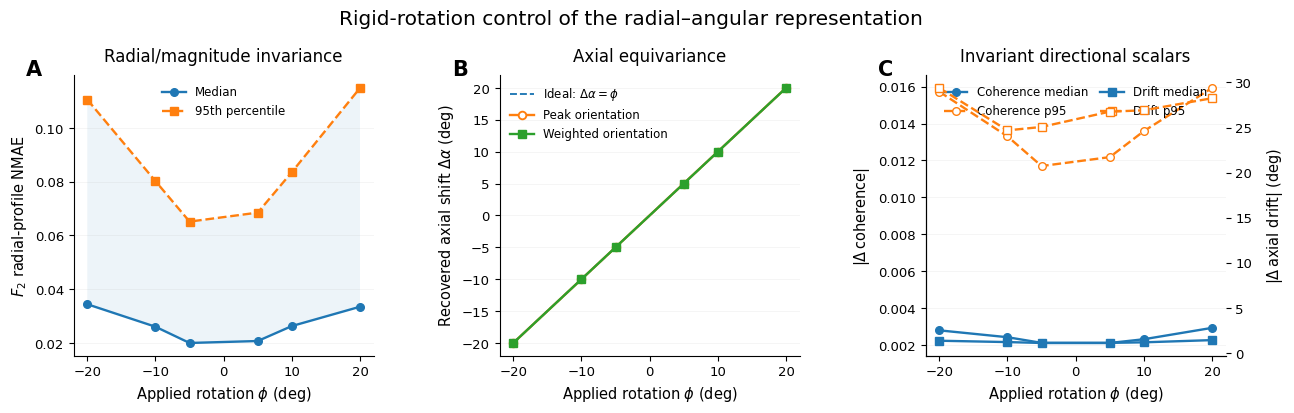


FIGURE 3 WRITTEN

PNG : /content/drive/MyDrive/FashionAI/Radial_Fig/Figure_3_Rigid_Rotation_Control.png
PDF : /content/drive/MyDrive/FashionAI/Radial_Fig/Figure_3_Rigid_Rotation_Control.pdf

SOURCE LOCK
----------------------------------------------------------------------------------------------
Numerical values : repaired rotation-control checkpoint
14-D taxonomy    : later final checkpoint, if present
0°               : reference condition only

NO IMAGE ROTATIONS RERUN
NO DESCRIPTORS RECOMPUTED
NO LABELS READ
NO MODEL FITTED
NO NUMERICAL VALUES INFERRED


In [ ]:
# ==============================================================================================
# CLO-SKET — FIGURE 3
# RIGID-ROTATION INVARIANCE / EQUIVARIANCE CONTROL
#
# NUMERICAL SOURCE LOCK
# ----------------------------------------------------------------------------------------------
# Rotation-control numerical summaries are read from the repaired checkpoint that was
# explicitly audited after the expensive 7 × 2300 image-rotation loop.
#
# The later 14-D-final checkpoint is NOT assumed to duplicate those summary tables.
# No numerical result is recomputed from raw images here.
# ==============================================================================================

from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==============================================================================================
# 1. PATHS
# ==============================================================================================

ROTATION_CHECKPOINT_PATH = Path(
    "/content/drive/MyDrive/FashionAI/"
    "CLO_SKET_ROTATION_CONTROL_CHECKPOINT_REPAIRED.pkl"
)

FINAL_14D_CHECKPOINT_PATH = Path(
    "/content/drive/MyDrive/FashionAI/"
    "CLO_SKET_ROTATION_CONTROL_14D_FINAL.pkl"
)

OUT_DIR = Path("/content/drive/MyDrive/FashionAI/Radial_Fig")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PNG_PATH = OUT_DIR / "Figure_3_Rigid_Rotation_Control.png"
PDF_PATH = OUT_DIR / "Figure_3_Rigid_Rotation_Control.pdf"


print("=" * 94)
print("CLO-SKET — FIGURE 3")
print("RIGID-ROTATION INVARIANCE / EQUIVARIANCE CONTROL")
print("=" * 94)

print("\nNUMERICAL SOURCE")
print("-" * 94)
print(f"Rotation checkpoint : {ROTATION_CHECKPOINT_PATH}")

print("\n14-D TAXONOMY SOURCE")
print("-" * 94)
print(f"Final 14-D checkpoint: {FINAL_14D_CHECKPOINT_PATH}")


# ==============================================================================================
# 2. LOAD REPAIRED ROTATION CHECKPOINT
# ==============================================================================================

if not ROTATION_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Repaired rotation checkpoint not found:\n"
        f"{ROTATION_CHECKPOINT_PATH}"
    )

with open(ROTATION_CHECKPOINT_PATH, "rb") as f:
    rotation_state = pickle.load(f)

if not isinstance(rotation_state, dict):
    raise RuntimeError(
        "Repaired rotation checkpoint is not a dictionary."
    )


# Some saved checkpoints wrap runtime objects under `saved_objects`.
rotation_runtime = {}

if isinstance(rotation_state.get("saved_objects"), dict):
    rotation_runtime.update(rotation_state["saved_objects"])

# Also expose any useful top-level objects.
for key, value in rotation_state.items():
    rotation_runtime.setdefault(key, value)


# ==============================================================================================
# 3. OPTIONAL LOAD OF FINAL 14-D CHECKPOINT
# ==============================================================================================

final14_state = None
final14_runtime = {}

if FINAL_14D_CHECKPOINT_PATH.exists():

    with open(FINAL_14D_CHECKPOINT_PATH, "rb") as f:
        final14_state = pickle.load(f)

    if isinstance(final14_state, dict):

        if isinstance(final14_state.get("saved_objects"), dict):
            final14_runtime.update(final14_state["saved_objects"])

        for key, value in final14_state.items():
            final14_runtime.setdefault(key, value)

        print("\nFinal 14-D checkpoint loaded successfully.")

    else:
        print(
            "\nWARNING: final 14-D checkpoint is not a dictionary; "
            "it will not be used for Figure 3."
        )

else:
    print(
        "\nNOTE: final 14-D checkpoint not found. "
        "Figure 3 can still be rendered from the repaired rotation checkpoint."
    )


# ==============================================================================================
# 4. HARD-RESOLVE THE AUDITED ROTATION TABLES
# ==============================================================================================

rotation_summary = rotation_runtime.get("rotation_control_summary")
axial_summary = rotation_runtime.get("rotation_axial_equivariance")


if not isinstance(rotation_summary, pd.DataFrame):
    raise RuntimeError(
        "Audited object `rotation_control_summary` was not found as a DataFrame "
        "in the repaired rotation checkpoint."
    )

if not isinstance(axial_summary, pd.DataFrame):
    raise RuntimeError(
        "Audited object `rotation_axial_equivariance` was not found as a DataFrame "
        "in the repaired rotation checkpoint."
    )


print("\nFROZEN TABLES")
print("-" * 94)
print(f"rotation_control_summary      : {rotation_summary.shape}")
print(f"rotation_axial_equivariance   : {axial_summary.shape}")


# ==============================================================================================
# 5. REQUIRED COLUMN AUDIT
# ==============================================================================================

required_scalar_columns = [
    "rotation_deg",
    "F2_profile_NMAE_median",
    "F2_profile_NMAE_p95",
    "coherence_abs_change_median",
    "coherence_abs_change_p95",
    "drift_abs_change_median_deg",
    "drift_abs_change_p95_deg",
]

required_axial_columns = [
    "rotation_deg",
    "expected_axial_shift_deg",
    "peak_shift_median_deg",
    "weighted_shift_median_deg",
]


missing_scalar = [
    col
    for col in required_scalar_columns
    if col not in rotation_summary.columns
]

missing_axial = [
    col
    for col in required_axial_columns
    if col not in axial_summary.columns
]


if missing_scalar:
    raise RuntimeError(
        "Missing columns in `rotation_control_summary`:\n    "
        + "\n    ".join(missing_scalar)
    )

if missing_axial:
    raise RuntimeError(
        "Missing columns in `rotation_axial_equivariance`:\n    "
        + "\n    ".join(missing_axial)
    )


# ==============================================================================================
# 6. FREEZE PLOTTING TABLES
# ==============================================================================================

scalar = (
    rotation_summary[required_scalar_columns]
    .copy()
    .sort_values("rotation_deg")
    .reset_index(drop=True)
)

axial = (
    axial_summary[required_axial_columns]
    .copy()
    .sort_values("rotation_deg")
    .reset_index(drop=True)
)


EXPECTED_NONZERO_ANGLES = np.array(
    [-20.0, -10.0, -5.0, 5.0, 10.0, 20.0],
    dtype=float,
)


scalar_angles = scalar["rotation_deg"].to_numpy(dtype=float)
axial_angles = axial["rotation_deg"].to_numpy(dtype=float)


assert np.allclose(
    scalar_angles,
    EXPECTED_NONZERO_ANGLES,
), scalar_angles

assert np.allclose(
    axial_angles,
    EXPECTED_NONZERO_ANGLES,
), axial_angles


print("\nPLOTTING LOCK")
print("-" * 94)
print(f"Angles : {EXPECTED_NONZERO_ANGLES.tolist()}")
print("0° is the reference rotation and is not fabricated as a perturbation point.")


# ==============================================================================================
# 7. PUBLICATION STYLE
# ==============================================================================================

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 10.5,
        "axes.titlesize": 12,
        "axes.labelsize": 10.5,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
        "legend.fontsize": 8.5,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.7,
        "lines.markersize": 5.5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


# ==============================================================================================
# 8. FIGURE
# ==============================================================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12.8, 4.25),
)

axA, axB, axC = axes


fig.suptitle(
    "Rigid-rotation control of the radial–angular representation",
    fontsize=14.5,
    fontweight="medium",
    y=0.985,
)


# ==============================================================================================
# PANEL A — RADIAL / MAGNITUDE INVARIANCE
# ==============================================================================================

x = scalar["rotation_deg"].to_numpy(dtype=float)

f2_median = scalar[
    "F2_profile_NMAE_median"
].to_numpy(dtype=float)

f2_p95 = scalar[
    "F2_profile_NMAE_p95"
].to_numpy(dtype=float)


axA.plot(
    x,
    f2_median,
    marker="o",
    label="Median",
)

axA.plot(
    x,
    f2_p95,
    marker="s",
    linestyle="--",
    label="95th percentile",
)

axA.fill_between(
    x,
    f2_median,
    f2_p95,
    alpha=0.08,
    linewidth=0,
)


axA.set_title(
    "Radial/magnitude invariance",
    pad=10,
)

axA.set_xlabel(
    r"Applied rotation $\phi$ (deg)"
)

axA.set_ylabel(
    r"$F_2$ radial-profile NMAE"
)

axA.set_xticks(
    [-20, -10, 0, 10, 20]
)

axA.legend(
    frameon=False,
    loc="upper center",
)

axA.grid(
    axis="y",
    linewidth=0.5,
    alpha=0.18,
)

axA.spines["top"].set_visible(False)
axA.spines["right"].set_visible(False)


# ==============================================================================================
# PANEL B — AXIAL EQUIVARIANCE
# ==============================================================================================

xb = axial["rotation_deg"].to_numpy(dtype=float)

ideal = axial[
    "expected_axial_shift_deg"
].to_numpy(dtype=float)

peak = axial[
    "peak_shift_median_deg"
].to_numpy(dtype=float)

weighted = axial[
    "weighted_shift_median_deg"
].to_numpy(dtype=float)


axB.plot(
    xb,
    ideal,
    linestyle="--",
    linewidth=1.35,
    label=r"Ideal: $\Delta\alpha=\phi$",
    zorder=1,
)

axB.plot(
    xb,
    peak,
    marker="o",
    markerfacecolor="white",
    markeredgewidth=1.35,
    label="Peak orientation",
    zorder=3,
)

axB.plot(
    xb,
    weighted,
    marker="s",
    label="Weighted orientation",
    zorder=4,
)


axB.set_title(
    "Axial equivariance",
    pad=10,
)

axB.set_xlabel(
    r"Applied rotation $\phi$ (deg)"
)

axB.set_ylabel(
    r"Recovered axial shift $\Delta\alpha$ (deg)"
)

axB.set_xticks(
    [-20, -10, 0, 10, 20]
)

axB.set_yticks(
    [-20, -15, -10, -5, 0, 5, 10, 15, 20]
)

axB.set_xlim(
    -22,
    22,
)

axB.set_ylim(
    -22,
    22,
)

axB.legend(
    frameon=False,
    loc="upper left",
)

axB.grid(
    axis="y",
    linewidth=0.5,
    alpha=0.18,
)

axB.spines["top"].set_visible(False)
axB.spines["right"].set_visible(False)


# ==============================================================================================
# PANEL C — ROTATION-INVARIANT SCALARS
# ==============================================================================================

coh_median = scalar[
    "coherence_abs_change_median"
].to_numpy(dtype=float)

coh_p95 = scalar[
    "coherence_abs_change_p95"
].to_numpy(dtype=float)

drift_median = scalar[
    "drift_abs_change_median_deg"
].to_numpy(dtype=float)

drift_p95 = scalar[
    "drift_abs_change_p95_deg"
].to_numpy(dtype=float)


# Left axis — coherence

line_coh_median, = axC.plot(
    x,
    coh_median,
    marker="o",
    label="Coherence median",
)

line_coh_p95, = axC.plot(
    x,
    coh_p95,
    marker="o",
    linestyle="--",
    markerfacecolor="white",
    label="Coherence p95",
)


axC.set_title(
    "Invariant directional scalars",
    pad=10,
)

axC.set_xlabel(
    r"Applied rotation $\phi$ (deg)"
)

axC.set_ylabel(
    r"$|\Delta\,\mathrm{coherence}|$"
)

axC.set_xticks(
    [-20, -10, 0, 10, 20]
)

axC.grid(
    axis="y",
    linewidth=0.5,
    alpha=0.18,
)

axC.spines["top"].set_visible(False)


# Right axis — axial drift

axC_right = axC.twinx()

line_drift_median, = axC_right.plot(
    x,
    drift_median,
    marker="s",
    label="Drift median",
)

line_drift_p95, = axC_right.plot(
    x,
    drift_p95,
    marker="s",
    linestyle="--",
    markerfacecolor="white",
    label="Drift p95",
)


axC_right.set_ylabel(
    r"$|\Delta\,\mathrm{axial\ drift}|$ (deg)",
    labelpad=9,
)

axC_right.spines["top"].set_visible(False)


# Combined C legend

handles_C = [
    line_coh_median,
    line_coh_p95,
    line_drift_median,
    line_drift_p95,
]

labels_C = [
    h.get_label()
    for h in handles_C
]

axC.legend(
    handles_C,
    labels_C,
    frameon=False,
    loc="upper center",
    ncol=2,
    columnspacing=1.0,
    handlelength=2.0,
)


# ==============================================================================================
# 9. PANEL LABELS
# ==============================================================================================

for label, ax in zip(
    ["A", "B", "C"],
    axes,
):
    ax.text(
        -0.16,
        1.055,
        label,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="top",
        ha="left",
    )


# ==============================================================================================
# 10. LAYOUT
# ==============================================================================================

fig.subplots_adjust(
    left=0.065,
    right=0.965,
    bottom=0.17,
    top=0.83,
    wspace=0.42,
)


# ==============================================================================================
# 11. SAVE
# ==============================================================================================

fig.savefig(
    PNG_PATH,
    dpi=400,
    bbox_inches="tight",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

plt.show()


# ==============================================================================================
# 12. SCIENTIFIC LOCK
# ==============================================================================================

print("\n" + "=" * 94)
print("FIGURE 3 WRITTEN")
print("=" * 94)

print(f"\nPNG : {PNG_PATH}")
print(f"PDF : {PDF_PATH}")

print("\nSOURCE LOCK")
print("-" * 94)
print("Numerical values : repaired rotation-control checkpoint")
print("14-D taxonomy    : later final checkpoint, if present")
print("0°               : reference condition only")

print("\nNO IMAGE ROTATIONS RERUN")
print("NO DESCRIPTORS RECOMPUTED")
print("NO LABELS READ")
print("NO MODEL FITTED")
print("NO NUMERICAL VALUES INFERRED")
print("=" * 94)

In [ ]:
# ==========================================================================================
# CLO-SKET — FIGURE 3
# RIGID-ROTATION INVARIANCE / EQUIVARIANCE CONTROL
#
# IMPORTANT PROVENANCE DESIGN
# ------------------------------------------------------------------------------------------
# RAW / EXPENSIVE-LOOP DATA:
#     CLO_SKET_ROTATION_CONTROL_CHECKPOINT_REPAIRED.pkl
#
# FINAL SCIENTIFIC TAXONOMY / CLAIM LOCK:
#     CLO_SKET_ROTATION_CONTROL_14D_FINAL.pkl
#
# No rotation experiment is rerun.
# ==========================================================================================

from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


# ==========================================================================================
# 0. PATHS
# ==========================================================================================

RAW_CHECKPOINT_PATH = Path(
    "/content/drive/MyDrive/FashionAI/"
    "CLO_SKET_ROTATION_CONTROL_CHECKPOINT_REPAIRED.pkl"
)

FINAL_CHECKPOINT_PATH = Path(
    "/content/drive/MyDrive/FashionAI/"
    "CLO_SKET_ROTATION_CONTROL_14D_FINAL.pkl"
)

OUT_DIR = Path(
    "/content/drive/MyDrive/FashionAI/Radial_Fig"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "Figure_3_Rigid_Rotation_Control.png"
OUT_PDF = OUT_DIR / "Figure_3_Rigid_Rotation_Control.pdf"

DISPLAY_ANGLES = (-20.0, 0.0, 20.0)

REPRESENTATIVE_INDEX = None

FIGSIZE = (15.8, 8.7)
DPI = 220


print("=" * 94)
print("CLO-SKET — FIGURE 3")
print("RIGID-ROTATION INVARIANCE / EQUIVARIANCE CONTROL")
print("=" * 94)

print("\nPROVENANCE")
print("-" * 94)
print("Raw repaired checkpoint :", RAW_CHECKPOINT_PATH)
print("Final 14-D lock         :", FINAL_CHECKPOINT_PATH)


# ==========================================================================================
# 1. GENERIC CHECKPOINT LOADER
# ==========================================================================================

def load_checkpoint_dict(path):
    """
    Load a pickle checkpoint and expose its scientific/runtime object dictionary.

    Supported structures
    --------------------
    1. direct dictionary of runtime objects
    2. wrapper with:
           checkpoint["saved_objects"] = {...}
    """

    if not path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found:\n{path}"
        )

    with open(path, "rb") as f:
        obj = pickle.load(f)

    if not isinstance(obj, dict):
        raise RuntimeError(
            f"Checkpoint is not dictionary-like:\n{path}"
        )

    if (
        "saved_objects" in obj
        and isinstance(obj["saved_objects"], dict)
    ):
        state = obj["saved_objects"]
    else:
        state = obj

    return obj, state


raw_wrapper, raw_state = load_checkpoint_dict(
    RAW_CHECKPOINT_PATH
)

final_wrapper, final_state = load_checkpoint_dict(
    FINAL_CHECKPOINT_PATH
)


print("\nCHECKPOINT CONTENT")
print("-" * 94)
print(f"Raw runtime objects : {len(raw_state)}")
print(f"Final lock objects  : {len(final_state)}")


# ==========================================================================================
# 2. RAW TENSOR REQUIREMENTS
#
# These objects belong to the repaired expensive-loop checkpoint.
# ==========================================================================================

raw_required = [
    "rotation_F2",
    "rotation_X14",
    "rotation_alpha_peak",
    "rotation_alpha_weighted",
    "rotation_coherence",
    "rotation_drift",
    "ROTATION_ANGLES_DEG",
    "primary_indices_rot",
    "image_paths",
]

raw_missing = [
    name
    for name in raw_required
    if name not in raw_state
]

if raw_missing:
    raise RuntimeError(
        "The repaired rotation checkpoint is missing required raw objects:\n"
        + "\n".join(
            f"    - {name}"
            for name in raw_missing
        )
    )


# ==========================================================================================
# 3. LOAD CANONICAL RAW OBJECTS
# ==========================================================================================

rotation_F2 = np.asarray(
    raw_state["rotation_F2"],
    dtype=float
)

rotation_X14 = np.asarray(
    raw_state["rotation_X14"],
    dtype=float
)

rotation_alpha_peak = np.asarray(
    raw_state["rotation_alpha_peak"],
    dtype=float
)

rotation_alpha_weighted = np.asarray(
    raw_state["rotation_alpha_weighted"],
    dtype=float
)

rotation_coherence = np.asarray(
    raw_state["rotation_coherence"],
    dtype=float
)

rotation_drift = np.asarray(
    raw_state["rotation_drift"],
    dtype=float
)

rotation_angles = np.asarray(
    raw_state["ROTATION_ANGLES_DEG"],
    dtype=float
)

primary_indices = np.asarray(
    raw_state["primary_indices_rot"],
    dtype=int
)

image_paths = np.asarray(
    raw_state["image_paths"]
)


# ==========================================================================================
# 4. HARD CANONICAL SHAPE AUDIT
# ==========================================================================================

if rotation_F2.ndim != 3:
    raise RuntimeError(
        "rotation_F2 must have shape "
        "(rotation, sketch, radial). "
        f"Observed: {rotation_F2.shape}"
    )

n_rot, n_sketch, n_radial = rotation_F2.shape

assert rotation_X14.shape == (
    n_rot,
    n_sketch,
    14,
), rotation_X14.shape

assert rotation_alpha_peak.shape == (
    n_rot,
    n_sketch,
), rotation_alpha_peak.shape

assert rotation_alpha_weighted.shape == (
    n_rot,
    n_sketch,
), rotation_alpha_weighted.shape

assert rotation_coherence.shape == (
    n_rot,
    n_sketch,
), rotation_coherence.shape

assert rotation_drift.shape == (
    n_rot,
    n_sketch,
), rotation_drift.shape

assert rotation_angles.shape == (
    n_rot,
), rotation_angles.shape

assert image_paths.shape == (
    n_sketch,
), image_paths.shape


if not np.any(
    np.isclose(
        rotation_angles,
        0.0
    )
):
    raise RuntimeError(
        "0° reference rotation missing."
    )

ref_idx = int(
    np.flatnonzero(
        np.isclose(
            rotation_angles,
            0.0
        )
    )[0]
)

nonzero_mask = ~np.isclose(
    rotation_angles,
    0.0
)


print("\nCANONICAL RAW ROTATION OBJECTS")
print("-" * 94)
print("rotation_F2             :", rotation_F2.shape)
print("rotation_X14            :", rotation_X14.shape)
print("rotation_alpha_peak     :", rotation_alpha_peak.shape)
print("rotation_alpha_weighted :", rotation_alpha_weighted.shape)
print("rotation_coherence      :", rotation_coherence.shape)
print("rotation_drift          :", rotation_drift.shape)
print("primary_indices         :", primary_indices.shape)
print("image_paths             :", image_paths.shape)

print("\nEXPERIMENT")
print("-" * 94)
print("Sketches :", n_sketch)
print("Angles   :", rotation_angles.tolist())
print("Radial   :", n_radial)
print("Primary  :", primary_indices.size)
print("Reference:", f"{rotation_angles[ref_idx]:+.1f}°")


# ==========================================================================================
# 5. FINAL 14-D SCIENTIFIC LOCK AUDIT
#
# The final checkpoint need NOT contain the expensive-loop tensors.
# We inspect it only for provenance / taxonomy objects.
# ==========================================================================================

print("\nFINAL 14-D LOCK")
print("-" * 94)

interesting_final_keys = [
    key
    for key in final_state.keys()
    if any(
        token in key.lower()
        for token in [
            "taxonomy",
            "claim",
            "rotation",
            "14d",
            "feature",
            "summary",
            "interpret",
        ]
    )
]

if interesting_final_keys:

    for key in sorted(interesting_final_keys):
        value = final_state[key]

        if isinstance(value, np.ndarray):
            desc = f"ndarray {value.shape}"

        elif isinstance(value, pd.DataFrame):
            desc = f"DataFrame {value.shape}"

        else:
            desc = type(value).__name__

        print(f"{key:<48} {desc}")

else:

    print(
        "No named taxonomy/claim object detected; "
        "checkpoint existence itself is retained as the final lock."
    )


# ==========================================================================================
# 6. PROVENANCE FREEZE
# ==========================================================================================

print("\nFIGURE 3 DATA POLICY")
print("-" * 94)

print(
    "Quantitative panels : repaired expensive-loop checkpoint"
)

print(
    "14-D interpretation : final scientific lock checkpoint"
)

print(
    "Images              : canonical image_paths from repaired checkpoint"
)

print(
    "Rotation rerun      : NO"
)

print(
    "Labels read         : NO"
)

print(
    "Model fitted        : NO"
)

print("=" * 94)

CLO-SKET — FIGURE 3
RIGID-ROTATION INVARIANCE / EQUIVARIANCE CONTROL

PROVENANCE
----------------------------------------------------------------------------------------------
Raw repaired checkpoint : /content/drive/MyDrive/FashionAI/CLO_SKET_ROTATION_CONTROL_CHECKPOINT_REPAIRED.pkl
Final 14-D lock         : /content/drive/MyDrive/FashionAI/CLO_SKET_ROTATION_CONTROL_14D_FINAL.pkl

CHECKPOINT CONTENT
----------------------------------------------------------------------------------------------
Raw runtime objects : 90
Final lock objects  : 18

CANONICAL RAW ROTATION OBJECTS
----------------------------------------------------------------------------------------------
rotation_F2             : (7, 2300, 72)
rotation_X14            : (7, 2300, 14)
rotation_alpha_peak     : (7, 2300)
rotation_alpha_weighted : (7, 2300)
rotation_coherence      : (7, 2300)
rotation_drift          : (7, 2300)
primary_indices         : (25,)
image_paths             : (2300,)

EXPERIMENT
----------------------

CLO-SKET — FIGURE 3
RIGID-ROTATION INVARIANCE / EQUIVARIANCE CONTROL

PROVENANCE
----------------------------------------------------------------------------------------------
Raw repaired checkpoint : /content/drive/MyDrive/FashionAI/CLO_SKET_ROTATION_CONTROL_CHECKPOINT_REPAIRED.pkl
Final 14-D lock         : /content/drive/MyDrive/FashionAI/CLO_SKET_ROTATION_CONTROL_14D_FINAL.pkl
Raw runtime objects     : 90
Final lock objects      : 18

EXPERIMENT
----------------------------------------------------------------------------------------------
Sketches     : 2300
Angles       : [-20.0, -10.0, -5.0, 0.0, 5.0, 10.0, 20.0]
Radial bins  : 72
Primary bins : 25
Reference    : +0.0°

NUMERICAL RECOVERY
----------------------------------------------------------------------------------------------
Reconstructed Figure-3 metrics reproduce the saved checkpoint summary.
Maximum shared-column absolute difference : 7.105e-15

FINAL 14-D INTERPRETATION
-------------------------------------------------

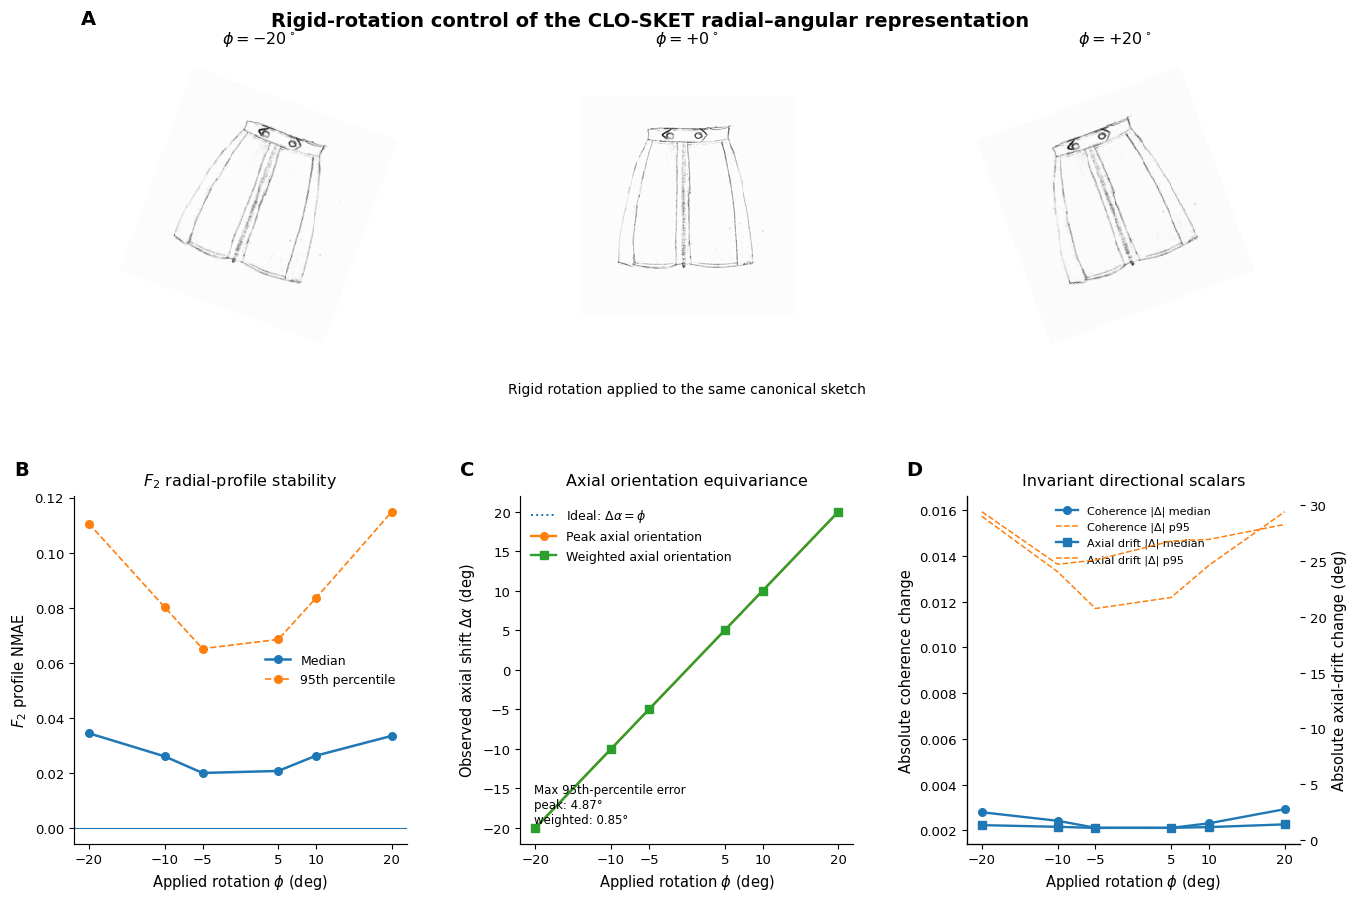


FIGURE 3 COMPLETE

PANEL A
----------------------------------------------------------------------------------------------
Canonical sketch index : 0
Canonical image        : /content/drive/MyDrive/FashionAI/datasets/Clo-Sket/Clo-Sket/A-Line/1-1.tif
Rotation operator      : figure3_rotation_image [exact image-side process_rotation_condition operator]
Displayed rotations    : [-20.0, 0.0, 20.0]

PANEL B
----------------------------------------------------------------------------------------------
F2 radial-profile invariance reconstructed directly from frozen rotation_F2.

PANEL C
----------------------------------------------------------------------------------------------
Axial equivariance reconstructed directly from rotation_alpha_peak and rotation_alpha_weighted.

PANEL D
----------------------------------------------------------------------------------------------
Coherence and axial drift shown as separately scaled invariant directional quantities.

SCIENTIFIC LOCK
--------------

In [ ]:
# =============================================================================
# CLO-SKET — FIGURE 3
# RIGID-ROTATION INVARIANCE / EQUIVARIANCE CONTROL
#
# PANEL A : actual rigid-rotation intervention (-20°, 0°, +20°)
# PANEL B : F2 radial-profile invariance
# PANEL C : axial orientation equivariance
# PANEL D : invariant directional-scalar stability
#
# IMPORTANT
# -----------------------------------------------------------------------------
# - Uses the already-completed repaired rotation-control checkpoint.
# - Uses the frozen 14-D scientific interpretation lock.
# - Does NOT rerun the 7 × 2300 rotation experiment.
# - Does NOT read labels.
# - Does NOT fit a model.
# - Panel A attempts to recover the exact single-image rotation operator already
#   defined in the live notebook runtime. It will NOT silently substitute a
#   decorative / approximate rotation.
# =============================================================================

from pathlib import Path
import pickle
import inspect
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image


# =============================================================================
# 0. PATHS
# =============================================================================

ROOT = Path("/content/drive/MyDrive/FashionAI")

RAW_CKPT_PATH = (
    ROOT / "CLO_SKET_ROTATION_CONTROL_CHECKPOINT_REPAIRED.pkl"
)

FINAL_LOCK_PATH = (
    ROOT / "CLO_SKET_ROTATION_CONTROL_14D_FINAL.pkl"
)

FIG_DIR = ROOT / "Radial_Fig"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PNG_PATH = FIG_DIR / "Figure_3_Rotation_Control.png"
PDF_PATH = FIG_DIR / "Figure_3_Rotation_Control.pdf"


print("=" * 94)
print("CLO-SKET — FIGURE 3")
print("RIGID-ROTATION INVARIANCE / EQUIVARIANCE CONTROL")
print("=" * 94)


# =============================================================================
# 1. LOAD BOTH FROZEN SOURCES
# =============================================================================

with open(RAW_CKPT_PATH, "rb") as f:
    raw_state = pickle.load(f)

with open(FINAL_LOCK_PATH, "rb") as f:
    final_lock = pickle.load(f)


# repaired checkpoint may itself contain wrapper metadata
if (
    isinstance(raw_state, dict)
    and "saved_objects" in raw_state
    and isinstance(raw_state["saved_objects"], dict)
):
    raw = raw_state["saved_objects"]
else:
    raw = raw_state


print("\nPROVENANCE")
print("-" * 94)
print(f"Raw repaired checkpoint : {RAW_CKPT_PATH}")
print(f"Final 14-D lock         : {FINAL_LOCK_PATH}")
print(f"Raw runtime objects     : {len(raw)}")
print(f"Final lock objects      : {len(final_lock)}")


# =============================================================================
# 2. STRICTLY RECOVER REQUIRED RAW OBJECTS
# =============================================================================

required_raw = [
    "rotation_F2",
    "rotation_X14",
    "rotation_alpha_peak",
    "rotation_alpha_weighted",
    "rotation_coherence",
    "rotation_drift",
    "ROTATION_ANGLES_DEG",
    "primary_indices_rot",
    "image_paths",
]

missing = [name for name in required_raw if name not in raw]

if missing:
    raise RuntimeError(
        "Missing required raw rotation-control objects:\n"
        + "\n".join(f"    - {name}" for name in missing)
    )


rotation_F2 = np.asarray(raw["rotation_F2"], dtype=float)
rotation_X14 = np.asarray(raw["rotation_X14"], dtype=float)

rotation_alpha_peak = np.asarray(
    raw["rotation_alpha_peak"], dtype=float
)

rotation_alpha_weighted = np.asarray(
    raw["rotation_alpha_weighted"], dtype=float
)

rotation_coherence = np.asarray(
    raw["rotation_coherence"], dtype=float
)

rotation_drift = np.asarray(
    raw["rotation_drift"], dtype=float
)

ROTATION_ANGLES_DEG = np.asarray(
    raw["ROTATION_ANGLES_DEG"], dtype=float
)

primary_indices = np.asarray(
    raw["primary_indices_rot"], dtype=int
)

image_paths = np.asarray(raw["image_paths"])


# =============================================================================
# 3. HARD SHAPE LOCK
# =============================================================================

N_ROT, N_SKETCH, N_RADIAL = rotation_F2.shape

assert N_ROT == len(ROTATION_ANGLES_DEG)
assert rotation_X14.shape == (N_ROT, N_SKETCH, 14)
assert rotation_alpha_peak.shape == (N_ROT, N_SKETCH)
assert rotation_alpha_weighted.shape == (N_ROT, N_SKETCH)
assert rotation_coherence.shape == (N_ROT, N_SKETCH)
assert rotation_drift.shape == (N_ROT, N_SKETCH)
assert image_paths.shape == (N_SKETCH,)
assert primary_indices.ndim == 1

N_PRIMARY = len(primary_indices)

ref_candidates = np.where(
    np.isclose(ROTATION_ANGLES_DEG, 0.0)
)[0]

if len(ref_candidates) != 1:
    raise RuntimeError(
        "Expected exactly one 0° reference rotation."
    )

REF_IDX = int(ref_candidates[0])


print("\nEXPERIMENT")
print("-" * 94)
print(f"Sketches     : {N_SKETCH}")
print(f"Angles       : {ROTATION_ANGLES_DEG.tolist()}")
print(f"Radial bins  : {N_RADIAL}")
print(f"Primary bins : {N_PRIMARY}")
print(f"Reference    : {ROTATION_ANGLES_DEG[REF_IDX]:+.1f}°")


# =============================================================================
# 4. MATHEMATICAL HELPERS
# =============================================================================

def axial_signed_difference_deg(a_deg, b_deg):
    """
    Signed axial difference a - b, wrapped to [-90°, +90°).

    Axial orientation has period 180°.
    """
    return (
        (np.asarray(a_deg) - np.asarray(b_deg) + 90.0)
        % 180.0
    ) - 90.0


def finite_median(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanmedian(x))


def finite_p95(x):
    x = np.asarray(x, dtype=float)
    return float(np.nanpercentile(x, 95))


# =============================================================================
# 5. RECONSTRUCT PRIMARY F2 PROFILES
# =============================================================================

rotation_primary = rotation_F2[:, :, primary_indices]

assert rotation_primary.shape == (
    N_ROT,
    N_SKETCH,
    N_PRIMARY,
)

ref_primary = rotation_primary[REF_IDX]

profile_scale = np.mean(
    np.abs(ref_primary),
    axis=1
)

eps_profile = np.finfo(float).eps

profile_scale_safe = np.maximum(
    profile_scale,
    eps_profile
)


# =============================================================================
# 6. RECONSTRUCT FIGURE-LEVEL NUMERICAL SUMMARY
# =============================================================================

records = []

ref_peak = rotation_alpha_peak[REF_IDX]
ref_weighted = rotation_alpha_weighted[REF_IDX]

ref_coherence = rotation_coherence[REF_IDX]
ref_drift = rotation_drift[REF_IDX]


for i, phi in enumerate(ROTATION_ANGLES_DEG):

    if i == REF_IDX:
        continue

    # -------------------------------------------------------------------------
    # F2 radial-profile normalized absolute error
    # -------------------------------------------------------------------------
    profile_nmae = (
        np.mean(
            np.abs(
                rotation_primary[i] - ref_primary
            ),
            axis=1,
        )
        / profile_scale_safe
    )

    # -------------------------------------------------------------------------
    # Scalar invariants
    # -------------------------------------------------------------------------
    coherence_change = np.abs(
        rotation_coherence[i] - ref_coherence
    )

    drift_change = np.abs(
        axial_signed_difference_deg(
            rotation_drift[i],
            ref_drift,
        )
    )

    # -------------------------------------------------------------------------
    # Axial equivariance
    #
    # Experiment established:
    # alpha_rot - alpha_ref ≈ +phi
    # -------------------------------------------------------------------------
    peak_shift = axial_signed_difference_deg(
        rotation_alpha_peak[i],
        ref_peak,
    )

    weighted_shift = axial_signed_difference_deg(
        rotation_alpha_weighted[i],
        ref_weighted,
    )

    peak_equivariance_error = np.abs(
        axial_signed_difference_deg(
            peak_shift,
            phi,
        )
    )

    weighted_equivariance_error = np.abs(
        axial_signed_difference_deg(
            weighted_shift,
            phi,
        )
    )

    records.append(
        {
            "rotation_deg":
                float(phi),

            "F2_profile_NMAE_median":
                finite_median(profile_nmae),

            "F2_profile_NMAE_p95":
                finite_p95(profile_nmae),

            "coherence_abs_change_median":
                finite_median(coherence_change),

            "coherence_abs_change_p95":
                finite_p95(coherence_change),

            "drift_abs_change_median_deg":
                finite_median(drift_change),

            "drift_abs_change_p95_deg":
                finite_p95(drift_change),

            "peak_shift_median_deg":
                finite_median(peak_shift),

            "peak_equivariance_error_median_deg":
                finite_median(
                    peak_equivariance_error
                ),

            "peak_equivariance_error_p95_deg":
                finite_p95(
                    peak_equivariance_error
                ),

            "weighted_shift_median_deg":
                finite_median(weighted_shift),

            "weighted_equivariance_error_median_deg":
                finite_median(
                    weighted_equivariance_error
                ),

            "weighted_equivariance_error_p95_deg":
                finite_p95(
                    weighted_equivariance_error
                ),
        }
    )


fig_summary = (
    pd.DataFrame(records)
    .sort_values("rotation_deg")
    .reset_index(drop=True)
)


# =============================================================================
# 7. EXACT NUMERICAL CROSS-CHECK AGAINST SAVED REPAIRED SUMMARY
# =============================================================================

saved_summary = raw.get(
    "rotation_control_summary",
    None,
)

if isinstance(saved_summary, pd.DataFrame):

    shared_cols = [
        col
        for col in fig_summary.columns
        if col in saved_summary.columns
    ]

    saved_cmp = (
        saved_summary[shared_cols]
        .copy()
        .sort_values("rotation_deg")
        .reset_index(drop=True)
    )

    fig_cmp = (
        fig_summary[shared_cols]
        .copy()
        .sort_values("rotation_deg")
        .reset_index(drop=True)
    )

    numeric_cols = [
        c
        for c in shared_cols
        if c != "rotation_deg"
    ]

    max_diff = 0.0

    for col in numeric_cols:
        diff = np.nanmax(
            np.abs(
                np.asarray(fig_cmp[col], dtype=float)
                -
                np.asarray(saved_cmp[col], dtype=float)
            )
        )
        max_diff = max(max_diff, float(diff))

    if max_diff > 1e-10:
        raise RuntimeError(
            "Reconstructed Figure-3 summary does not reproduce "
            "the saved repaired checkpoint summary.\n"
            f"Maximum absolute difference = {max_diff:.12g}"
        )

    print("\nNUMERICAL RECOVERY")
    print("-" * 94)
    print(
        "Reconstructed Figure-3 metrics reproduce the "
        "saved checkpoint summary."
    )
    print(
        f"Maximum shared-column absolute difference : "
        f"{max_diff:.3e}"
    )

else:
    print("\nNUMERICAL RECOVERY")
    print("-" * 94)
    print(
        "No saved scalar summary table found; values were "
        "reconstructed directly from frozen tensors."
    )


# =============================================================================
# 8. FINAL 14-D INTERPRETATION LOCK
# =============================================================================

taxonomy = final_lock.get(
    "rotation_14d_taxonomy",
    None,
)

final_claim = final_lock.get(
    "final_rotation_control_claim",
    None,
)

if not isinstance(taxonomy, pd.DataFrame):
    raise RuntimeError(
        "Frozen rotation_14d_taxonomy is missing."
    )

if not isinstance(final_claim, str):
    raise RuntimeError(
        "Frozen final_rotation_control_claim is missing."
    )


print("\nFINAL 14-D INTERPRETATION")
print("-" * 94)
print(f"Taxonomy : {taxonomy.shape}")
print(f"Claim    : {final_claim}")


# =============================================================================
# FIGURE 3 — PANEL A
# EXACT RIGID-ROTATION INTERVENTION VISUALIZATION
#
# SCIENTIFIC POLICY
# -----------------------------------------------------------------------------
# - Uses the exact image-side operator from process_rotation_condition().
# - Uses the same rotation_safe_canvas().
# - Uses the same PIL bilinear interpolation.
# - Uses expand=False and fillcolor=255.
# - Does NOT rerun the 7 × 2300 rotation control.
# - Does NOT recompute any quantitative Figure-3 result.
# - Only three illustrative conditions are rendered:
#       -20°, 0°, +20°
# =============================================================================

from PIL import Image
import numpy as np


# -----------------------------------------------------------------------------
# Exact image-side implementation recovered from the experimental operator
# -----------------------------------------------------------------------------
def figure3_rotation_image(
    path,
    angle_deg,
):
    """
    Return the exact grayscale image presented to the radial-angular
    reconstruction in the original rotation-control experiment.

    This reproduces only the image-side intervention from
    process_rotation_condition(path, angle_deg).

    No descriptors or quantitative control metrics are recomputed here.
    """

    # -------------------------------------------------------------------------
    # Load raw sketch exactly as in process_rotation_condition()
    # -------------------------------------------------------------------------
    with Image.open(path) as im:

        im.load()

        raw = np.asarray(
            im.convert("L"),
            dtype=np.uint8,
        )

    # -------------------------------------------------------------------------
    # Exact rotation-safe baseline canvas
    # -------------------------------------------------------------------------
    safe = rotation_safe_canvas(
        raw
    )

    pil_safe = Image.fromarray(
        safe,
    )

    # -------------------------------------------------------------------------
    # Exact rigid-rotation operator
    # -------------------------------------------------------------------------
    if float(angle_deg) == 0.0:

        rotated = pil_safe

    else:

        rotated = pil_safe.rotate(
            float(angle_deg),

            # Exact interpolation used in the experiment
            resample=Image.Resampling.BILINEAR,

            # Exact fixed rotation-safe canvas
            expand=False,

            # Exact white-background convention
            fillcolor=255,
        )

    return np.asarray(
        rotated,
        dtype=np.uint8,
    )


# -----------------------------------------------------------------------------
# Select one fixed sketch for intervention illustration
# -----------------------------------------------------------------------------
# IMPORTANT:
# This is an illustrative example only.
# It is not selected using labels, performance, or rotation-control outcomes.
# -----------------------------------------------------------------------------

FIG3_EXAMPLE_INDEX = 0

if not (
    0
    <=
    FIG3_EXAMPLE_INDEX
    <
    len(image_paths)
):
    raise IndexError(
        f"FIG3_EXAMPLE_INDEX={FIG3_EXAMPLE_INDEX} outside "
        f"available range 0..{len(image_paths)-1}"
    )

fig3_example_path = str(
    image_paths[
        FIG3_EXAMPLE_INDEX
    ]
)


# -----------------------------------------------------------------------------
# Three intervention conditions
# -----------------------------------------------------------------------------

FIG3_DISPLAY_ANGLES = np.asarray(
    [
        -20.0,
          0.0,
         20.0,
    ],
    dtype=float,
)


fig3_rotation_images = {
    float(phi):
        figure3_rotation_image(
            fig3_example_path,
            float(phi),
        )

    for phi in FIG3_DISPLAY_ANGLES
}


# -----------------------------------------------------------------------------
# Hard sanity checks
# -----------------------------------------------------------------------------

_fig3_shapes = {
    arr.shape
    for arr in fig3_rotation_images.values()
}

assert len(_fig3_shapes) == 1, (
    "Panel-A rotated images do not share a common canvas shape."
)

assert all(
    arr.ndim == 2
    for arr in fig3_rotation_images.values()
)

assert all(
    arr.dtype == np.uint8
    for arr in fig3_rotation_images.values()
)


# -----------------------------------------------------------------------------
# Provenance report
# -----------------------------------------------------------------------------

print(
    "\nPANEL A — EXACT EXPERIMENTAL ROTATION OPERATOR"
)

print(
    "-" * 94
)

print(
    f"Example index : {FIG3_EXAMPLE_INDEX}"
)

print(
    f"Image path    : {fig3_example_path}"
)

print(
    "Angles        : "
    +
    str(
        FIG3_DISPLAY_ANGLES.tolist()
    )
)

print(
    "Canvas shape  : "
    +
    str(
        next(
            iter(
                _fig3_shapes
            )
        )
    )
)

print(
    "Operator      : rotation_safe_canvas → "
    "PIL.Image.rotate"
)

print(
    "Interpolation : Image.Resampling.BILINEAR"
)

print(
    "expand        : False"
)

print(
    "fillcolor     : 255"
)

print(
    "Quantitative reconstruction : NO"
)

print(
    "7 × 2300 control rerun      : NO"
)


# =============================================================================
# 10. FREEZE PANEL-A DISPLAY IMAGES
# =============================================================================
#
# The exact experimental image-side rotation operator was already reconstructed
# above in figure3_rotation_image().
#
# Therefore:
# - no runtime operator discovery is required;
# - no candidate testing is required;
# - no fallback / approximate rotation is permitted;
# - only the three illustrative display rotations are evaluated.
# =============================================================================

DISPLAY_ANGLES = FIG3_DISPLAY_ANGLES.copy()

panel_A_images = [
    fig3_rotation_images[
        float(phi)
    ]
    for phi in DISPLAY_ANGLES
]

EXAMPLE_IDX = FIG3_EXAMPLE_INDEX
example_path = fig3_example_path

chosen_rotation_name = (
    "figure3_rotation_image "
    "[exact image-side process_rotation_condition operator]"
)


# -----------------------------------------------------------------------------
# Hard display lock
# -----------------------------------------------------------------------------

assert len(panel_A_images) == 3

assert np.allclose(
    DISPLAY_ANGLES,
    np.asarray(
        [-20.0, 0.0, 20.0],
        dtype=float,
    ),
)

assert all(
    np.asarray(img).shape
    ==
    panel_A_images[0].shape
    for img in panel_A_images
)

assert all(
    np.asarray(img).dtype
    ==
    np.uint8
    for img in panel_A_images
)


print(
    "\nPANEL A — DISPLAY LOCK"
)

print(
    "-" * 94
)

print(
    f"Canonical sketch index : {EXAMPLE_IDX}"
)

print(
    f"Canonical image        : {example_path}"
)

print(
    f"Rotation operator      : {chosen_rotation_name}"
)

print(
    "Displayed rotations    : "
    f"{DISPLAY_ANGLES.tolist()}"
)

print(
    "Runtime operator search: NO"
)

print(
    "Approximate fallback   : NO"
)

print(
    "Quantitative rerun     : NO"
)


# =============================================================================
# 13. PLOTTING ARRAYS
# =============================================================================

plot_angles = np.asarray(
    fig_summary["rotation_deg"],
    dtype=float,
)

f2_med = np.asarray(
    fig_summary[
        "F2_profile_NMAE_median"
    ],
    dtype=float,
)

f2_p95 = np.asarray(
    fig_summary[
        "F2_profile_NMAE_p95"
    ],
    dtype=float,
)

peak_shift_med = np.asarray(
    fig_summary[
        "peak_shift_median_deg"
    ],
    dtype=float,
)

weighted_shift_med = np.asarray(
    fig_summary[
        "weighted_shift_median_deg"
    ],
    dtype=float,
)

peak_err_p95 = np.asarray(
    fig_summary[
        "peak_equivariance_error_p95_deg"
    ],
    dtype=float,
)

weighted_err_p95 = np.asarray(
    fig_summary[
        "weighted_equivariance_error_p95_deg"
    ],
    dtype=float,
)

coh_med = np.asarray(
    fig_summary[
        "coherence_abs_change_median"
    ],
    dtype=float,
)

coh_p95 = np.asarray(
    fig_summary[
        "coherence_abs_change_p95"
    ],
    dtype=float,
)

drift_med = np.asarray(
    fig_summary[
        "drift_abs_change_median_deg"
    ],
    dtype=float,
)

drift_p95 = np.asarray(
    fig_summary[
        "drift_abs_change_p95_deg"
    ],
    dtype=float,
)


# =============================================================================
# 14. FIGURE STYLE
# =============================================================================

plt.rcParams.update(
    {
        "font.size": 10.5,
        "axes.titlesize": 11.5,
        "axes.labelsize": 10.5,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
        "legend.fontsize": 9,
        "axes.linewidth": 0.85,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


fig = plt.figure(
    figsize=(13.4, 9.2),
    constrained_layout=False,
)

outer = fig.add_gridspec(
    nrows=2,
    ncols=3,
    height_ratios=[0.88, 1.0],
    left=0.07,
    right=0.985,
    bottom=0.08,
    top=0.94,
    wspace=0.34,
    hspace=0.42,
)


# =============================================================================
# PANEL A — ACTUAL INTERVENTION
# =============================================================================

gs_A = outer[0, :].subgridspec(
    1,
    3,
    wspace=0.16,
)

axes_A = [
    fig.add_subplot(
        gs_A[0, j]
    )
    for j in range(3)
]


for ax, img, phi in zip(
    axes_A,
    panel_A_images,
    DISPLAY_ANGLES,
):

    if img.ndim == 2:
        ax.imshow(
            img,
            cmap="gray",
            interpolation="nearest",
        )
    else:
        ax.imshow(
            img,
            interpolation="nearest",
        )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(
        rf"$\phi={phi:+.0f}^\circ$",
        pad=7,
        fontweight="semibold",
    )


axes_A[0].text(
    -0.08,
    1.08,
    "A",
    transform=axes_A[0].transAxes,
    fontsize=14,
    fontweight="bold",
    va="bottom",
)

axes_A[1].text(
    0.5,
    -0.075,
    "Rigid rotation applied to the same canonical sketch",
    transform=axes_A[1].transAxes,
    ha="center",
    va="top",
    fontsize=10,
)


# =============================================================================
# PANEL B — F2 RADIAL-PROFILE INVARIANCE
# =============================================================================

axB = fig.add_subplot(
    outer[1, 0]
)

axB.plot(
    plot_angles,
    f2_med,
    marker="o",
    linewidth=1.8,
    label="Median",
)

axB.plot(
    plot_angles,
    f2_p95,
    marker="o",
    linewidth=1.2,
    linestyle="--",
    label="95th percentile",
)

axB.axhline(
    0.0,
    linewidth=0.8,
)

axB.set_xlabel(
    r"Applied rotation $\phi$ (deg)"
)

axB.set_ylabel(
    r"$F_2$ profile NMAE"
)

axB.set_title(
    r"$F_2$ radial-profile stability",
    pad=8,
)

axB.legend(
    frameon=False,
)

axB.text(
    -0.18,
    1.06,
    "B",
    transform=axB.transAxes,
    fontsize=14,
    fontweight="bold",
)


# =============================================================================
# PANEL C — AXIAL EQUIVARIANCE
# =============================================================================

axC = fig.add_subplot(
    outer[1, 1]
)

# ideal y = phi
full_range = np.array(
    [
        np.min(plot_angles),
        np.max(plot_angles),
    ]
)

axC.plot(
    full_range,
    full_range,
    linestyle=":",
    linewidth=1.4,
    label=r"Ideal: $\Delta\alpha=\phi$",
)

axC.plot(
    plot_angles,
    peak_shift_med,
    marker="o",
    linewidth=1.7,
    label="Peak axial orientation",
)

axC.plot(
    plot_angles,
    weighted_shift_med,
    marker="s",
    linewidth=1.7,
    label="Weighted axial orientation",
)

axC.set_xlabel(
    r"Applied rotation $\phi$ (deg)"
)

axC.set_ylabel(
    r"Observed axial shift $\Delta\alpha$ (deg)"
)

axC.set_title(
    "Axial orientation equivariance",
    pad=8,
)

axC.legend(
    frameon=False,
    loc="upper left",
)

axC.text(
    -0.18,
    1.06,
    "C",
    transform=axC.transAxes,
    fontsize=14,
    fontweight="bold",
)


# small p95 error annotation
peak_max_p95 = np.max(
    peak_err_p95
)

weighted_max_p95 = np.max(
    weighted_err_p95
)

axC.text(
    0.04,
    0.05,
    (
        "Max 95th-percentile error\n"
        f"peak: {peak_max_p95:.2f}°\n"
        f"weighted: {weighted_max_p95:.2f}°"
    ),
    transform=axC.transAxes,
    va="bottom",
    ha="left",
    fontsize=8.5,
)


# =============================================================================
# PANEL D — INVARIANT DIRECTIONAL SCALARS
#
# coherence and drift have different physical units, therefore use two
# y-axes rather than visually pretending they are commensurate.
# =============================================================================

axD = fig.add_subplot(
    outer[1, 2]
)

axD2 = axD.twinx()

line_coh, = axD.plot(
    plot_angles,
    coh_med,
    marker="o",
    linewidth=1.7,
    label="Coherence |Δ| median",
)

line_coh95, = axD.plot(
    plot_angles,
    coh_p95,
    linestyle="--",
    linewidth=1.1,
    label="Coherence |Δ| p95",
)

line_drift, = axD2.plot(
    plot_angles,
    drift_med,
    marker="s",
    linewidth=1.7,
    label="Axial drift |Δ| median",
)

line_drift95, = axD2.plot(
    plot_angles,
    drift_p95,
    linestyle="--",
    linewidth=1.1,
    label="Axial drift |Δ| p95",
)

axD.set_xlabel(
    r"Applied rotation $\phi$ (deg)"
)

axD.set_ylabel(
    "Absolute coherence change"
)

axD2.set_ylabel(
    "Absolute axial-drift change (deg)"
)

axD.set_title(
    "Invariant directional scalars",
    pad=8,
)

handles = [
    line_coh,
    line_coh95,
    line_drift,
    line_drift95,
]

labels = [
    h.get_label()
    for h in handles
]

axD.legend(
    handles,
    labels,
    frameon=False,
    fontsize=8,
    loc="upper center",
)

axD.text(
    -0.18,
    1.06,
    "D",
    transform=axD.transAxes,
    fontsize=14,
    fontweight="bold",
)


# =============================================================================
# 15. COMMON COSMETIC CLEANUP
# =============================================================================

for ax in [axB, axC, axD]:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        direction="out",
        length=3.5,
        width=0.8,
    )

    ax.set_xticks(
        [-20, -10, -5, 5, 10, 20]
    )


axD2.spines["top"].set_visible(False)

axD2.tick_params(
    direction="out",
    length=3.5,
    width=0.8,
)


fig.suptitle(
    "Rigid-rotation control of the CLO-SKET radial–angular representation",
    fontsize=14,
    fontweight="semibold",
    y=0.985,
)


# =============================================================================
# 16. SAVE
# =============================================================================

fig.savefig(
    PNG_PATH,
    dpi=350,
    bbox_inches="tight",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

plt.show()


# =============================================================================
# 17. FINAL REPORT
# =============================================================================

print("\n" + "=" * 94)
print("FIGURE 3 COMPLETE")
print("=" * 94)

print("\nPANEL A")
print("-" * 94)
print(
    f"Canonical sketch index : {EXAMPLE_IDX}"
)
print(
    f"Canonical image        : {example_path}"
)
print(
    f"Rotation operator      : {chosen_rotation_name}"
)
print(
    "Displayed rotations    : "
    f"{DISPLAY_ANGLES.tolist()}"
)

print("\nPANEL B")
print("-" * 94)
print(
    "F2 radial-profile invariance reconstructed directly "
    "from frozen rotation_F2."
)

print("\nPANEL C")
print("-" * 94)
print(
    "Axial equivariance reconstructed directly from "
    "rotation_alpha_peak and rotation_alpha_weighted."
)

print("\nPANEL D")
print("-" * 94)
print(
    "Coherence and axial drift shown as separately scaled "
    "invariant directional quantities."
)

print("\nSCIENTIFIC LOCK")
print("-" * 94)
print(final_claim)

print("\nDATA POLICY")
print("-" * 94)
print("Expensive rotation loop rerun : NO")
print("Feature extraction rerun      : NO")
print("Labels read                   : NO")
print("Model fitted                  : NO")
print("Three display rotations only  : YES")

print("\nOUTPUT")
print("-" * 94)
print(PNG_PATH)
print(PDF_PATH)

print("=" * 94)

In [ ]:
# =============================================================================
# CLO-SKET — FIGURE 3A
# EXACT ROTATION-OPERATOR SIGNATURE AUDIT
#
# PURPOSE
# -----------------------------------------------------------------------------
# Inspect the already-live rotation helpers before constructing Panel A.
#
# NO images rotated
# NO features recomputed
# NO labels read
# NO model fitted
# NO checkpoint modified
# =============================================================================

import inspect

print("=" * 94)
print("CLO-SKET — FIGURE 3A")
print("EXACT ROTATION-OPERATOR SIGNATURE AUDIT")
print("=" * 94)

candidate_names = [
    "process_rotation_condition",
    "rotation_safe_canvas",
]

for name in candidate_names:

    print("\n" + "-" * 94)
    print(name)
    print("-" * 94)

    obj = globals().get(name, None)

    if obj is None:
        print("STATUS    : NOT PRESENT IN LIVE RUNTIME")
        continue

    print(f"TYPE      : {type(obj).__name__}")

    if not callable(obj):
        print("CALLABLE  : NO")
        continue

    print("CALLABLE  : YES")

    # -------------------------------------------------------------------------
    # Signature
    # -------------------------------------------------------------------------
    try:
        sig = inspect.signature(obj)
        print(f"SIGNATURE : {name}{sig}")
    except Exception as exc:
        print(f"SIGNATURE : unavailable ({exc})")

    # -------------------------------------------------------------------------
    # Source
    # -------------------------------------------------------------------------
    print("\nSOURCE")
    print("-" * 94)

    try:
        src = inspect.getsource(obj)
        print(src)

    except Exception as exc:
        print(f"Source unavailable: {exc}")


print("\n" + "=" * 94)
print("AUDIT COMPLETE")
print("=" * 94)
print("No rotation executed.")
print("No checkpoint modified.")
print("No scientific result recomputed.")
print("=" * 94)

CLO-SKET — FIGURE 3A
EXACT ROTATION-OPERATOR SIGNATURE AUDIT

----------------------------------------------------------------------------------------------
process_rotation_condition
----------------------------------------------------------------------------------------------
TYPE      : function
CALLABLE  : YES
SIGNATURE : process_rotation_condition(path, angle_deg)

SOURCE
----------------------------------------------------------------------------------------------
def process_rotation_condition(
    path,
    angle_deg,
):
    """
    Load raw TIFF, construct a rotation-safe baseline canvas, rotate that canvas,
    then rerun the complete radial-angular reconstruction.
    """

    with Image.open(
        path
    ) as im:

        im.load()

        raw = np.asarray(
            im.convert("L"),
            dtype=np.uint8,
        )

    safe = rotation_safe_canvas(
        raw
    )

    pil_safe = Image.fromarray(
        safe,
        mode="L",
    )

    if float(angle_deg)